# Comparing gene-level TSS predictions across three K562 models

| run | checkpoint | targets |
|---|---|---|
| `simpledecoder_bulk` | 2026-03-11 15-12-02, `val_loss=2.259` | `k562_bulk_rna_info.json` (bulk RNA) |
| `simpledecoder_sc`   | 2026-03-11 15-11-46, `val_loss=2.019` | `k562_sc_rna_info.json` (single cell) |
| `decima`             | 2026-07-21 03-05-20, `val_loss=0.721` | `k562_sc_rna_info_cellranger.json` (single cell, cellranger) |

**Important caveat:** the three runs were evaluated against *different targets*, so the
correlations below are each model against its own ground truth. They are not a clean
head-to-head "which model is better" — a model with an easier target distribution will look
better. The prediction-vs-prediction panels in §4 are the part that compares models directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde

MODEL_OUT = "/data1/lesliec/sarthak/data/joint_playground/model_out"

FILES = {
    "simpledecoder_bulk": f"{MODEL_OUT}/k562_tss_simpledecoder.npz",
    "simpledecoder_sc":   f"{MODEL_OUT}/k562_tss_simpledecoder_sc.npz",
    "decima":             f"{MODEL_OUT}/k562_decima.npz",
}

# Same palette as code_test/comparing_model.ipynb / evals/plotting_utils.py.
COLORS = {
    "simpledecoder_bulk": "#2ca02c",
    "simpledecoder_sc":   "#1f77b4",
    "decima":             "#ff7f0e",
}
NAMES = list(FILES)

runs = {}
for name, path in FILES.items():
    d = np.load(path, allow_pickle=True)
    runs[name] = {
        "genes": d["genes"],
        "preds": d["preds"].ravel(),
        "targets": d["targets"],
        "chroms": d["chroms"],
        "strands": d["strands"],
        "ckpt": str(d["ckpt_path"]),
        "tss_json": str(d["tss_json_file"]),
    }
    print(f"{name:20s} n={len(d['genes'])}  targets={str(d['tss_json_file']).split('/')[-1]}")

simpledecoder_bulk   n=1838  targets=k562_bulk_rna_info.json
simpledecoder_sc     n=1838  targets=k562_sc_rna_info.json
decima               n=1844  targets=k562_sc_rna_info_cellranger.json


In [2]:
# Restrict to the genes present in all three runs so every panel compares like with like.
common = sorted(set.intersection(*[set(r["genes"].tolist()) for r in runs.values()]))
print(f"{len(common)} genes shared across all three runs")

for name, r in runs.items():
    idx_by_gene = {g: i for i, g in enumerate(r["genes"].tolist())}
    order = [idx_by_gene[g] for g in common]
    r["p"] = r["preds"][order]
    r["t"] = r["targets"][order]
    r["chrom"] = r["chroms"][order]


def metrics(p, t):
    return {
        "pearson": float(np.corrcoef(p, t)[0, 1]),
        "spearman": float(spearmanr(p, t).statistic),
        "mse": float(((p - t) ** 2).mean()),
        "mae": float(np.abs(p - t).mean()),
    }


stats = {name: metrics(r["p"], r["t"]) for name, r in runs.items()}
print(f"\n{'run':22s}{'pearson':>10s}{'spearman':>10s}{'MSE':>10s}{'MAE':>10s}")
for name in NAMES:
    s = stats[name]
    print(f"{name:22s}{s['pearson']:10.4f}{s['spearman']:10.4f}{s['mse']:10.4f}{s['mae']:10.4f}")

1835 genes shared across all three runs

run                      pearson  spearman       MSE       MAE
simpledecoder_bulk        0.7918    0.8317    4.4642    1.4842
simpledecoder_sc          0.8408    0.8566    5.8757    1.8657
decima                    0.8996    0.9060    0.7096    0.5623


## 1. Metrics per run

Correlation is scale-free so it is comparable across runs; MSE/MAE are not, because each run's
targets have a different spread (bulk targets reach ~11, decima's reach ~8).

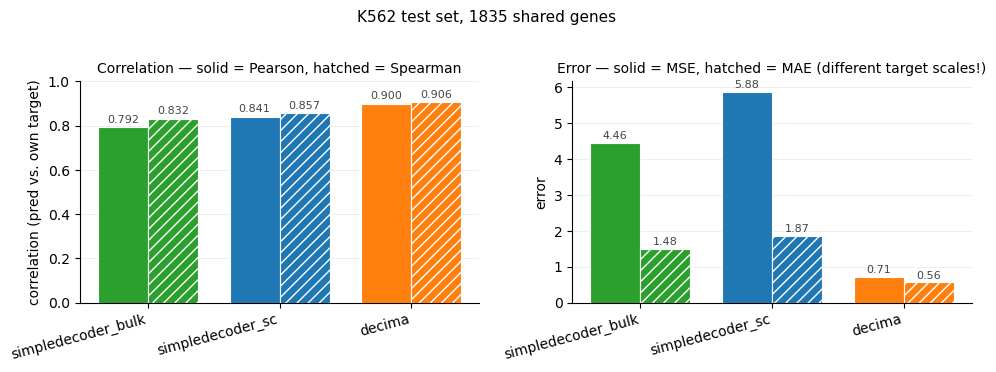

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
x = np.arange(len(NAMES))
w = 0.38

ax = axes[0]
for off, key, hatch in [(-w / 2, "pearson", None), (w / 2, "spearman", "///")]:
    vals = [stats[n][key] for n in NAMES]
    ax.bar(x + off, vals, w, color=[COLORS[n] for n in NAMES],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.012, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color="#444")
ax.set_ylim(0, 1.0)
ax.set_ylabel("correlation (pred vs. own target)")
ax.set_title("Correlation — solid = Pearson, hatched = Spearman", fontsize=10)

ax = axes[1]
for off, key, hatch in [(-w / 2, "mse", None), (w / 2, "mae", "///")]:
    vals = [stats[n][key] for n in NAMES]
    ax.bar(x + off, vals, w, color=[COLORS[n] for n in NAMES],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.06, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color="#444")
ax.set_ylabel("error")
ax.set_title("Error — solid = MSE, hatched = MAE (different target scales!)", fontsize=10)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES, rotation=15, ha="right")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle(f"K562 test set, {len(common)} shared genes", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

## 2. Distribution of predicted and observed values

This is where the runs differ most: `simpledecoder_*` predictions top out near 3.1 while their
targets go to ~11–12, so those models are compressing the dynamic range badly. `decima`
predictions span roughly the same range as its targets, but pile up against a ceiling at ~5.

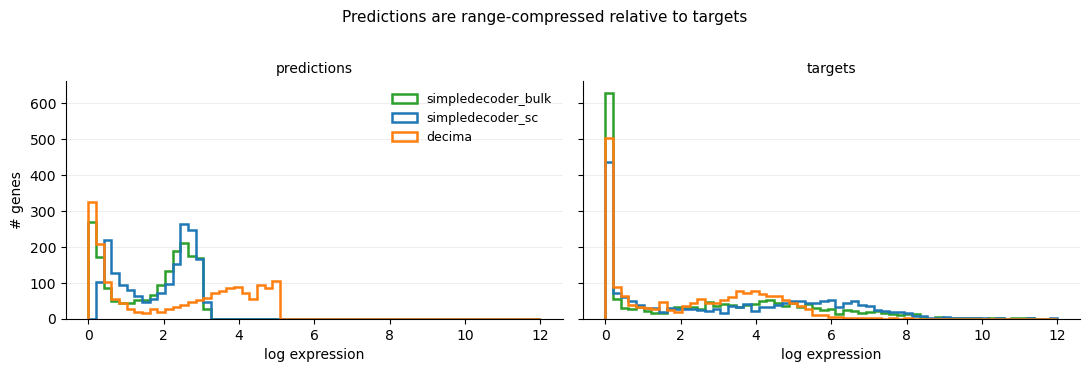

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
bins = np.linspace(0, 12, 60)

for ax, key, label in [(axes[0], "p", "predictions"), (axes[1], "t", "targets")]:
    for name in NAMES:
        ax.hist(runs[name][key], bins=bins, histtype="step", linewidth=1.8,
                color=COLORS[name], label=name)
    ax.set_xlabel("log expression")
    ax.set_title(label, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("# genes")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Predictions are range-compressed relative to targets", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

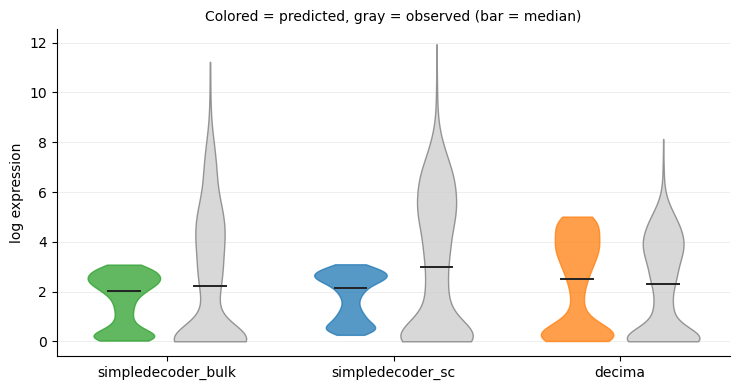

In [5]:
# Same information as paired violins: for each run, predicted vs. observed spread.
fig, ax = plt.subplots(figsize=(7.5, 4))

positions, data, face, edge = [], [], [], []
for i, name in enumerate(NAMES):
    positions += [i - 0.19, i + 0.19]
    data += [runs[name]["p"], runs[name]["t"]]
    face += [COLORS[name], "#cccccc"]
    edge += [COLORS[name], "#777777"]

parts = ax.violinplot(data, positions=positions, widths=0.32, showextrema=False)
for body, fc, ec in zip(parts["bodies"], face, edge):
    body.set_facecolor(fc)
    body.set_edgecolor(ec)
    body.set_alpha(0.75)
    body.set_linewidth(1.0)

for pos, arr in zip(positions, data):
    ax.plot([pos - 0.07, pos + 0.07], [np.median(arr)] * 2, color="#222", linewidth=1.4)

ax.set_xticks(np.arange(len(NAMES)))
ax.set_xticklabels(NAMES)
ax.set_ylabel("log expression")
ax.set_title("Colored = predicted, gray = observed (bar = median)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 3. Predicted vs. observed, per run

Density-colored scatter; dashed line is `y = x`.

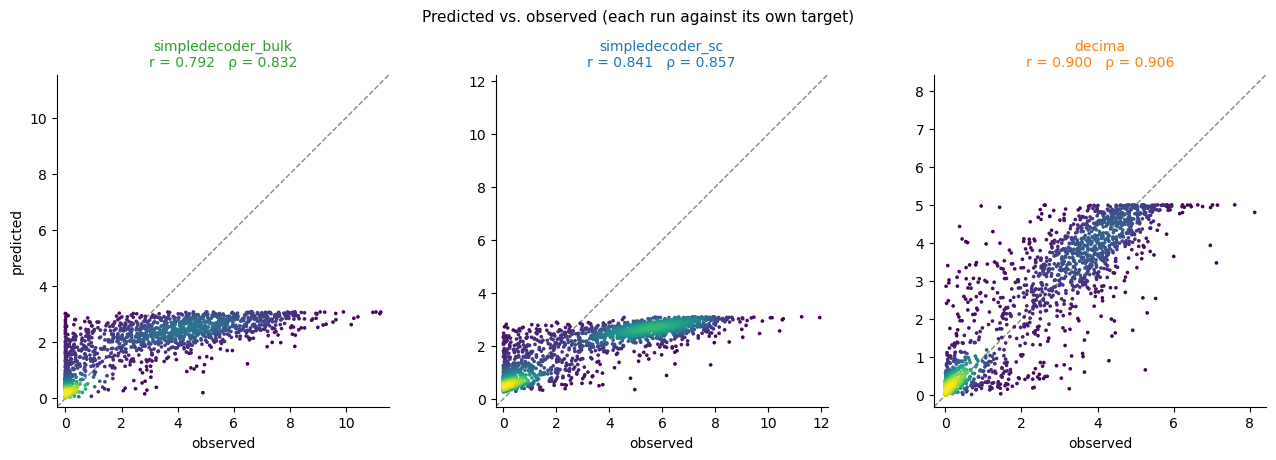

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))

for ax, name in zip(axes, NAMES):
    t, p = runs[name]["t"], runs[name]["p"]
    dens = gaussian_kde(np.vstack([t, p]))(np.vstack([t, p]))
    order = dens.argsort()  # draw dense points last so they are not buried
    ax.scatter(t[order], p[order], c=dens[order], s=7, cmap="viridis", linewidths=0)

    lim = (min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    s = stats[name]
    ax.set_title(f"{name}\nr = {s['pearson']:.3f}   ρ = {s['spearman']:.3f}", fontsize=10,
                 color=COLORS[name])
    ax.set_xlabel("observed")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("predicted")
fig.suptitle("Predicted vs. observed (each run against its own target)", fontsize=11, y=1.0)
fig.tight_layout()
plt.show()

## 4. Model vs. model

This compares the *predictions* directly and so is unaffected by the differing targets.
The two `simpledecoder` runs agree most with each other, as expected.

`decima` was trained on natural-log expression while the two `simpledecoder` runs used log2,
so decima is rescaled by `1 / ln(2)` here to put all three on a common log2 axis. The rescale
is local to this cell — `runs[...]` is not modified, and every other section still shows each
run in its own native units. Being linear, it leaves r and ρ unchanged; it only makes the
`y = x` line and the axis ranges comparable.

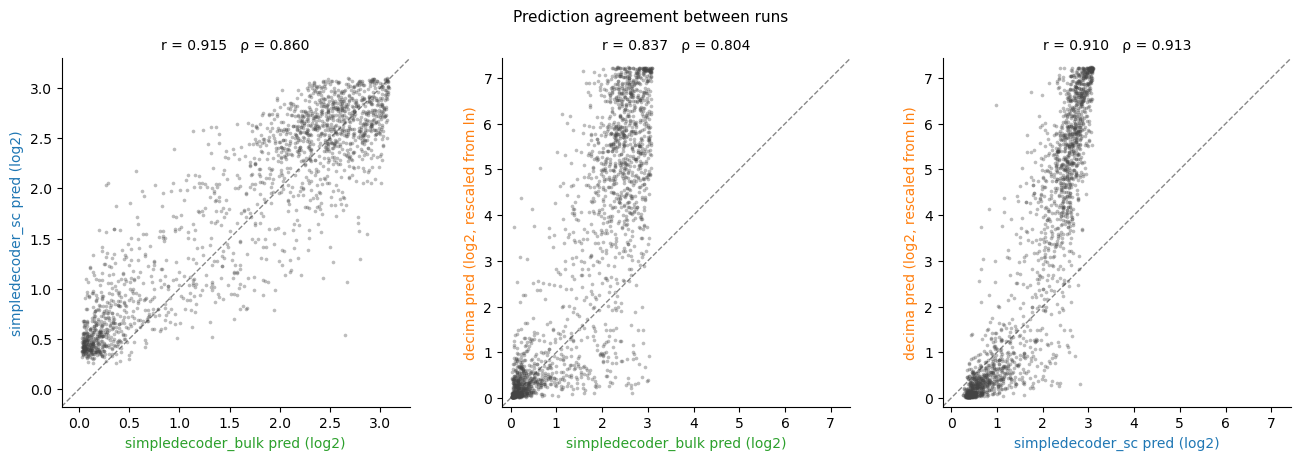

In [7]:
# decima was trained on natural-log expression, the two simpledecoder runs on log2. Rescale
# decima onto a log2 axis for this cell only -- runs[...] itself is left untouched. The
# rescale is linear, so r and rho are unaffected; it only makes y = x meaningful here.
LOG2_E = 1.0 / np.log(2.0)
IS_NATURAL_LOG = {"simpledecoder_bulk": False, "simpledecoder_sc": False, "decima": True}
AXIS_NOTE = {n: " pred (log2, rescaled from ln)" if IS_NATURAL_LOG[n] else " pred (log2)"
             for n in NAMES}


def pred_log2(name):
    p = runs[name]["p"]
    return p * LOG2_E if IS_NATURAL_LOG[name] else p


pairs = [(NAMES[0], NAMES[1]), (NAMES[0], NAMES[2]), (NAMES[1], NAMES[2])]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))

for ax, (a, b) in zip(axes, pairs):
    pa, pb = pred_log2(a), pred_log2(b)
    ax.scatter(pa, pb, s=7, alpha=0.35, color="#444", linewidths=0)

    lim = (min(pa.min(), pb.min()) - 0.2, max(pa.max(), pb.max()) + 0.2)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    r = np.corrcoef(pa, pb)[0, 1]
    rho = spearmanr(pa, pb).statistic
    ax.set_title(f"r = {r:.3f}   ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel(f"{a}{AXIS_NOTE[a]}", color=COLORS[a])
    ax.set_ylabel(f"{b}{AXIS_NOTE[b]}", color=COLORS[b])
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Prediction agreement between runs", fontsize=11, y=1.0)
fig.tight_layout()
plt.show()

## 5. Per-chromosome correlation

Checks whether any single test chromosome drives the overall numbers.

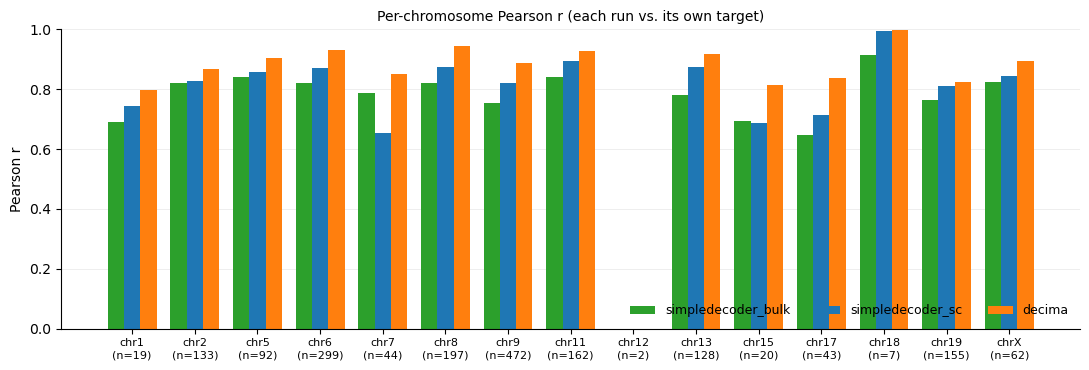

In [8]:
chroms = sorted(set(runs[NAMES[0]]["chrom"].tolist()),
                key=lambda c: (c == "chrX", int(c[3:]) if c[3:].isdigit() else 99))
counts = [int((runs[NAMES[0]]["chrom"] == c).sum()) for c in chroms]

fig, ax = plt.subplots(figsize=(11, 3.8))
w = 0.26
for i, name in enumerate(NAMES):
    r = runs[name]
    vals = []
    for c in chroms:
        m = r["chrom"] == c
        vals.append(float(np.corrcoef(r["p"][m], r["t"][m])[0, 1]) if m.sum() > 2 else np.nan)
    ax.bar(np.arange(len(chroms)) + (i - 1) * w, vals, w, color=COLORS[name], label=name)

ax.set_xticks(np.arange(len(chroms)))
ax.set_xticklabels([f"{c}\n(n={m})" for c, m in zip(chroms, counts)], fontsize=8)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, fontsize=9, ncol=3, loc="lower right")
ax.set_title("Per-chromosome Pearson r (each run vs. its own target)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 6. Where the error lives

Signed residual (`pred - target`) against observed expression. A downward trend means the
model over-predicts silent genes and under-predicts highly expressed ones — i.e. regression
toward the mean, which is what the compressed prediction range in §2 implies.

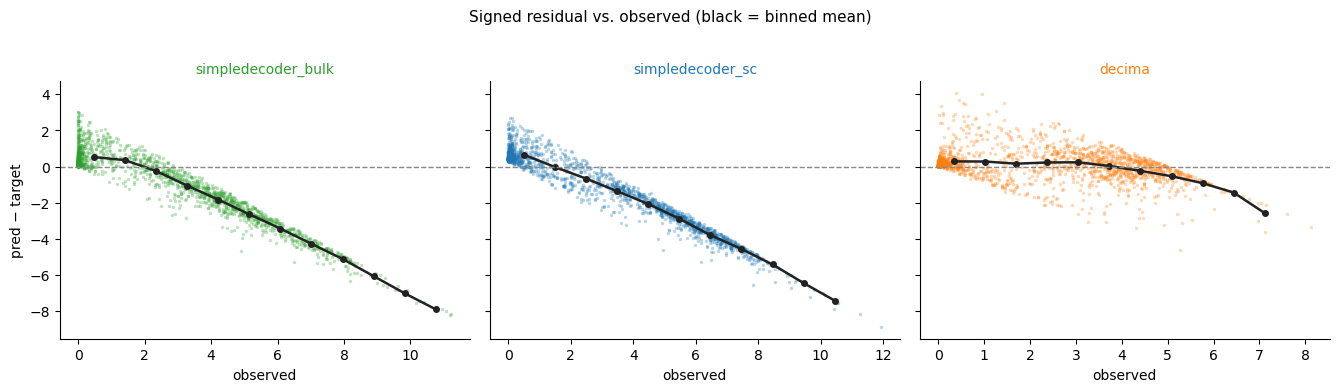

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)

for ax, name in zip(axes, NAMES):
    t, p = runs[name]["t"], runs[name]["p"]
    resid = p - t
    ax.scatter(t, resid, s=6, alpha=0.3, color=COLORS[name], linewidths=0)

    # binned mean residual, to make the trend readable through the point cloud
    edges = np.linspace(t.min(), t.max(), 13)
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = [resid[(t >= lo) & (t < hi)].mean() if ((t >= lo) & (t < hi)).sum() > 3 else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centers, means, color="#222", linewidth=1.8, marker="o", markersize=4)

    ax.axhline(0, color="#888", linestyle="--", linewidth=1.0)
    ax.set_xlabel("observed")
    ax.set_title(name, fontsize=10, color=COLORS[name])
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("pred − target")
fig.suptitle("Signed residual vs. observed (black = binned mean)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

## 7. Rank profile

Genes sorted by observed expression, with the prediction overlaid. Shows the ceiling effects
directly: the `simpledecoder` traces flatten out well below the top of the target curve.

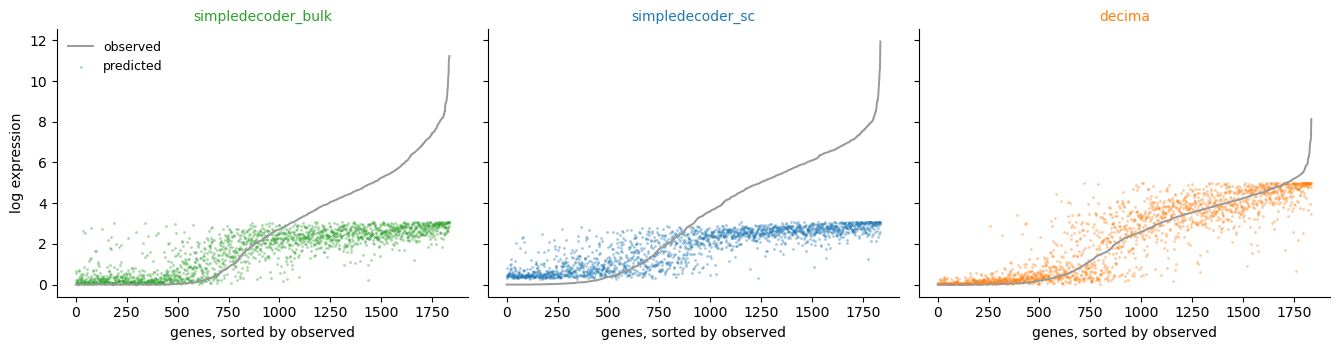

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=True)

for ax, name in zip(axes, NAMES):
    t, p = runs[name]["t"], runs[name]["p"]
    order = np.argsort(t)
    xs = np.arange(len(order))
    ax.plot(xs, t[order], color="#999", linewidth=1.4, label="observed")
    ax.scatter(xs, p[order], s=4, alpha=0.4, color=COLORS[name], linewidths=0, label="predicted")
    ax.set_xlabel("genes, sorted by observed")
    ax.set_title(name, fontsize=10, color=COLORS[name])
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("log expression")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

## 8. # Enhancer–gene linking (ENCODE CRISPR benchmark)

Replicates the analysis in `code_test/EP_linking7.ipynb` for the same three models. Each model
was run through `evals/e2g_tss.py`, which for every CRISPR element–gene pair predicts expression
twice: once from the unperturbed sequence (`outputs[:, 0]`) and once with the accessibility track
divided by `scale_factor` over the element (`outputs[:, 1]`). The score is the difference, which
is a log fold-change because the models predict in log space.

Two differences from `EP_linking7`, both forced by these particular files:

1. **`gs_df` is rebuilt per model.** `e2g_tss.py` derives the gene set from each checkpoint's own
   `tss_json_file`, so the row count differs: 10280 pairs for the two `simpledecoder` runs (whose
   bulk and sc jsons happen to share a gene set, making them row-identical) and 10306 for
   `decima`, a strict superset. The `_in_context.npy` files therefore are *not* interchangeable —
   each model gets its own. Rows are keyed on `pair_uid` so the models can still be compared.
2. **`DistanceToTSS` is left-merged, not inner-merged.** An inner merge against the rE2G
   predictions returns 10411 rows, which does not align with any model's `gs_df`; a left merge on
   `master` keeps `gs_df` order and length.

Out-of-context pairs are not exactly zero — they carry ~1e-7 of float noise, roughly six orders of
magnitude below real signal — so the in-context mask comes from `_in_context.npy`, never from
`score != 0`.

In [11]:
import json
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc

E2G_DIR = "/data1/lesliec/sarthak/data/joint_playground/e2g"
RNA_INFO_DIR = "/data1/lesliec/sarthak/data/DE_danwei"
TSS_BOUNDS_FILE = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
CRISPR_FILE = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
RE2G_FILE = (f"{E2G_DIR}/ENCODE-rE2G_extended_CrossValidated_K562_"
             "EPCrisprBenchmark_ensemble_data_GRCh38.predictions.tsv.gz")

# stem of the .npy pair in e2g/, and the rna_info json the checkpoint was trained against
E2G_MODELS = {
    "simpledecoder_bulk": ("k562_tss_simpledecoder",    "k562_bulk_rna_info.json"),
    "simpledecoder_sc":   ("k562_tss_simpledecoder_sc", "k562_sc_rna_info.json"),
    "decima":             ("k562_decima",               "k562_sc_rna_info_cellranger.json"),
}

# decima predicts in natural log, the simpledecoder runs in log2. Only matters for the effect-size
# regression, where the score is read as a fold-change; AUPRC is rank-based and so is unaffected.
LOG2_E = 1.0 / np.log(2.0)
IS_NATURAL_LOG = {"simpledecoder_bulk": False, "simpledecoder_sc": False, "decima": True}

tss_bounds = pd.read_csv(TSS_BOUNDS_FILE, sep="\t")
crispr = pd.read_csv(CRISPR_FILE, sep="\t")
crispr["master"] = (crispr["chrom"] + ":" + crispr["chromStart"].astype(str) + "-"
                    + crispr["chromEnd"].astype(str) + "_" + crispr["measuredGeneSymbol"])

re2g = pd.read_csv(RE2G_FILE, sep="\t")
re2g["master"] = (re2g["chr"] + ":" + re2g["start"].astype(str) + "-"
                  + re2g["end"].astype(str) + "_" + re2g["TargetGene"])
assert re2g["master"].is_unique, "rE2G master keys must be unique for a left merge to stay aligned"
dist_by_master = re2g.set_index("master")["DistanceToTSS"]

e2g = {}
for name, (stem, json_name) in E2G_MODELS.items():
    with open(f"{RNA_INFO_DIR}/{json_name}") as f:
        tss_dict = json.load(f)

    # same gene filter as evals/e2g_tss.py: keep only CRISPR pairs whose gene this model knows
    name_to_ensg = tss_bounds.set_index("name")["Ensembl_ID"].to_dict()
    name_to_ensg = {n: e for n, e in name_to_ensg.items() if e in tss_dict}
    gs = crispr.copy()
    gs["ensg_id"] = gs["measuredGeneSymbol"].map(name_to_ensg)
    gs = gs.dropna(subset=["ensg_id", "Regulated"]).reset_index(drop=True)

    outputs = np.load(f"{E2G_DIR}/{stem}.npy")
    in_context = np.load(f"{E2G_DIR}/{stem}_in_context.npy")
    assert len(outputs) == len(gs), f"{name}: {len(outputs)} outputs vs {len(gs)} CRISPR pairs"

    # left merge keeps gs order and length; the lone pair absent from rE2G becomes NaN and is
    # excluded from the distance-stratified panels only
    distance = gs["master"].map(dist_by_master).values.astype(float)

    e2g[name] = {
        "gs": gs,
        "outputs": outputs,
        "in_context": in_context,
        "score": outputs[:, 1] - outputs[:, 0],  # already log space, so a plain difference
        "y_true": gs["Regulated"].astype(int).values,
        "distance": distance,
        "pair_uid": gs["pair_uid"].values,
    }

    print(f"{name:20s} pairs={len(gs):6d}  in_context={int(in_context.sum()):5d}  "
          f"regulated={int(gs['Regulated'].sum()):4d}  "
          f"missing_distance={int(np.isnan(distance).sum())}")

simpledecoder_bulk   pairs= 10280  in_context= 3950  regulated= 463  missing_distance=0
simpledecoder_sc     pairs= 10280  in_context= 3950  regulated= 463  missing_distance=0
decima               pairs= 10306  in_context= 3914  regulated= 465  missing_distance=0


In [12]:
# Same figure as EP_linking7.plot_auprc_2x2, with the arrays passed in per model.
def plot_auprc_2x2(score_vector, in_context, y_true, distance_vector, title=None):
    """2x2 AUPRC summary: overall and distance-stratified, each for all pairs and in-context only."""
    y_score_all = np.abs(score_vector)
    dist_all = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx = y_true[in_context]
    dist_ctx = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",   lambda d: d <= 10_000),
        ("10–100 kb", lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",   lambda d: d > 100_000),
    ]
    bin_colors = ["#E24A33", "#348ABD", "#988ED5"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", y=1.01)

    def _plot_overall(ax, yt, ys, subtitle):
        prec, rec, _ = precision_recall_curve(yt, ys)
        aupr = auc(rec, prec)
        baseline = yt.mean()
        ax.plot(rec, prec, color="#E24A33", lw=2.5, label=f"Model (AUPRC = {aupr:.3f})")
        ax.fill_between(rec, prec, alpha=0.15, color="#E24A33")
        ax.axhline(baseline, color="#348ABD", lw=2, linestyle="--",
                   label=f"Random (AUPRC = {baseline:.3f})")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="black")

    def _plot_stratified(ax, yt_in, ys_in, distances, subtitle):
        # NaN distances (pairs absent from the rE2G table) fall out of every bin
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances) & ~np.isnan(distances)
            if mask.sum() == 0 or yt_in[mask].sum() == 0:
                continue
            yt, ys = yt_in[mask], ys_in[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr = auc(rec, prec)
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f"{label} (AUPRC={aupr:.3f}, N={mask.sum()})")
            ax.axhline(yt.mean(), color=color, lw=1.5, linestyle="--", alpha=0.7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9, edgecolor="black")

    _plot_overall(axes[0, 0], y_true, y_score_all, "Overall AUPRC")
    _plot_overall(axes[0, 1], y_true_ctx, y_score_ctx, "Overall AUPRC (in context)")
    _plot_stratified(axes[1, 0], y_true, y_score_all, dist_all, "Stratified AUPRC")
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx,
                     "Stratified AUPRC (in context)")

    plt.tight_layout()
    plt.show()

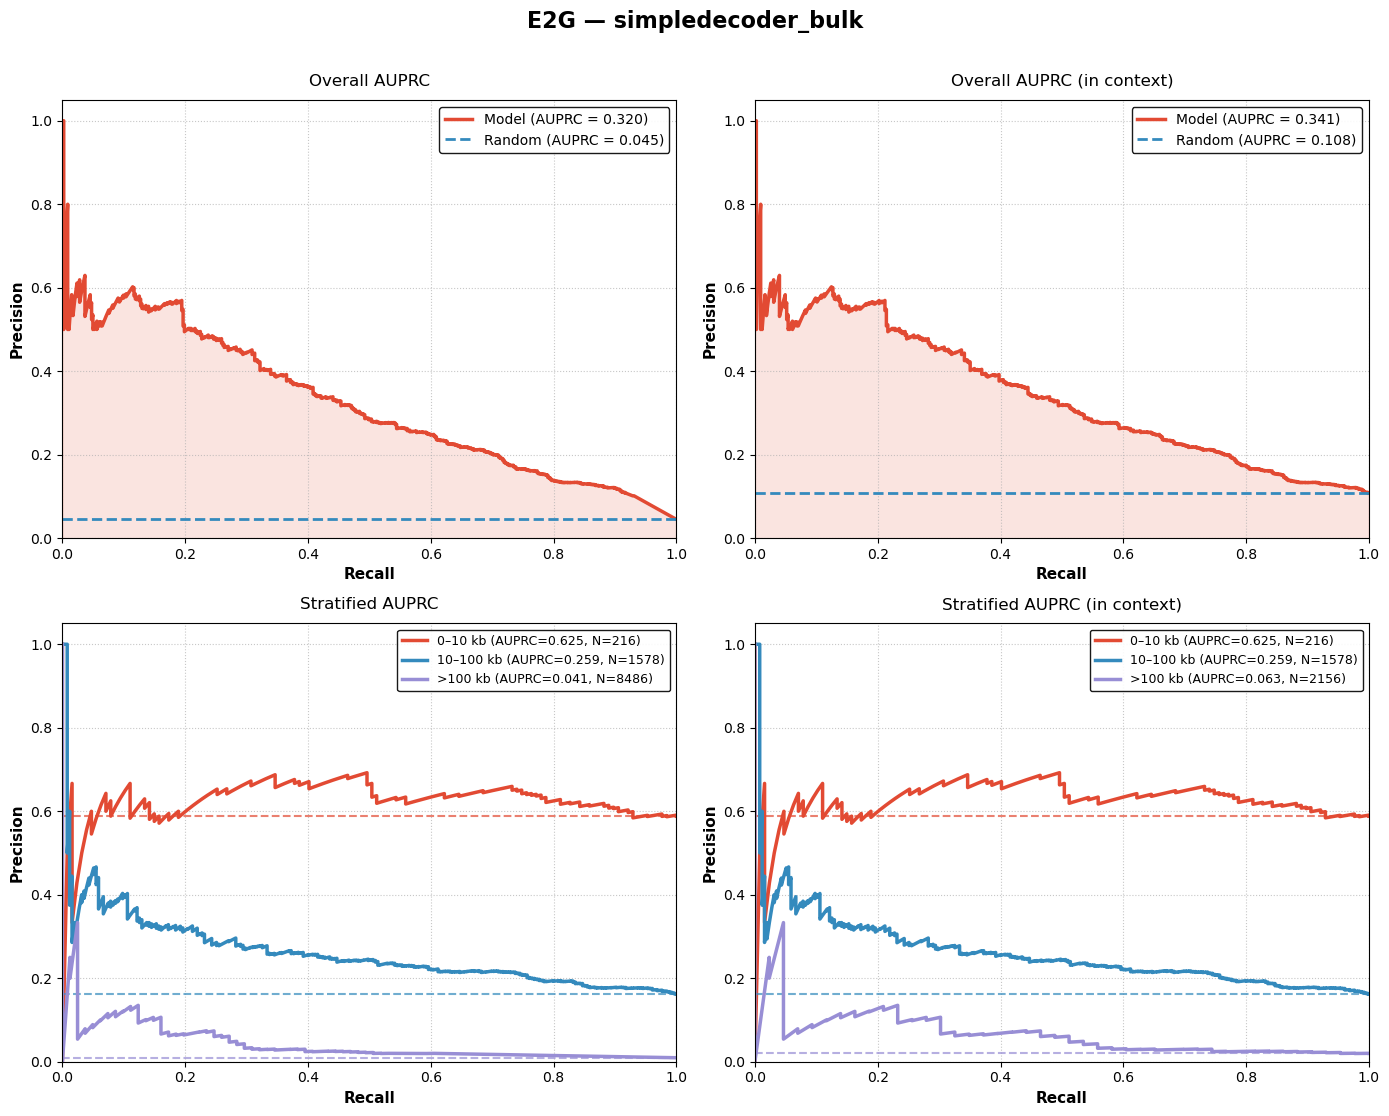

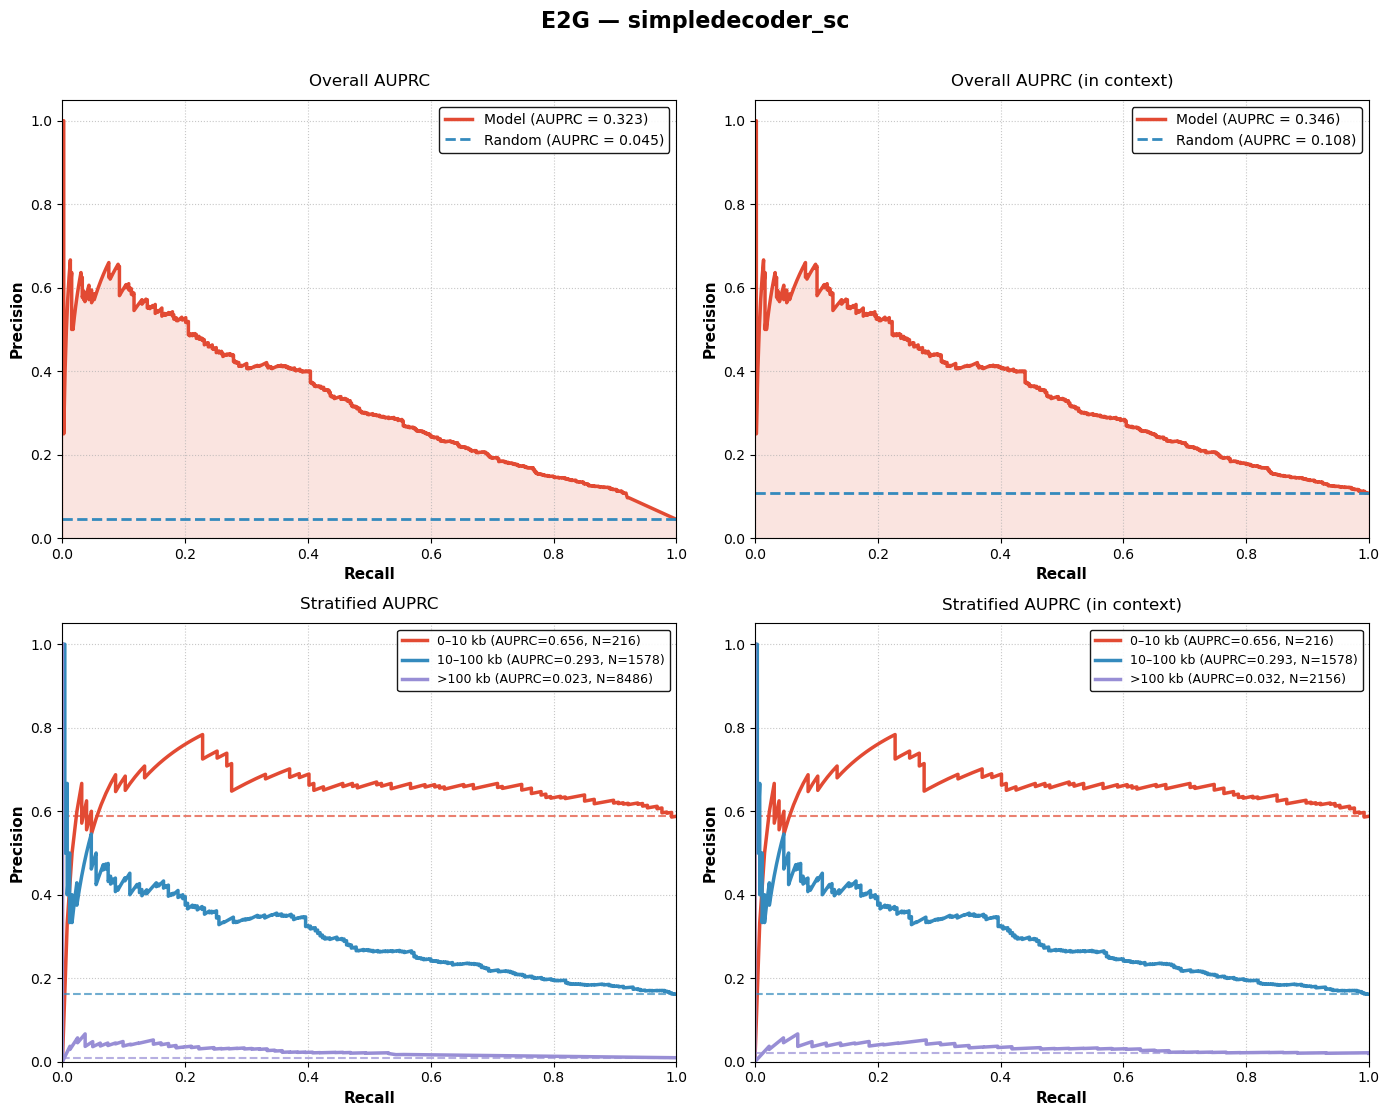

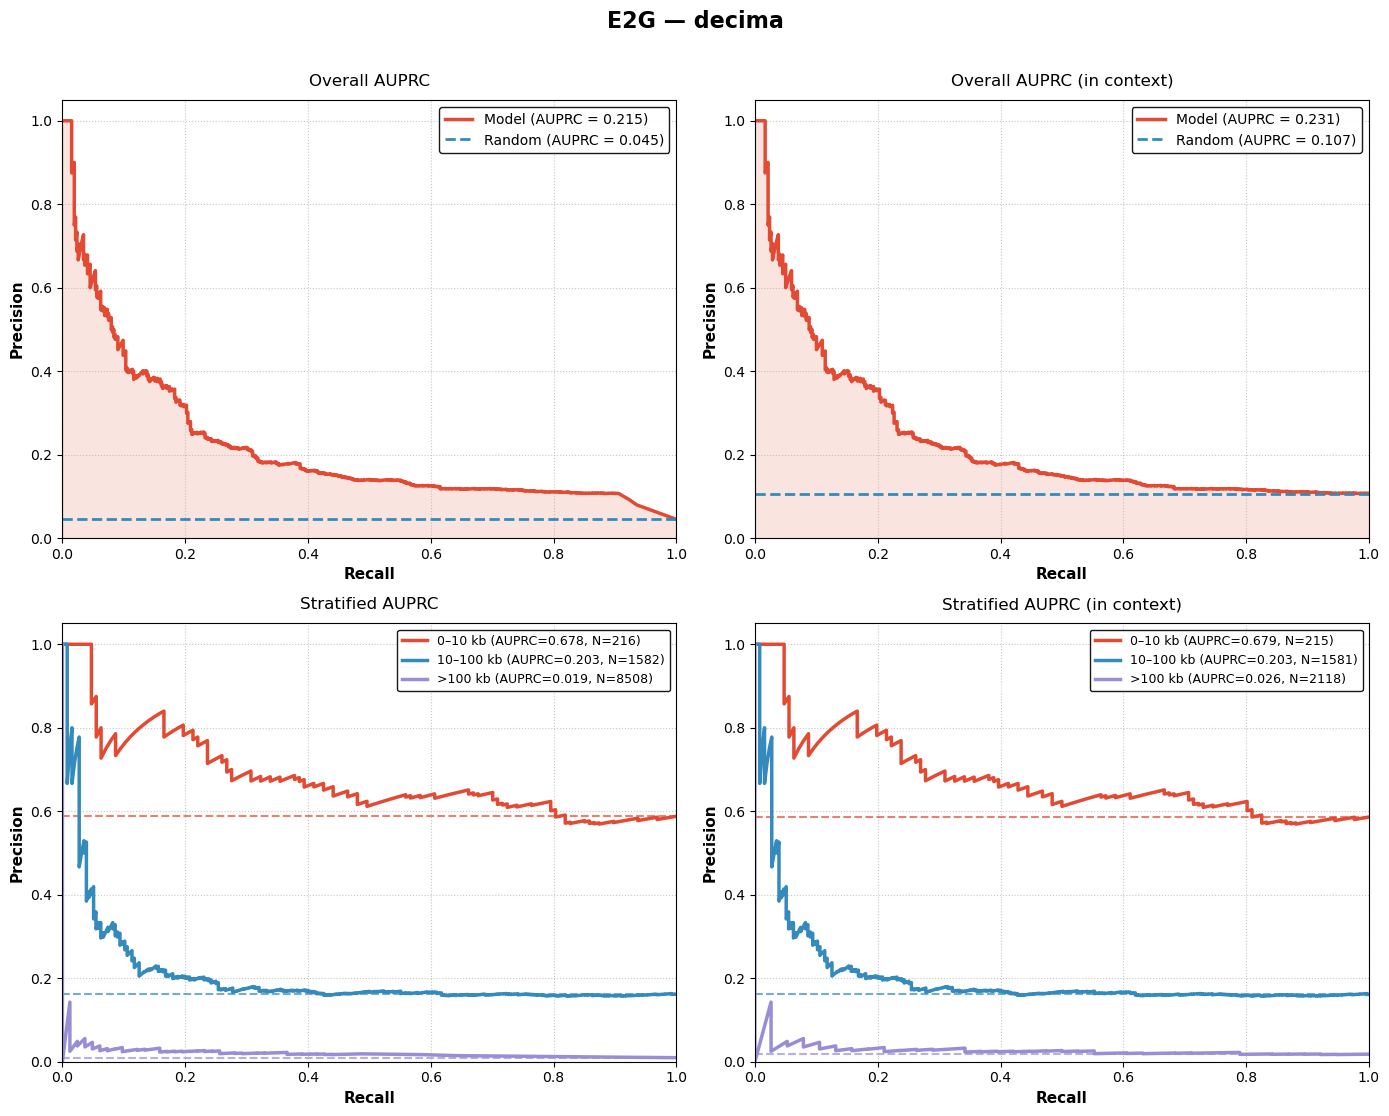

In [13]:
for name in NAMES:
    d = e2g[name]
    plot_auprc_2x2(d["score"], d["in_context"], d["y_true"], d["distance"],
                   title=f"E2G — {name}")

### Head-to-head on the shared pairs

The per-model figures above each use that model's own pair set, so the AUPRCs are not strictly
comparable. Restricting to the 10280 `pair_uid`s all three share — and, in the right-hand panel,
to pairs in context for *all three* models — makes them so.

10280 pairs shared across all three models
3371 of those are in context for all three models


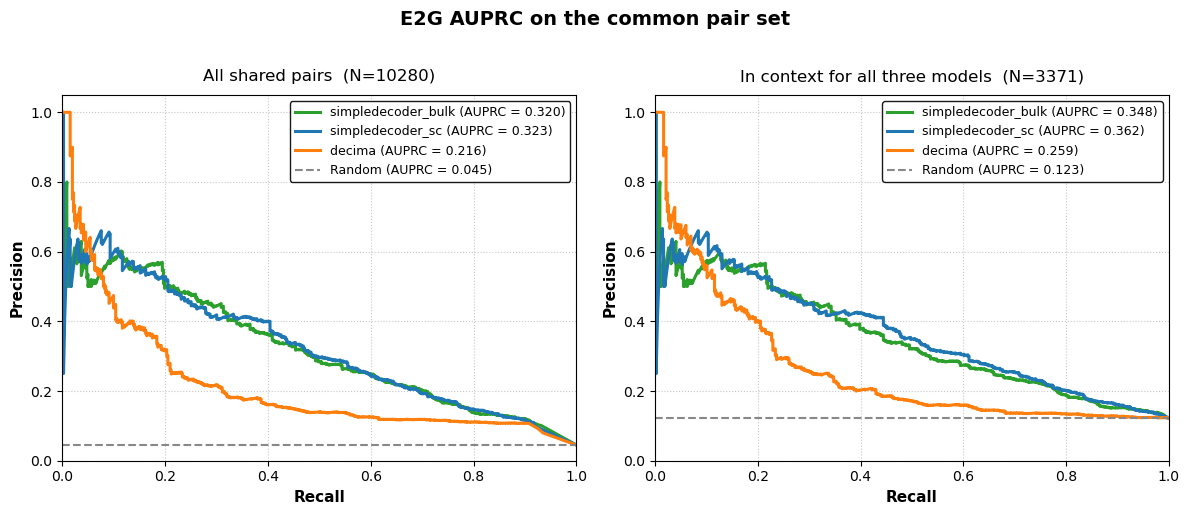

In [14]:
shared_uids = set.intersection(*[set(e2g[n]["pair_uid"]) for n in NAMES])
print(f"{len(shared_uids)} pairs shared across all three models")

# align every model onto one ordering of the shared pairs
shared_order = [u for u in e2g[NAMES[0]]["pair_uid"] if u in shared_uids]
aligned = {}
for name in NAMES:
    d = e2g[name]
    pos = {u: i for i, u in enumerate(d["pair_uid"])}
    idx = np.array([pos[u] for u in shared_order])
    aligned[name] = {"score": d["score"][idx], "in_context": d["in_context"][idx],
                     "y_true": d["y_true"][idx], "distance": d["distance"][idx]}

y_shared = aligned[NAMES[0]]["y_true"]
for name in NAMES[1:]:
    assert (aligned[name]["y_true"] == y_shared).all(), "labels must agree on shared pairs"

ctx_all = np.logical_and.reduce([aligned[n]["in_context"] for n in NAMES])
print(f"{int(ctx_all.sum())} of those are in context for all three models")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mask, subtitle in [(axes[0], np.ones(len(y_shared), bool), "All shared pairs"),
                           (axes[1], ctx_all, "In context for all three models")]:
    yt = y_shared[mask]
    for name in NAMES:
        prec, rec, _ = precision_recall_curve(yt, np.abs(aligned[name]["score"][mask]))
        ax.plot(rec, prec, color=COLORS[name], lw=2.2,
                label=f"{name} (AUPRC = {auc(rec, prec):.3f})")
    ax.axhline(yt.mean(), color="#888", lw=1.5, linestyle="--",
               label=f"Random (AUPRC = {yt.mean():.3f})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
    ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
    ax.set_title(f"{subtitle}  (N={int(mask.sum())})", fontsize=12, pad=10)
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9, edgecolor="black")

fig.suptitle("E2G AUPRC on the common pair set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Score direction

Lowering an enhancer's accessibility should *lower* predicted expression, so `-score` ought to be
the discriminative direction. It is not: for both `simpledecoder` runs `+score` outranks `-score`,
and `|score|` beats both. That means the models are responding to the perturbation without a
consistent sign, and the `|score|` used above is partly absorbing that inconsistency rather than
measuring a directional effect. Worth chasing down before these AUPRCs get quoted.

,model,subset,N,baseline,|score|,-score,+score
0,simpledecoder_bulk,all,10280,0.0450,0.3197,0.1458,0.2147
1,simpledecoder_bulk,in context,3950,0.1076,0.3413,0.1864,0.2502
2,simpledecoder_sc,all,10280,0.0450,0.3234,0.1263,0.2280
3,simpledecoder_sc,in context,3950,0.1076,0.3459,0.1701,0.2585
4,decima,all,10306,0.0451,0.2154,0.1503,0.1141
5,decima,in context,3914,0.1071,0.2309,0.2068,0.1418


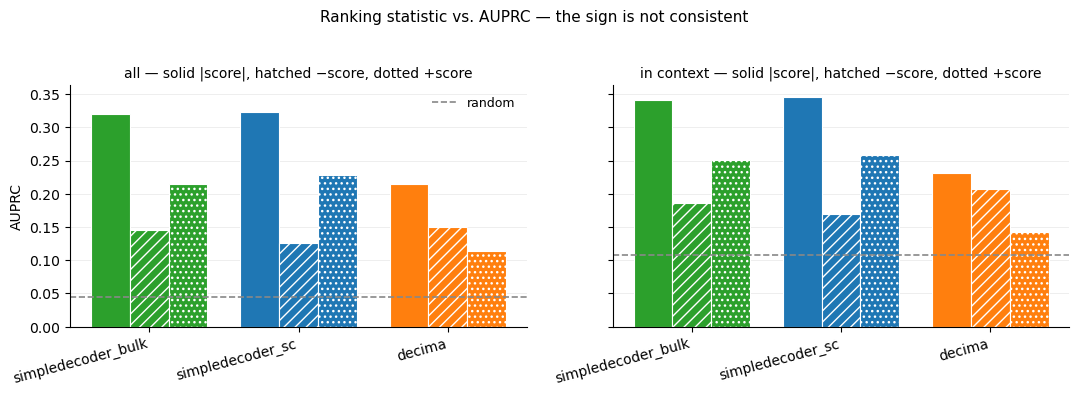

In [15]:
variants = {"|score|": np.abs, "-score": lambda s: -s, "+score": lambda s: s}

rows = []
for name in NAMES:
    d = e2g[name]
    for subset, mask in [("all", np.ones(len(d["y_true"]), bool)), ("in context", d["in_context"])]:
        yt = d["y_true"][mask]
        entry = {"model": name, "subset": subset, "N": int(mask.sum()), "baseline": yt.mean()}
        for vname, fn in variants.items():
            prec, rec, _ = precision_recall_curve(yt, fn(d["score"][mask]))
            entry[vname] = auc(rec, prec)
        rows.append(entry)
sign_df = pd.DataFrame(rows)
display(sign_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
x = np.arange(len(NAMES))
w = 0.26
for ax, subset in zip(axes, ["all", "in context"]):
    sub = sign_df[sign_df["subset"] == subset].set_index("model")
    for i, (vname, hatch) in enumerate(zip(variants, [None, "///", "..."])):
        ax.bar(x + (i - 1) * w, [sub.loc[n, vname] for n in NAMES], w,
               color=[COLORS[n] for n in NAMES], hatch=hatch, edgecolor="white", linewidth=0.8)
    ax.axhline(sub["baseline"].mean(), color="#888", linestyle="--", lw=1.2, label="random")
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES, rotation=15, ha="right")
    ax.set_title(f"{subset} — solid |score|, hatched −score, dotted +score", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Ranking statistic vs. AUPRC — the sign is not consistent", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

### Model score vs. CRISPRi effect size

As in `EP_linking7`, the plotted score is `-score` so that a positive value means "predicted to be
repressed by the knockdown". `decima` is rescaled from natural log to log2 here so the x-axes
carry the same units. Statistics are reported both for in-context pairs (the only ones where the
perturbation did anything) and for all pairs, which is what `EP_linking7` reported.

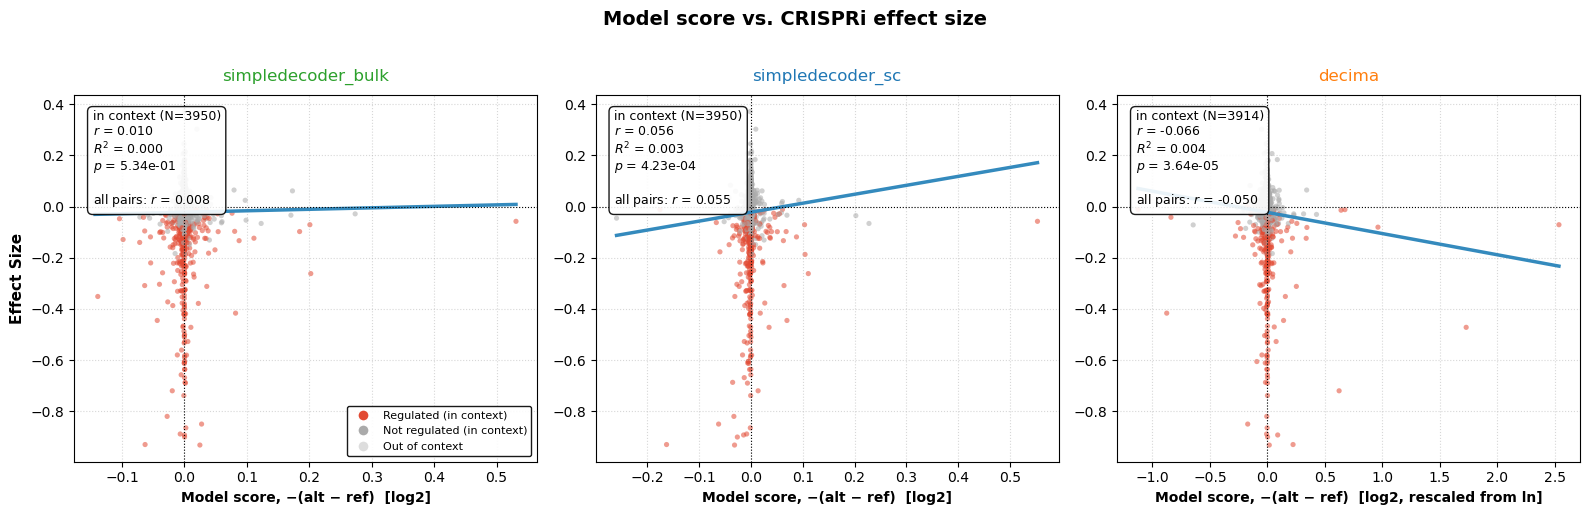

In [16]:
from scipy import stats
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, NAMES):
    d = e2g[name]
    scale = LOG2_E if IS_NATURAL_LOG[name] else 1.0
    model_score = -d["score"] * scale
    effect = d["gs"]["EffectSize"].values
    ctx = d["in_context"]

    ax.scatter(model_score[~ctx], effect[~ctx], c="#dddddd", alpha=0.4, s=10,
               linewidths=0, rasterized=True)
    colors = np.where(d["gs"]["Regulated"].values.astype(bool), "#E24A33", "#aaaaaa")
    ax.scatter(model_score[ctx], effect[ctx], c=colors[ctx], alpha=0.55, s=14,
               linewidths=0, rasterized=True)

    # fit on in-context pairs only; out-of-context scores are structurally ~0
    slope, intercept, r_ctx, p_ctx, _ = stats.linregress(model_score[ctx], effect[ctx])
    xs = np.linspace(model_score[ctx].min(), model_score[ctx].max(), 200)
    ax.plot(xs, intercept + slope * xs, color="#348ABD", lw=2.5)

    r_all = stats.pearsonr(model_score, effect)[0]
    p_str = f"{p_ctx:.2e}" if p_ctx > 1e-300 else "< 1e-300"
    textstr = (f"in context (N={int(ctx.sum())})\n$r$ = {r_ctx:.3f}\n$R^2$ = {r_ctx**2:.3f}\n"
               f"$p$ = {p_str}\n\nall pairs: $r$ = {r_all:.3f}")
    ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.9))

    ax.axhline(0, color="black", lw=0.8, linestyle=":")
    ax.axvline(0, color="black", lw=0.8, linestyle=":")
    unit = "log2, rescaled from ln" if IS_NATURAL_LOG[name] else "log2"
    ax.set_xlabel(f"Model score, −(alt − ref)  [{unit}]", fontsize=10, fontweight="bold")
    ax.set_title(name, fontsize=12, pad=10, color=COLORS[name])
    ax.grid(True, linestyle=":", alpha=0.5)

axes[0].set_ylabel("Effect Size", fontsize=11, fontweight="bold")
axes[0].legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E24A33", markersize=8,
           label="Regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#aaaaaa", markersize=8,
           label="Not regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#dddddd", markersize=8,
           label="Out of context"),
], loc="lower right", fontsize=8, framealpha=0.9, edgecolor="black")

fig.suptitle("Model score vs. CRISPRi effect size", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Redoing — the three new models (revised `TSSDecoder`)

Sections R1–R7 below repeat §1–§7 for the three runs finetuned on 2026-07-27, all at **epoch 16**.
These were trained under the revised `TSSDecoder`: a plain regression head with no `Softplus` and
no `log2`, because the target is already `log1p`-transformed. The prediction therefore sits
directly on the target's natural-log scale.

| name here | run | checkpoint | what makes it different |
|---|---|---|---|
| `decima 2` | `2026-07-27/21-54-24-337889` | `16-val_loss=0.65628` | gene-body mask as the 6th input channel; asymmetric window (TSS at index 163840); decoder mean-pools the **whole window** |
| `tss mask` | `2026-07-27/23-00-33-044232` | `16-val_loss=0.68752` | TSS-neighbourhood mask as the 6th input channel; TSS-centered window; decoder mean-pools the **whole window** |
| `tss region embedding` | `2026-07-27/22-39-32-007131` | `16-val_loss=0.84871` | no extra input channel; TSS-centered window; decoder mean-pools **only the TSS-region** embeddings |

**Two caveats from the top of the notebook no longer apply here:**

1. All three trained and were evaluated against the *same* targets
   (`k562_sc_rna_info_cellranger.json`, natural log) on the same 1844-gene test split, so MSE/MAE
   **are** directly comparable — this is a genuine head-to-head, unlike §1.
2. No `log2` ↔ `ln` rescaling is needed anywhere in this section; all three are in natural log.

**One new caveat:** the head is unconstrained, so predictions can be slightly negative
(the minimum is ≈ −0.42, for `tss region embedding`). That is expected under the revised decoder
and nothing here clips it.

**And one comparison caveat:** epoch 16 is matched *training length*, not matched convergence.
`tss region embedding` kept improving after epoch 16 (its best was 0.760 at epoch 34), so it is
being shown before its own optimum.

In [1]:
# --- Redoing: load the three 2026-07-27 runs -------------------------------------------------
# Self-contained on purpose: nothing in this section depends on a variable defined above, so the
# Redoing cells can be run on their own.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde

MODEL_OUT = "/data1/lesliec/sarthak/data/joint_playground/model_out"

FILES_NEW = {
    "decima 2":             f"{MODEL_OUT}/k562_decima_2.npz",
    "tss mask":             f"{MODEL_OUT}/k562_tssmask.npz",
    "tss region embedding": f"{MODEL_OUT}/k562_finetune_2.npz",
}

COLORS_NEW = {
    "decima 2":             "#ff7f0e",
    "tss mask":             "#d62728",
    "tss region embedding": "#9467bd",
}
NAMES_NEW = list(FILES_NEW)

runs_new = {}
for name, path in FILES_NEW.items():
    d = np.load(path, allow_pickle=True)
    runs_new[name] = {
        "genes": d["genes"],
        "preds": d["preds"].ravel(),
        "targets": d["targets"],
        "chroms": d["chroms"],
        "strands": d["strands"],
        "ckpt": str(d["ckpt_path"]),
        "tss_json": str(d["tss_json_file"]),
    }
    print(f"{name:22s} n={len(d['genes']):5d}  "
          f"targets={str(d['tss_json_file']).split('/')[-1]}  "
          f"ckpt={'/'.join(str(d['ckpt_path']).split('/')[-3:])}")

decima 2               n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=21-54-24-337889/checkpoints/16-val_loss=0.65628.ckpt
tss mask               n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=23-00-33-044232/checkpoints/16-val_loss=0.68752.ckpt
tss region embedding   n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=22-39-32-007131/checkpoints/16-val_loss=0.84871.ckpt


In [2]:
# Align on the shared gene set. All three used the same tss_json_file and the same split, so
# this is expected to be all 1844 genes -- the intersection is kept anyway so the cell stays
# correct if a future run uses a different gene set.
common_new = sorted(set.intersection(*[set(r["genes"].tolist()) for r in runs_new.values()]))
print(f"{len(common_new)} genes shared across the three runs")

for name, r in runs_new.items():
    idx_by_gene = {g: i for i, g in enumerate(r["genes"].tolist())}
    order = [idx_by_gene[g] for g in common_new]
    r["p"] = r["preds"][order]
    r["t"] = r["targets"][order]
    r["chrom"] = r["chroms"][order]
    r["strand"] = r["strands"][order]

# One shared target json means the aligned target vectors must be identical -- that is exactly
# what licenses comparing MSE/MAE across models below, so assert it rather than assume it.
ref_t = runs_new[NAMES_NEW[0]]["t"]
for name in NAMES_NEW[1:]:
    assert np.allclose(runs_new[name]["t"], ref_t), f"{name}: targets differ from {NAMES_NEW[0]}"
print("targets identical across all three runs -> MSE/MAE are directly comparable")


def metrics_new(p, t):
    return {
        "pearson": float(np.corrcoef(p, t)[0, 1]),
        "spearman": float(spearmanr(p, t).statistic),
        "mse": float(((p - t) ** 2).mean()),
        "mae": float(np.abs(p - t).mean()),
    }


stats_new = {name: metrics_new(r["p"], r["t"]) for name, r in runs_new.items()}
print(f"\n{'run':24s}{'pearson':>10s}{'spearman':>10s}{'MSE':>10s}{'MAE':>10s}")
for name in NAMES_NEW:
    s = stats_new[name]
    print(f"{name:24s}{s['pearson']:10.4f}{s['spearman']:10.4f}{s['mse']:10.4f}{s['mae']:10.4f}")

# Per-strand split: rc_strand reverse-complements minus-strand genes, so a gap between the two
# columns would point at the flip (coordinate mapping / mask alignment) rather than the model.
print(f"\n{'run':24s}{'r (+)':>9s}{'r (-)':>9s}{'n +':>7s}{'n -':>7s}")
for name in NAMES_NEW:
    r = runs_new[name]
    rs = [float(np.corrcoef(r["p"][r["strand"] == s], r["t"][r["strand"] == s])[0, 1])
          for s in (1, -1)]
    print(f"{name:24s}{rs[0]:9.4f}{rs[1]:9.4f}"
          f"{int((r['strand'] == 1).sum()):7d}{int((r['strand'] == -1).sum()):7d}")

print(f"\n{'run':24s}{'pred min':>10s}{'pred max':>10s}{'pred std':>10s}{'target std':>12s}")
for name in NAMES_NEW:
    p = runs_new[name]["p"]
    print(f"{name:24s}{p.min():10.3f}{p.max():10.3f}{p.std():10.3f}{ref_t.std():12.3f}")

1844 genes shared across the three runs
targets identical across all three runs -> MSE/MAE are directly comparable

run                        pearson  spearman       MSE       MAE
decima 2                    0.9057    0.9073    0.6974    0.5683
tss mask                    0.9092    0.8978    0.6350    0.5598
tss region embedding        0.8912    0.8729    0.7567    0.6192

run                         r (+)    r (-)    n +    n -
decima 2                   0.9068   0.9047    916    928
tss mask                   0.9084   0.9101    916    928
tss region embedding       0.8876   0.8948    916    928

run                       pred min  pred max  pred std  target std
decima 2                    -0.051     6.065     1.863       1.908
tss mask                    -0.055     5.830     1.766       1.908
tss region embedding        -0.418     6.886     1.788       1.908


## R1. Metrics per run

Unlike §1, the error bars here are comparable across models: identical targets, identical genes,
identical epoch.

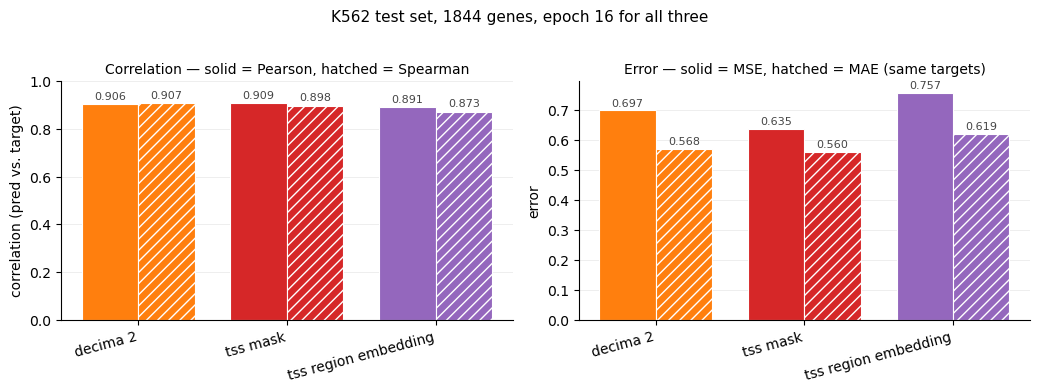

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
x = np.arange(len(NAMES_NEW))
w = 0.38

ax = axes[0]
for off, key, hatch in [(-w / 2, "pearson", None), (w / 2, "spearman", "///")]:
    vals = [stats_new[n][key] for n in NAMES_NEW]
    ax.bar(x + off, vals, w, color=[COLORS_NEW[n] for n in NAMES_NEW],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.012, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color="#444")
ax.set_ylim(0, 1.0)
ax.set_ylabel("correlation (pred vs. target)")
ax.set_title("Correlation — solid = Pearson, hatched = Spearman", fontsize=10)

ax = axes[1]
for off, key, hatch in [(-w / 2, "mse", None), (w / 2, "mae", "///")]:
    vals = [stats_new[n][key] for n in NAMES_NEW]
    ax.bar(x + off, vals, w, color=[COLORS_NEW[n] for n in NAMES_NEW],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.008, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color="#444")
ax.set_ylabel("error")
# same targets for all three, so no "different target scales!" warning is needed this time
ax.set_title("Error — solid = MSE, hatched = MAE (same targets)", fontsize=10)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES_NEW, rotation=15, ha="right")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle(f"K562 test set, {len(common_new)} genes, epoch 16 for all three", fontsize=11,
             y=1.02)
fig.tight_layout()
plt.show()

## R2. Distribution of predicted and observed values

The target is shared, so it is drawn once as a filled gray reference instead of three times. The
right panel is the residual distribution, which is the more informative view now that the targets
are common — a shift off zero is bias, a wide spread is variance.

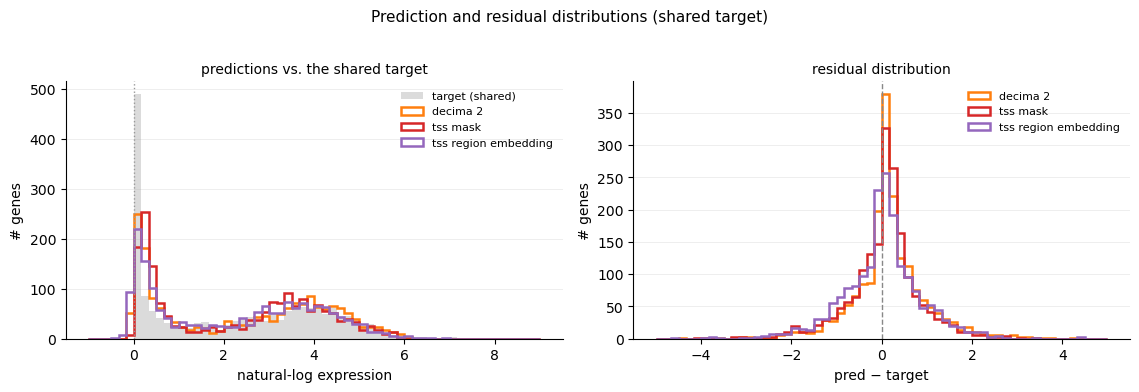

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
bins = np.linspace(-1, 9, 61)

ax = axes[0]
# target drawn once as a filled reference: it is identical for all three models
ax.hist(ref_t, bins=bins, color="#cccccc", alpha=0.7, label="target (shared)", zorder=0)
for name in NAMES_NEW:
    ax.hist(runs_new[name]["p"], bins=bins, histtype="step", linewidth=1.8,
            color=COLORS_NEW[name], label=name)
ax.axvline(0, color="#999", linestyle=":", linewidth=1.0)
ax.set_xlabel("natural-log expression")
ax.set_ylabel("# genes")
ax.set_title("predictions vs. the shared target", fontsize=10)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
for name in NAMES_NEW:
    ax.hist(runs_new[name]["p"] - ref_t, bins=np.linspace(-5, 5, 61), histtype="step",
            linewidth=1.8, color=COLORS_NEW[name], label=name)
ax.axvline(0, color="#888", linestyle="--", linewidth=1.0)
ax.set_xlabel("pred − target")
ax.set_ylabel("# genes")
ax.set_title("residual distribution", fontsize=10)
ax.legend(frameon=False, fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle("Prediction and residual distributions (shared target)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

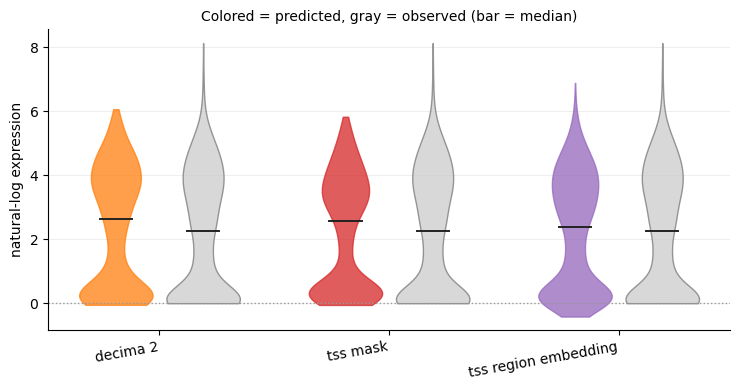

In [5]:
# Same information as paired violins: for each run, predicted vs. observed spread.
fig, ax = plt.subplots(figsize=(7.5, 4))

positions, data, face, edge = [], [], [], []
for i, name in enumerate(NAMES_NEW):
    positions += [i - 0.19, i + 0.19]
    data += [runs_new[name]["p"], runs_new[name]["t"]]
    face += [COLORS_NEW[name], "#cccccc"]
    edge += [COLORS_NEW[name], "#777777"]

parts = ax.violinplot(data, positions=positions, widths=0.32, showextrema=False)
for body, fc, ec in zip(parts["bodies"], face, edge):
    body.set_facecolor(fc)
    body.set_edgecolor(ec)
    body.set_alpha(0.75)
    body.set_linewidth(1.0)

for pos, arr in zip(positions, data):
    ax.plot([pos - 0.07, pos + 0.07], [np.median(arr)] * 2, color="#222", linewidth=1.4)

ax.axhline(0, color="#999", linestyle=":", linewidth=1.0)
ax.set_xticks(np.arange(len(NAMES_NEW)))
ax.set_xticklabels(NAMES_NEW, rotation=10, ha="right")
ax.set_ylabel("natural-log expression")
ax.set_title("Colored = predicted, gray = observed (bar = median)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## R3. Predicted vs. observed, per run

Density-colored scatter; dashed line is `y = x`. All three panels share one x axis (the common
target), so the panels are directly overlayable by eye.

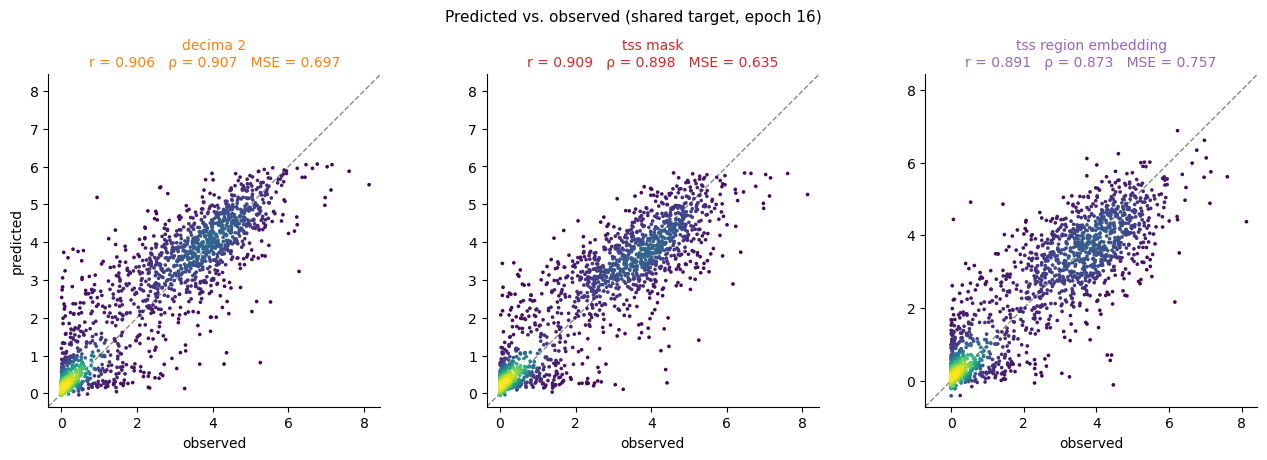

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))

for ax, name in zip(axes, NAMES_NEW):
    t, p = runs_new[name]["t"], runs_new[name]["p"]
    dens = gaussian_kde(np.vstack([t, p]))(np.vstack([t, p]))
    order = dens.argsort()  # draw dense points last so they are not buried
    ax.scatter(t[order], p[order], c=dens[order], s=7, cmap="viridis", linewidths=0)

    lim = (min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    s = stats_new[name]
    ax.set_title(f"{name}\nr = {s['pearson']:.3f}   ρ = {s['spearman']:.3f}   MSE = {s['mse']:.3f}",
                 fontsize=10, color=COLORS_NEW[name])
    ax.set_xlabel("observed")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("predicted")
fig.suptitle("Predicted vs. observed (shared target, epoch 16)", fontsize=11, y=1.0)
fig.tight_layout()
plt.show()

## R4. Model vs. model

Predictions compared directly. No rescaling this time — all three are in natural log, so `y = x`
is meaningful as-is.

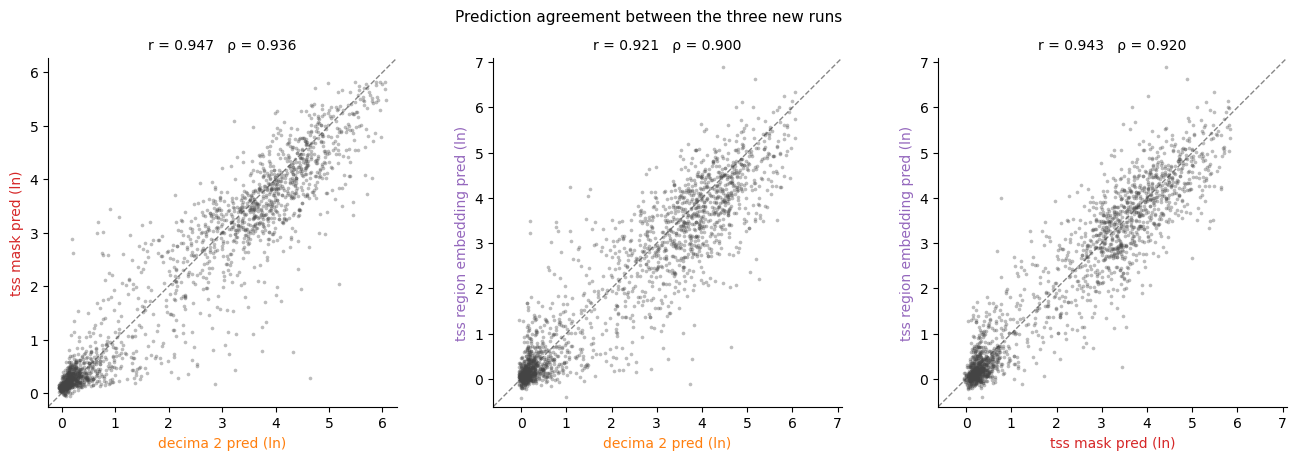

In [7]:
pairs_new = [(NAMES_NEW[0], NAMES_NEW[1]), (NAMES_NEW[0], NAMES_NEW[2]),
             (NAMES_NEW[1], NAMES_NEW[2])]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))

for ax, (a, b) in zip(axes, pairs_new):
    pa, pb = runs_new[a]["p"], runs_new[b]["p"]
    ax.scatter(pa, pb, s=7, alpha=0.35, color="#444", linewidths=0)

    lim = (min(pa.min(), pb.min()) - 0.2, max(pa.max(), pb.max()) + 0.2)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    r = np.corrcoef(pa, pb)[0, 1]
    rho = spearmanr(pa, pb).statistic
    ax.set_title(f"r = {r:.3f}   ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel(f"{a} pred (ln)", color=COLORS_NEW[a])
    ax.set_ylabel(f"{b} pred (ln)", color=COLORS_NEW[b])
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Prediction agreement between the three new runs", fontsize=11, y=1.0)
fig.tight_layout()
plt.show()

### R4b. Per-gene head-to-head

Only possible because the targets are shared: for each gene, which model is closest? A model can
win on aggregate MSE while losing on most individual genes (a few large misses dominate the mean),
so the win rate and the aggregate metric answer different questions.

share of genes where each model has the smallest |error| of the three:
  decima 2                  39.5%
  tss mask                  28.8%
  tss region embedding      31.7%

pairwise win rate (row model closer than column model, per gene):
                                  decima 2        tss mask  tss region emb
decima 2                                            55.0%           56.2% 
tss mask                            45.0%                           52.3% 
tss region embedding                43.8%           47.7%                 


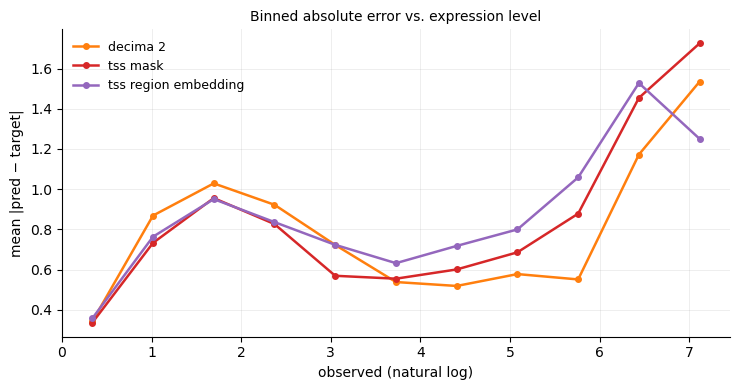

In [8]:
abs_err = {n: np.abs(runs_new[n]["p"] - ref_t) for n in NAMES_NEW}
best = np.vstack([abs_err[n] for n in NAMES_NEW]).argmin(axis=0)

print("share of genes where each model has the smallest |error| of the three:")
for i, n in enumerate(NAMES_NEW):
    print(f"  {n:24s}{(best == i).mean():7.1%}")

print("\npairwise win rate (row model closer than column model, per gene):")
print(f"{'':26s}" + "".join(f"{n[:14]:>16s}" for n in NAMES_NEW))
for a in NAMES_NEW:
    row = ["".ljust(16) if a == b else f"{(abs_err[a] < abs_err[b]).mean():15.1%} "
           for b in NAMES_NEW]
    print(f"{a:26s}" + "".join(row))

# Where in the expression range each model wins or loses -- the aggregate MSE hides this.
fig, ax = plt.subplots(figsize=(7.5, 4))
edges = np.linspace(ref_t.min(), ref_t.max(), 13)
centers = 0.5 * (edges[:-1] + edges[1:])
for n in NAMES_NEW:
    means = [abs_err[n][(ref_t >= lo) & (ref_t < hi)].mean()
             if ((ref_t >= lo) & (ref_t < hi)).sum() > 3 else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centers, means, color=COLORS_NEW[n], linewidth=1.8, marker="o", markersize=4, label=n)
ax.set_xlabel("observed (natural log)")
ax.set_ylabel("mean |pred − target|")
ax.set_title("Binned absolute error vs. expression level", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## R5. Per-chromosome correlation

Checks whether any single test chromosome drives the overall numbers.

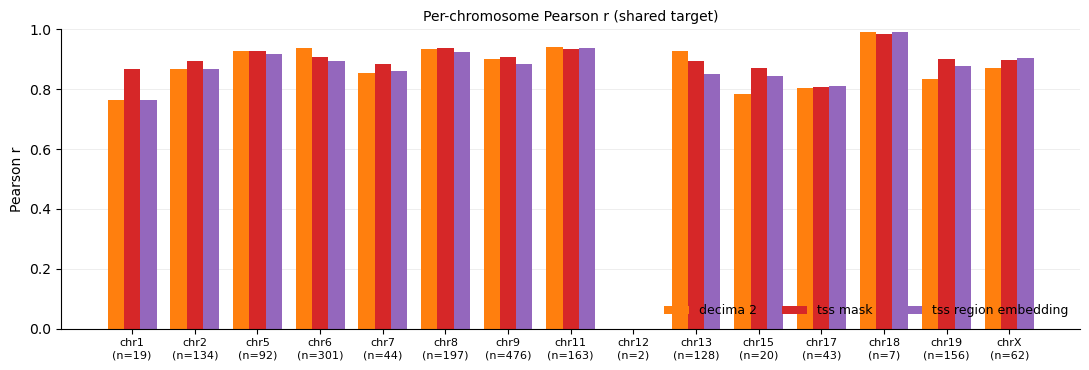

In [9]:
chroms_new = sorted(set(runs_new[NAMES_NEW[0]]["chrom"].tolist()),
                    key=lambda c: (c == "chrX", int(c[3:]) if c[3:].isdigit() else 99))
counts_new = [int((runs_new[NAMES_NEW[0]]["chrom"] == c).sum()) for c in chroms_new]

fig, ax = plt.subplots(figsize=(11, 3.8))
w = 0.26
for i, name in enumerate(NAMES_NEW):
    r = runs_new[name]
    vals = []
    for c in chroms_new:
        m = r["chrom"] == c
        vals.append(float(np.corrcoef(r["p"][m], r["t"][m])[0, 1]) if m.sum() > 2 else np.nan)
    ax.bar(np.arange(len(chroms_new)) + (i - 1) * w, vals, w, color=COLORS_NEW[name], label=name)

ax.set_xticks(np.arange(len(chroms_new)))
ax.set_xticklabels([f"{c}\n(n={m})" for c, m in zip(chroms_new, counts_new)], fontsize=8)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, fontsize=9, ncol=3, loc="lower right")
ax.set_title("Per-chromosome Pearson r (shared target)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## R6. Where the error lives

Signed residual (`pred − target`) against observed expression. A downward trend means the model
over-predicts silent genes and under-predicts highly expressed ones — regression toward the mean.

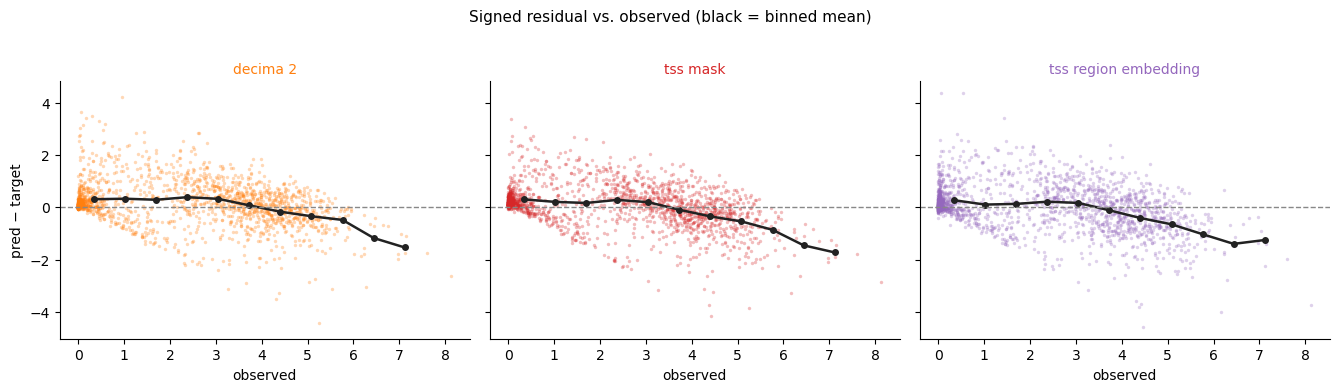

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)

for ax, name in zip(axes, NAMES_NEW):
    t, p = runs_new[name]["t"], runs_new[name]["p"]
    resid = p - t
    ax.scatter(t, resid, s=6, alpha=0.3, color=COLORS_NEW[name], linewidths=0)

    # binned mean residual, to make the trend readable through the point cloud
    edges = np.linspace(t.min(), t.max(), 13)
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = [resid[(t >= lo) & (t < hi)].mean() if ((t >= lo) & (t < hi)).sum() > 3 else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centers, means, color="#222", linewidth=1.8, marker="o", markersize=4)

    ax.axhline(0, color="#888", linestyle="--", linewidth=1.0)
    ax.set_xlabel("observed")
    ax.set_title(name, fontsize=10, color=COLORS_NEW[name])
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("pred − target")
fig.suptitle("Signed residual vs. observed (black = binned mean)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

## R7. Rank profile

Genes sorted by observed expression with the prediction overlaid. The ordering is identical across
the three panels now, so the traces can be compared position by position.

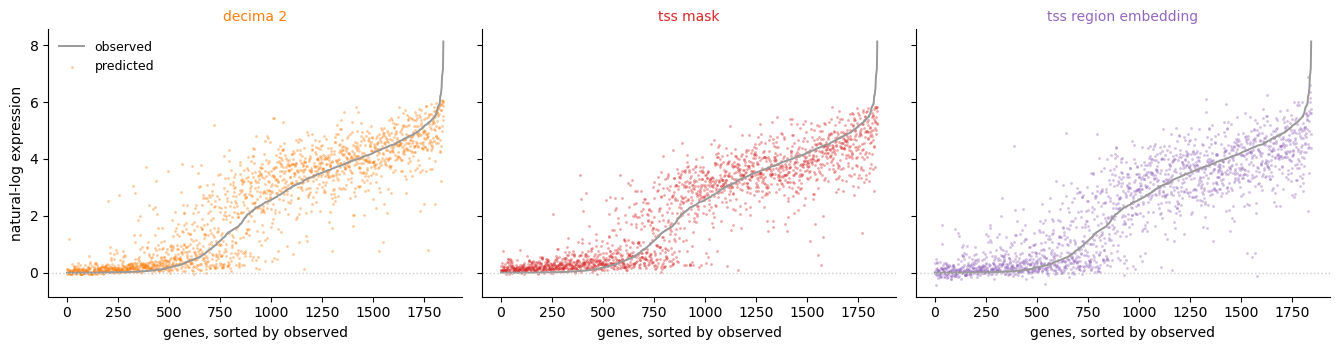

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=True)

for ax, name in zip(axes, NAMES_NEW):
    t, p = runs_new[name]["t"], runs_new[name]["p"]
    order = np.argsort(t)
    xs = np.arange(len(order))
    ax.plot(xs, t[order], color="#999", linewidth=1.4, label="observed")
    ax.scatter(xs, p[order], s=4, alpha=0.4, color=COLORS_NEW[name], linewidths=0,
               label="predicted")
    ax.axhline(0, color="#ccc", linestyle=":", linewidth=1.0)
    ax.set_xlabel("genes, sorted by observed")
    ax.set_title(name, fontsize=10, color=COLORS_NEW[name])
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("natural-log expression")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

### Takeaways — expression (R1–R7)

Numbers below are from the eval job logs (`evals/jobs/tss_eval_5782782_*.out`); the cells above
recompute them from the `.npz` files, so they should match exactly — all three runs cover the same
1844 test genes.

| model | Pearson r | Spearman ρ | MSE | pred range |
|---|---|---|---|---|
| `tss mask` | **0.9092** | 0.8978 | **0.6350** | −0.06 → 5.83 |
| `decima 2` | 0.9057 | **0.9073** | 0.6974 | −0.05 → 6.07 |
| `tss region embedding` | 0.8912 | 0.8729 | 0.7567 | −0.42 → 6.89 |

- The two **whole-window poolers** (`tss mask`, `decima 2`) beat the **TSS-region pooler** at
  matched epoch, on every metric. Giving the model the TSS location as an input channel and
  letting it pool globally works better than restricting the readout to the TSS neighbourhood.
- `tss mask` and `decima 2` are close, and they differ in two things at once (which mask, and
  centered vs. asymmetric window), so this does not isolate either factor.
- **The aggregate and per-gene verdicts disagree between those two.** `tss mask` wins aggregate
  MSE (0.635 vs. 0.697) and Pearson r, but `decima 2` is the closest of the three on 39.5% of
  genes, beats `tss mask` head-to-head on 55% of them, and has the better Spearman ρ (0.9073 vs.
  0.8978). So `tss mask`'s MSE edge comes from having fewer large misses, not from being better on
  the typical gene — R4b is the panel that shows this, and which model to prefer depends on which
  of the two you care about.
- Test ordering matches val-loss ordering at epoch 16 (0.657 / 0.688 / 0.849), so nothing looks
  like an evaluation artifact.
- Strand-split r is within ~0.01 for all three, i.e. the `rc_strand` flip and mask alignment are
  behaving on both strands.
- Predictions still under-disperse relative to the target (pred std ≈ 1.77–1.86 vs. target 1.91)
  and cannot reach the target maximum of 8.13 — the regression-toward-the-mean pattern from §6 is
  still present, though far weaker than the old `simpledecoder` ceiling at ~3.1.
- Caveat worth repeating: `tss region embedding` is being judged at epoch 16, before its own best
  epoch (34, val 0.760). A convergence-matched comparison would need those checkpoints.

## R8. Enhancer–gene linking (ENCODE CRISPR benchmark)

§8 repeated for the three 2026-07-27 models, from `evals/e2g_tss.py` run at `--scale_factor 100
--dist_additional_mask 100` (job array `5782783`, ~9h15m per model). For every CRISPR element–gene
pair the model predicts expression twice: unperturbed (`outputs[:, 0]`) and with the accessibility
track divided by 100 over the element ± 100 bp (`outputs[:, 1]`). The score is the difference,
which is a log fold-change because the models predict in log space.

**Three things are simpler here than in §8:**

1. **One `gs_df` for all three models.** All three trained against the same
   `k562_sc_rna_info_cellranger.json`, so the pair set, its order, and the labels are identical —
   10306 pairs. §8 had to rebuild `gs_df` per model and key on `pair_uid` to compare.
2. **No `log2` ↔ `ln` rescaling.** All three predict in natural log, so the effect-size panel needs
   no per-model scale factor.
3. **`DistanceToTSS`** is still left-merged from the rE2G table (an inner merge returns 10411 rows,
   which matches no model's `gs_df`).

**But `in_context` still differs per model, and the `.npy` files are not interchangeable:**
3914 pairs for `decima 2` against 3957 for the two centered models. `decima 2`'s window is
asymmetric — 163840 bp upstream of the TSS and 360448 downstream — so it covers slightly fewer
CRISPR elements than a symmetric ±262144 window, even though both are 524288 bp wide.

As in §8, out-of-context pairs are not exactly zero — they carry ~1e-6 of float noise, some six
orders of magnitude below real signal — so the in-context mask comes from `_in_context.npy`, never
from `score != 0`.

In [1]:
# --- Redoing: load the three E2G runs --------------------------------------------------------
# Self-contained, like the rest of the Redoing section.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

E2G_DIR = "/data1/lesliec/sarthak/data/joint_playground/e2g"
RNA_INFO_DIR = "/data1/lesliec/sarthak/data/DE_danwei"
TSS_BOUNDS_FILE = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
CRISPR_FILE = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
RE2G_FILE = (f"{E2G_DIR}/ENCODE-rE2G_extended_CrossValidated_K562_"
             "EPCrisprBenchmark_ensemble_data_GRCh38.predictions.tsv.gz")

E2G_MODELS_NEW = {
    "decima 2":             "k562_decima_2",
    "tss mask":             "k562_tssmask",
    "tss region embedding": "k562_finetune_2",
}
# all three checkpoints were finetuned against this one gene json -> one shared pair set
SHARED_JSON = "k562_sc_rna_info_cellranger.json"

# repeated here rather than reused from the R1 cell so this section runs standalone
COLORS_NEW = {
    "decima 2":             "#ff7f0e",
    "tss mask":             "#d62728",
    "tss region embedding": "#9467bd",
}
NAMES_NEW = list(E2G_MODELS_NEW)

tss_bounds = pd.read_csv(TSS_BOUNDS_FILE, sep="\t")
crispr = pd.read_csv(CRISPR_FILE, sep="\t")
crispr["master"] = (crispr["chrom"] + ":" + crispr["chromStart"].astype(str) + "-"
                    + crispr["chromEnd"].astype(str) + "_" + crispr["measuredGeneSymbol"])

re2g = pd.read_csv(RE2G_FILE, sep="\t")
re2g["master"] = (re2g["chr"] + ":" + re2g["start"].astype(str) + "-"
                  + re2g["end"].astype(str) + "_" + re2g["TargetGene"])
assert re2g["master"].is_unique, "rE2G master keys must be unique for a left merge to stay aligned"
dist_by_master = re2g.set_index("master")["DistanceToTSS"]

# ONE gs_df, built with the same gene filter as evals/e2g_tss.py. Unlike section 8 this is shared:
# the three models know the same genes, so the pair set and its order are identical.
with open(f"{RNA_INFO_DIR}/{SHARED_JSON}") as f:
    tss_dict = json.load(f)
name_to_ensg = tss_bounds.set_index("name")["Ensembl_ID"].to_dict()
name_to_ensg = {n: e for n, e in name_to_ensg.items() if e in tss_dict}
gs_new = crispr.copy()
gs_new["ensg_id"] = gs_new["measuredGeneSymbol"].map(name_to_ensg)
gs_new = gs_new.dropna(subset=["ensg_id", "Regulated"]).reset_index(drop=True)

y_true_new = gs_new["Regulated"].astype(int).values
# left merge keeps gs_new order and length; pairs absent from rE2G become NaN and drop out of the
# distance-stratified panels only
distance_new = gs_new["master"].map(dist_by_master).values.astype(float)
effect_new = gs_new["EffectSize"].values

e2g_new = {}
for name, stem in E2G_MODELS_NEW.items():
    outputs = np.load(f"{E2G_DIR}/{stem}.npy")
    in_context = np.load(f"{E2G_DIR}/{stem}_in_context.npy")
    assert len(outputs) == len(gs_new), f"{name}: {len(outputs)} outputs vs {len(gs_new)} pairs"
    e2g_new[name] = {
        "outputs": outputs,
        "in_context": in_context,
        "score": outputs[:, 1] - outputs[:, 0],  # natural log space, so a plain difference
    }
    s, ic = e2g_new[name]["score"], in_context
    print(f"{name:22s} pairs={len(outputs):6d}  in_context={int(ic.sum()):5d}  "
          f"score(in ctx): mean={s[ic].mean():+.4f} std={s[ic].std():.4f}  "
          f"|score| out of ctx <= {np.abs(s[~ic]).max():.1e}")

print(f"\nshared pair set: {len(gs_new)} pairs, {int(y_true_new.sum())} regulated, "
      f"{int(np.isnan(distance_new).sum())} missing a rE2G distance")

decima 2               pairs= 10306  in_context= 3914  score(in ctx): mean=+0.0184 std=0.0574  |score| out of ctx <= 1.9e-06
tss mask               pairs= 10306  in_context= 3957  score(in ctx): mean=+0.0060 std=0.0321  |score| out of ctx <= 9.5e-07
tss region embedding   pairs= 10306  in_context= 3957  score(in ctx): mean=+0.0012 std=0.0517  |score| out of ctx <= 2.4e-06

shared pair set: 10306 pairs, 465 regulated, 0 missing a rE2G distance


In [2]:
# Same figure as section 8 / EP_linking7.plot_auprc_2x2. Redefined rather than reused so the
# Redoing section does not depend on the cells above.
def plot_auprc_2x2_new(score_vector, in_context, y_true, distance_vector, title=None):
    """2x2 AUPRC summary: overall and distance-stratified, each for all pairs and in-context only."""
    y_score_all = np.abs(score_vector)
    dist_all = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx = y_true[in_context]
    dist_ctx = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",   lambda d: d <= 10_000),
        ("10–100 kb", lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",   lambda d: d > 100_000),
    ]
    bin_colors = ["#E24A33", "#348ABD", "#988ED5"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", y=1.01)

    def _plot_overall(ax, yt, ys, subtitle):
        prec, rec, _ = precision_recall_curve(yt, ys)
        aupr = auc(rec, prec)
        baseline = yt.mean()
        ax.plot(rec, prec, color="#E24A33", lw=2.5, label=f"Model (AUPRC = {aupr:.3f})")
        ax.fill_between(rec, prec, alpha=0.15, color="#E24A33")
        ax.axhline(baseline, color="#348ABD", lw=2, linestyle="--",
                   label=f"Random (AUPRC = {baseline:.3f})")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="black")

    def _plot_stratified(ax, yt_in, ys_in, distances, subtitle):
        # NaN distances (pairs absent from the rE2G table) fall out of every bin
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances) & ~np.isnan(distances)
            if mask.sum() == 0 or yt_in[mask].sum() == 0:
                continue
            yt, ys = yt_in[mask], ys_in[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr = auc(rec, prec)
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f"{label} (AUPRC={aupr:.3f}, N={mask.sum()})")
            ax.axhline(yt.mean(), color=color, lw=1.5, linestyle="--", alpha=0.7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9, edgecolor="black")

    _plot_overall(axes[0, 0], y_true, y_score_all, "Overall AUPRC")
    _plot_overall(axes[0, 1], y_true_ctx, y_score_ctx, "Overall AUPRC (in context)")
    _plot_stratified(axes[1, 0], y_true, y_score_all, dist_all, "Stratified AUPRC")
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx,
                     "Stratified AUPRC (in context)")

    plt.tight_layout()
    plt.show()

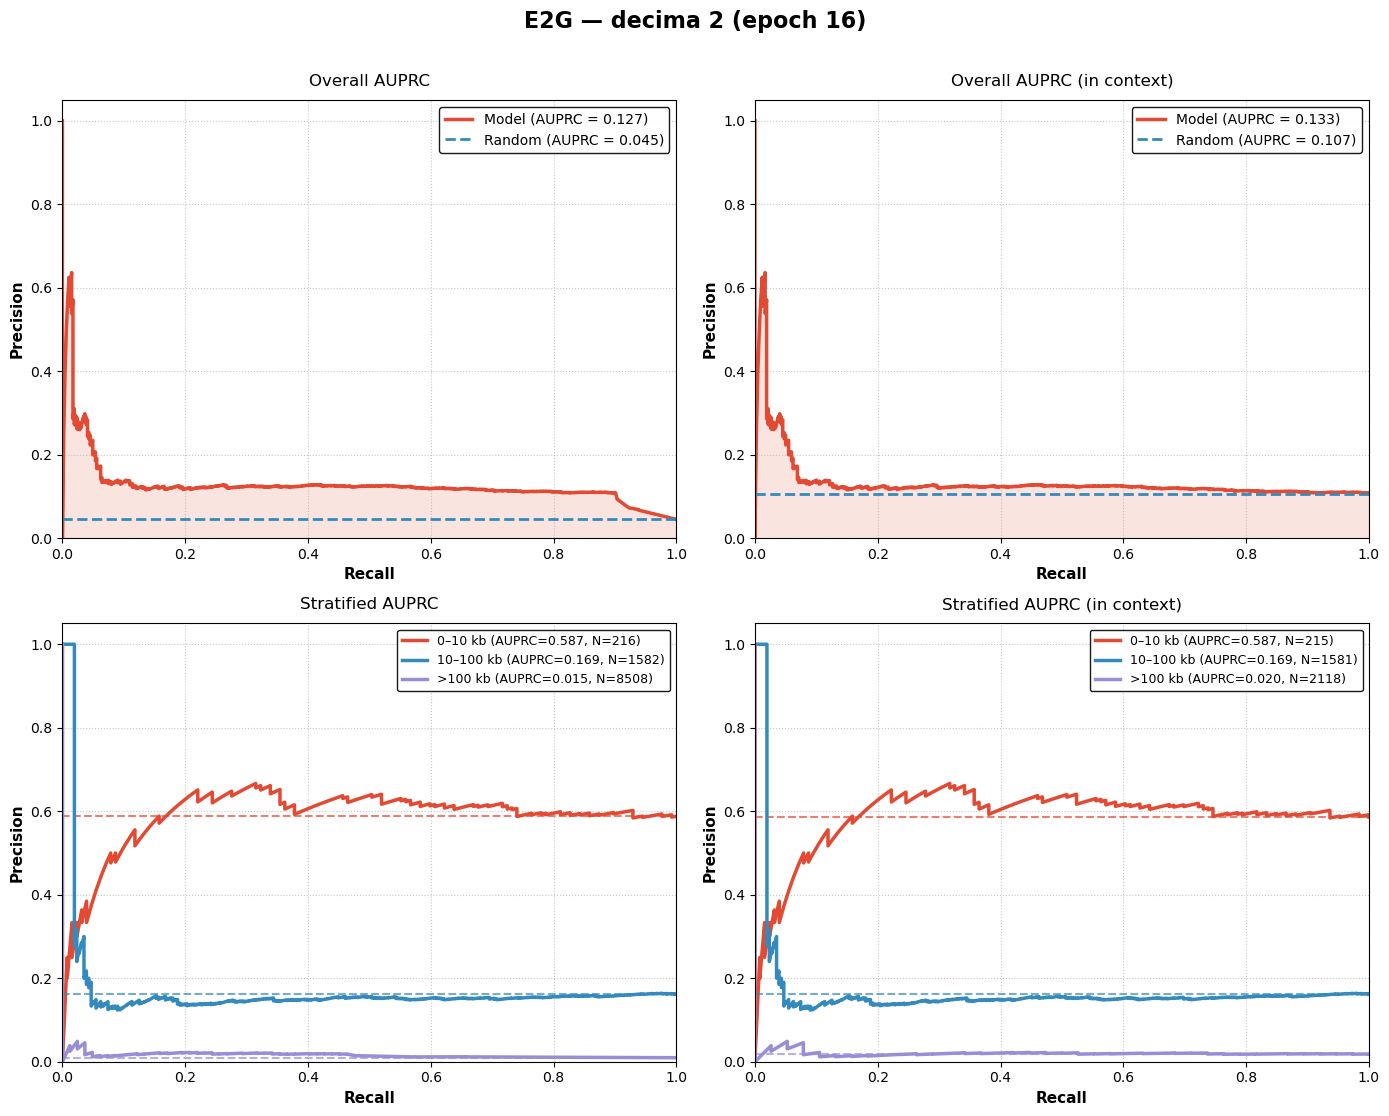

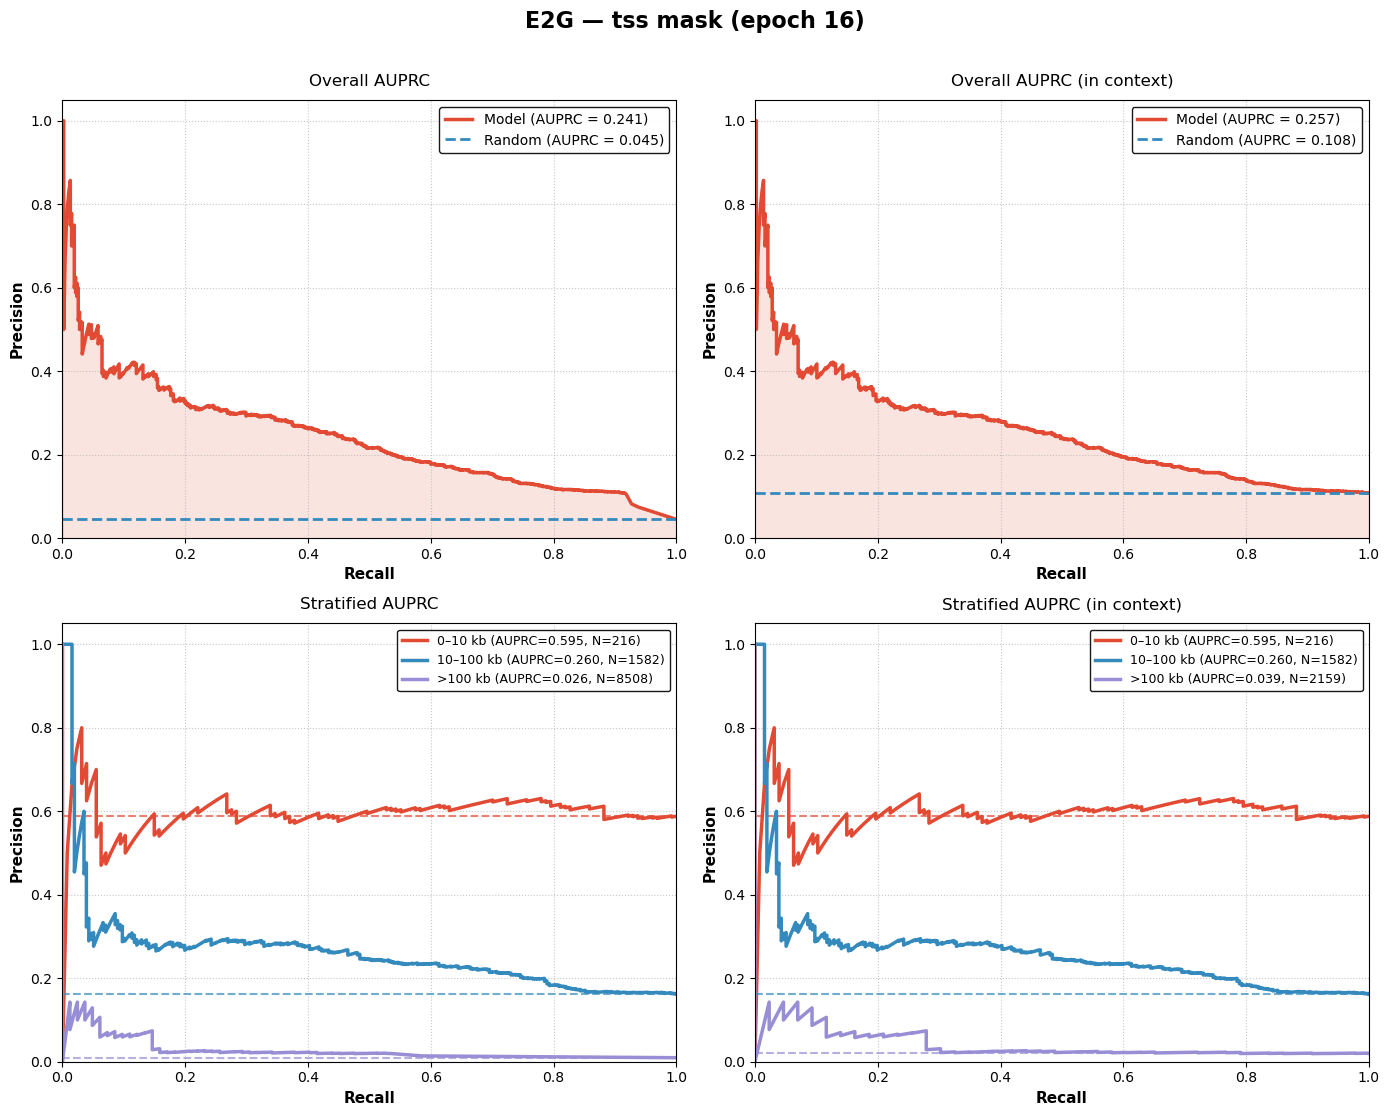

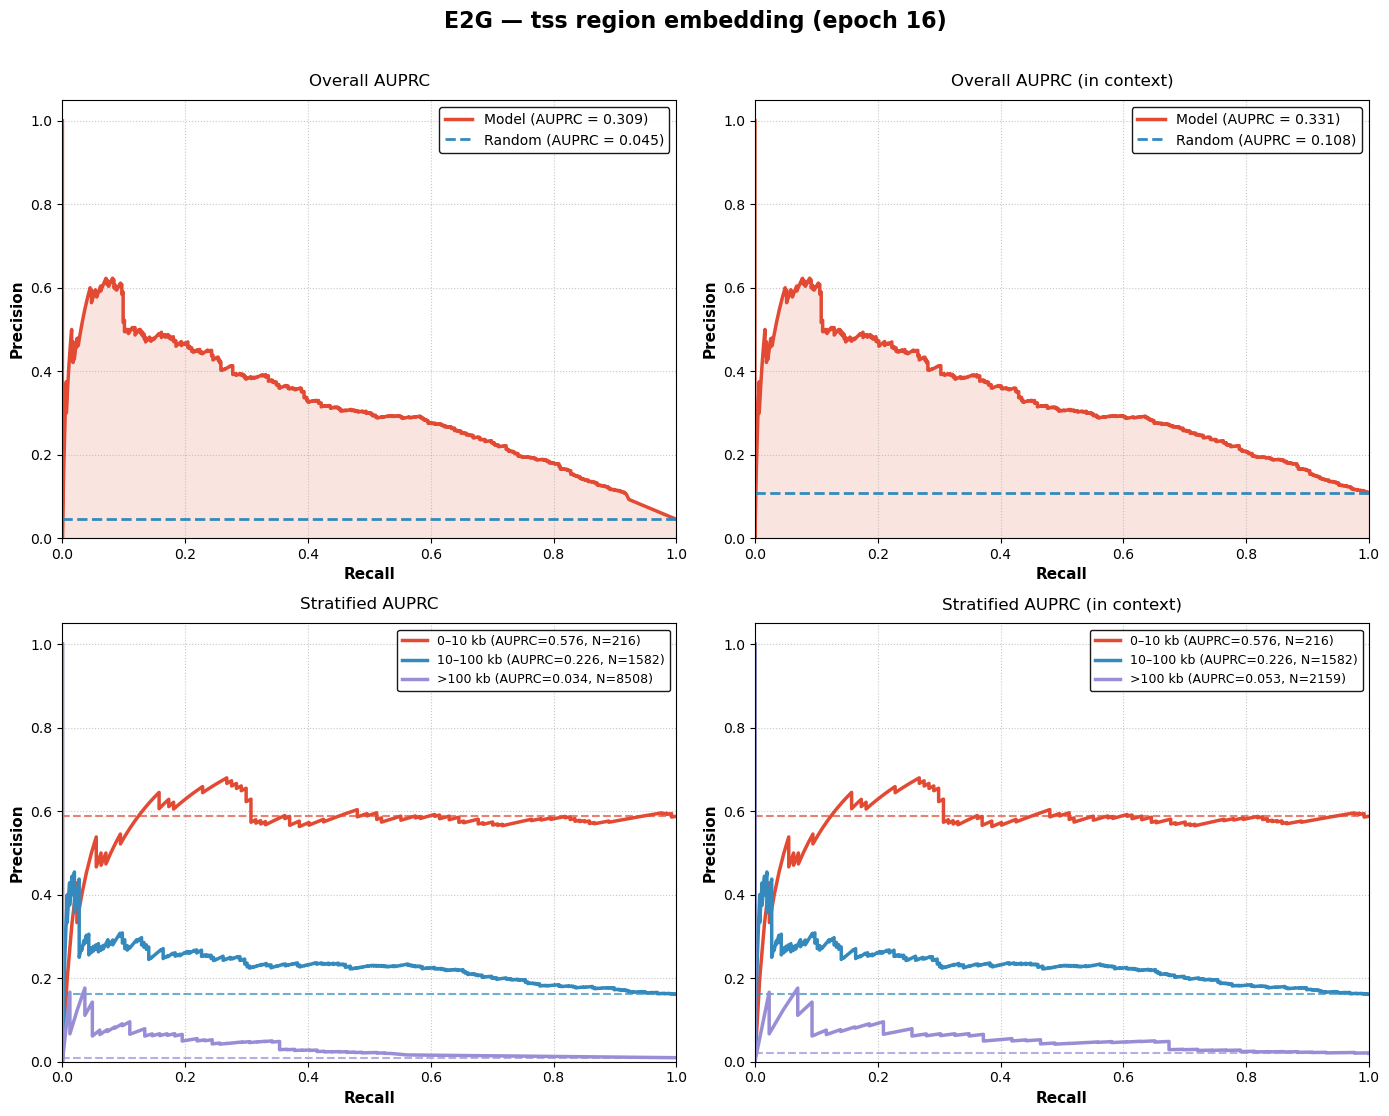

In [3]:
for name in NAMES_NEW:
    d = e2g_new[name]
    plot_auprc_2x2_new(d["score"], d["in_context"], y_true_new, distance_new,
                       title=f"E2G — {name} (epoch 16)")

### R8b. Head-to-head

No `pair_uid` alignment needed this time: the three models share one pair set in one order (the
cell above asserts the row counts). The left panel is all 10306 pairs; the right restricts to the
pairs in context for *all three* models, which is the only subset where every model actually saw
the perturbation.

10306 pairs, identical for all three models (one shared gene json)
in context per model: decima 2=3914, tss mask=3957, tss region embedding=3957
in context for all three: 3377


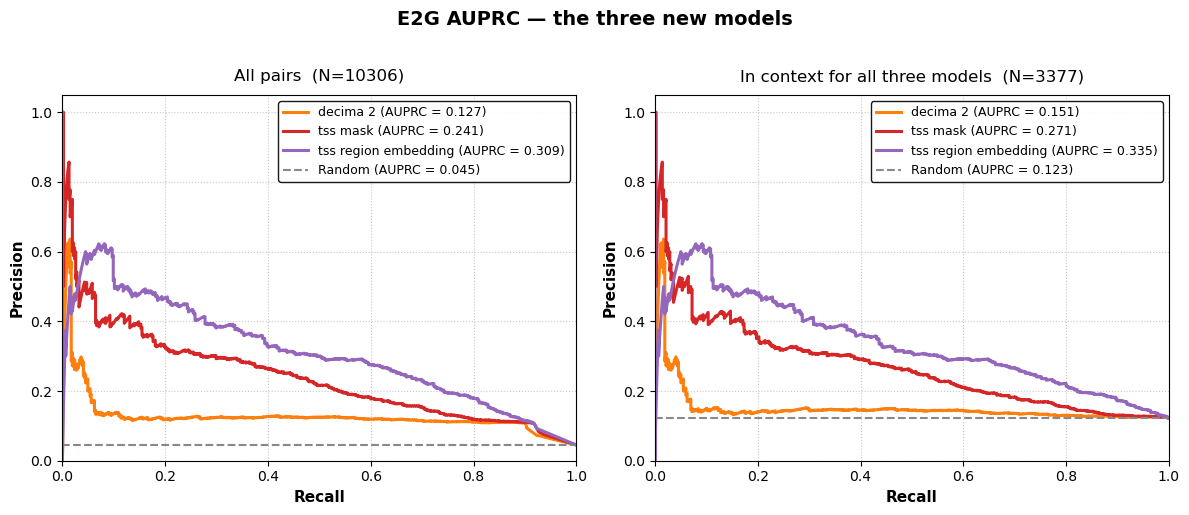

In [4]:
ctx_all_new = np.logical_and.reduce([e2g_new[n]["in_context"] for n in NAMES_NEW])
print(f"{len(gs_new)} pairs, identical for all three models (one shared gene json)")
print("in context per model: "
      + ", ".join(f"{n}={int(e2g_new[n]['in_context'].sum())}" for n in NAMES_NEW))
print(f"in context for all three: {int(ctx_all_new.sum())}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mask, subtitle in [(axes[0], np.ones(len(gs_new), bool), "All pairs"),
                           (axes[1], ctx_all_new, "In context for all three models")]:
    yt = y_true_new[mask]
    for name in NAMES_NEW:
        prec, rec, _ = precision_recall_curve(yt, np.abs(e2g_new[name]["score"][mask]))
        ax.plot(rec, prec, color=COLORS_NEW[name], lw=2.2,
                label=f"{name} (AUPRC = {auc(rec, prec):.3f})")
    ax.axhline(yt.mean(), color="#888", lw=1.5, linestyle="--",
               label=f"Random (AUPRC = {yt.mean():.3f})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
    ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
    ax.set_title(f"{subtitle}  (N={int(mask.sum())})", fontsize=12, pad=10)
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9, edgecolor="black")

fig.suptitle("E2G AUPRC — the three new models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### R8c. Score direction

The check that failed in §8, repeated — and the answer now differs per model, so §8's blanket
conclusion ("the sign is not consistent") does not carry over uniformly. Two things are worth
separating:

**The offset.** Mean in-context score is *positive* for all three (+0.018 / +0.006 / +0.001), and
only 19% / 31% / 45% of in-context scores are negative. Reducing an enhancer's accessibility more
often raises the prediction than lowers it, in every model. That is the same pathology §8 found, so
the revised `Softplus`-free head did not cause it and does not fix it.

**The ranking.** The offset does not settle which direction ranks CRISPR-positive pairs highest, and
here the three models disagree:

- `decima 2` — `-score` (AUPRC 0.207 in context) beats `|score|` (0.133) and `+score` (0.105). The
  physically expected direction *is* the discriminative one, despite the positive offset: regulated
  pairs get relatively more negative scores than non-regulated ones.
- `tss mask` — inverted. `+score` (0.240) and `|score|` (0.257) both far exceed `-score` (0.105).
- `tss region embedding` — no usable sign. `|score|` (0.331) beats `-score` (0.214) and `+score`
  (0.211), which are near-identical.

So only `tss mask` is outright inverted; `decima 2` is directionally correct but weak; and
`tss region embedding` carries the strongest magnitude signal with no consistent direction. For the
two latter models `|score|` is still absorbing an inconsistency rather than measuring a directional
effect, which is what §8 warned about.

run                       mean score  % negative       std  (in-context pairs)
decima 2                     +0.0184      19.3%    0.0574
tss mask                     +0.0060      30.9%    0.0321
tss region embedding         +0.0012      45.4%    0.0517


,model,subset,N,baseline,|score|,-score,+score
0,decima 2,all,10306,0.0451,0.1266,0.1424,0.0819
1,decima 2,in context,3914,0.1071,0.1334,0.2069,0.1050
2,tss mask,all,10306,0.0451,0.2414,0.0621,0.2128
3,tss mask,in context,3957,0.1077,0.2574,0.1051,0.2399
4,tss region embedding,all,10306,0.0451,0.3089,0.1740,0.1751
5,tss region embedding,in context,3957,0.1077,0.3306,0.2138,0.2112


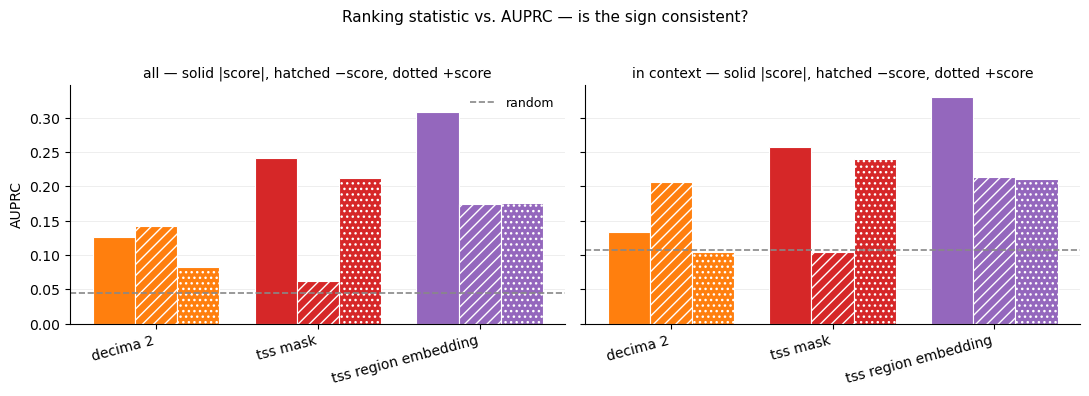

In [5]:
print(f"{'run':24s}{'mean score':>12s}{'% negative':>12s}{'std':>10s}  (in-context pairs)")
for name in NAMES_NEW:
    d = e2g_new[name]
    s = d["score"][d["in_context"]]
    print(f"{name:24s}{s.mean():+12.4f}{np.mean(s < 0):11.1%}{s.std():10.4f}")

variants = {"|score|": np.abs, "-score": lambda s: -s, "+score": lambda s: s}

rows = []
for name in NAMES_NEW:
    d = e2g_new[name]
    for subset, mask in [("all", np.ones(len(y_true_new), bool)), ("in context", d["in_context"])]:
        yt = y_true_new[mask]
        entry = {"model": name, "subset": subset, "N": int(mask.sum()), "baseline": yt.mean()}
        for vname, fn in variants.items():
            prec, rec, _ = precision_recall_curve(yt, fn(d["score"][mask]))
            entry[vname] = auc(rec, prec)
        rows.append(entry)
sign_df_new = pd.DataFrame(rows)
display(sign_df_new.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
x = np.arange(len(NAMES_NEW))
w = 0.26
for ax, subset in zip(axes, ["all", "in context"]):
    sub = sign_df_new[sign_df_new["subset"] == subset].set_index("model")
    for i, (vname, hatch) in enumerate(zip(variants, [None, "///", "..."])):
        ax.bar(x + (i - 1) * w, [sub.loc[n, vname] for n in NAMES_NEW], w,
               color=[COLORS_NEW[n] for n in NAMES_NEW], hatch=hatch, edgecolor="white",
               linewidth=0.8)
    ax.axhline(sub["baseline"].mean(), color="#888", linestyle="--", lw=1.2, label="random")
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES_NEW, rotation=15, ha="right")
    ax.set_title(f"{subset} — solid |score|, hatched −score, dotted +score", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Ranking statistic vs. AUPRC — is the sign consistent?", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

### R8d. Model score vs. CRISPRi effect size

As in §8 the plotted score is `-score`, so positive means "predicted to be repressed by the
knockdown". No rescaling this time — all three are in natural log. Statistics are given for
in-context pairs (the only ones where the perturbation did anything) and for all pairs.

**Reading the sign:** every `Regulated` pair in the benchmark has a *negative* `EffectSize`
(mean −0.162, max −0.0008), so a model that gets the direction right should produce a **negative**
`r` here — high model score (predicted repression) pairing with strongly negative effect size. A
positive `r` means the model moves the wrong way.

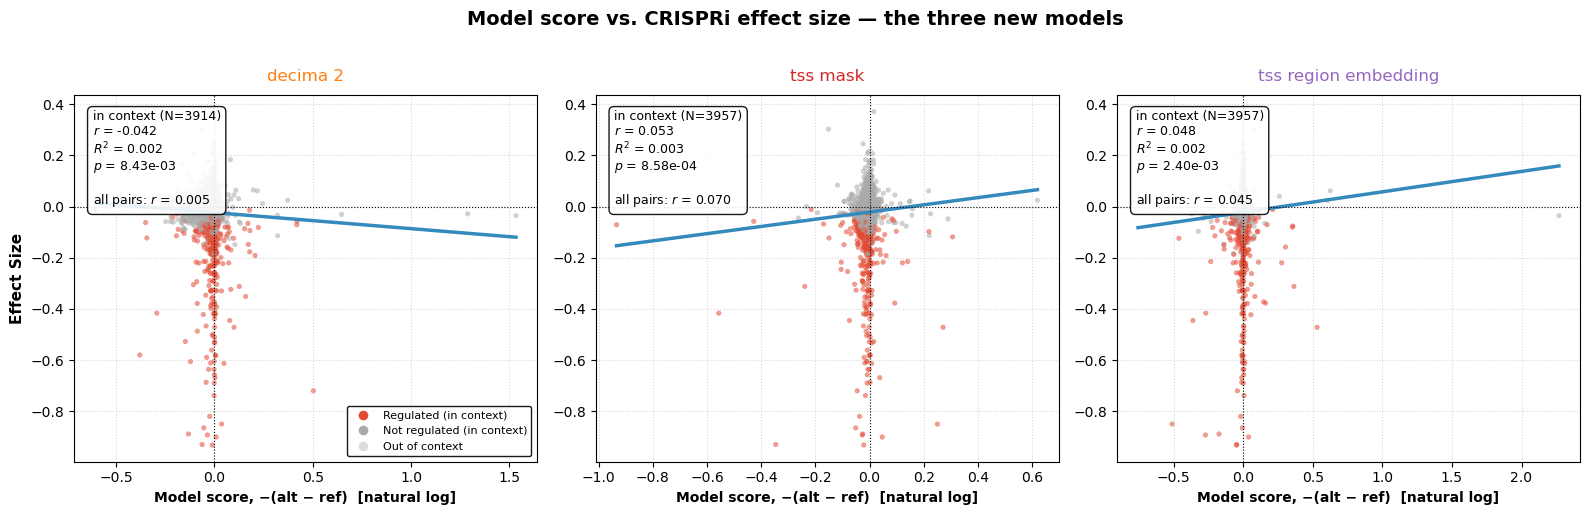

In [6]:
from scipy import stats
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, NAMES_NEW):
    d = e2g_new[name]
    model_score = -d["score"]          # no scale factor: already natural log
    ctx = d["in_context"]

    ax.scatter(model_score[~ctx], effect_new[~ctx], c="#dddddd", alpha=0.4, s=10,
               linewidths=0, rasterized=True)
    colors = np.where(gs_new["Regulated"].values.astype(bool), "#E24A33", "#aaaaaa")
    ax.scatter(model_score[ctx], effect_new[ctx], c=colors[ctx], alpha=0.55, s=14,
               linewidths=0, rasterized=True)

    # fit on in-context pairs only; out-of-context scores are structurally ~0
    slope, intercept, r_ctx, p_ctx, _ = stats.linregress(model_score[ctx], effect_new[ctx])
    xs = np.linspace(model_score[ctx].min(), model_score[ctx].max(), 200)
    ax.plot(xs, intercept + slope * xs, color="#348ABD", lw=2.5)

    r_all = stats.pearsonr(model_score, effect_new)[0]
    p_str = f"{p_ctx:.2e}" if p_ctx > 1e-300 else "< 1e-300"
    textstr = (f"in context (N={int(ctx.sum())})\n$r$ = {r_ctx:.3f}\n$R^2$ = {r_ctx**2:.3f}\n"
               f"$p$ = {p_str}\n\nall pairs: $r$ = {r_all:.3f}")
    ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.9))

    ax.axhline(0, color="black", lw=0.8, linestyle=":")
    ax.axvline(0, color="black", lw=0.8, linestyle=":")
    ax.set_xlabel("Model score, −(alt − ref)  [natural log]", fontsize=10, fontweight="bold")
    ax.set_title(name, fontsize=12, pad=10, color=COLORS_NEW[name])
    ax.grid(True, linestyle=":", alpha=0.5)

axes[0].set_ylabel("Effect Size", fontsize=11, fontweight="bold")
axes[0].legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E24A33", markersize=8,
           label="Regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#aaaaaa", markersize=8,
           label="Not regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#dddddd", markersize=8,
           label="Out of context"),
], loc="lower right", fontsize=8, framealpha=0.9, edgecolor="black")

fig.suptitle("Model score vs. CRISPRi effect size — the three new models", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Takeaways — E2G (R8)

Prevalence baseline AUPRC is 0.045 over all 10306 pairs and ~0.108 over in-context pairs; 465 pairs
are labelled `Regulated`.

| model | AUPRC abs(score), all | AUPRC abs(score), in ctx | best variant, in ctx | effect-size r, in ctx | in-ctx pairs |
|---|---|---|---|---|---|
| `tss region embedding` | **0.309** | **0.331** | abs(score), 0.331 | +0.048 (wrong sign) | 3957 |
| `tss mask` | 0.241 | 0.257 | abs(score), 0.257 | +0.053 (wrong sign) | 3957 |
| `decima 2` | 0.127 | 0.133 | −score, **0.207** | −0.042 (right sign) | 3914 |

- **The E2G ordering is the reverse of the expression ordering.** `tss region embedding` is the
  weakest at predicting expression (r 0.891, MSE 0.757 in R1) but the strongest here — 0.331 against
  a 0.108 baseline, roughly 3×. `decima 2` won the per-gene expression comparison but sits barely
  above baseline on E2G (0.133 vs 0.108). Absolute-expression accuracy and responsiveness to
  enhancer perturbation are coming apart, so neither metric alone ranks these three.
- The one model whose decoder reads out a *local* region rather than the whole window is the one
  that responds best to a local perturbation. That is a suggestive pattern, not a demonstrated
  mechanism — `tss region embedding` also differs in having no extra input channel, so this needs a
  targeted ablation before being believed.
- **All the effects are tiny.** In-context score std is 0.032–0.057 in natural log against reference
  predictions averaging 4.1–4.6, i.e. the perturbation moves predictions by well under 1%. They are
  nonetheless real signal, not numerical noise: out-of-context scores sit at ~1e-6, four to five
  orders of magnitude below.
- **Effect-size correlation is negligible for all three** (|r| ≤ 0.053, R² ≤ 0.003). The p-values
  look significant only because N ≈ 3900. Whatever ranking signal the AUPRCs pick up, none of these
  models tracks CRISPRi effect *magnitude*.
- `decima 2` loses 43 in-context pairs (3914 vs 3957) to its asymmetric window, and 3377 pairs are
  in context for all three — that is the subset the right-hand panel of R8b uses.
- Directionality remains the open problem, and it is not the old decoder's fault: see R8c.

# Adding two more models: an RNA-profile TSS model and a bp-resolution 3′ profile model

Sections P1–P7 repeat R1–R7 with a **fourth** expression model, and P8 repeats R8 with that model
plus a **fifth** model that exists only on the E2G side.

| name here | run | checkpoint | what it is |
|---|---|---|---|
| `rna profile` | `2026-08-05/12-48-43-803485` | `31-val_loss=1.47817` | `decima 2`'s setup — mask as the 6th input channel, asymmetric window (`upstream=163840`), decoder pools the whole window — but with the `tss_profile` decoder: a scalar count head **plus** a bp-resolution stranded RNA profile head, trained with `tss_profile_loss` (`count_weight=1.0`, `profile_weight=1e-6`, multinomial profile term). |
| `3prime profile` | precomputed csv, **E2G only** | — | the bp-resolution 3′ RNA-seq profile model from `evals/e2g_3prime.py` (`enformer` decoder, `yshape=524288`, `bin_size=1`, `d_output=2` = plus/minus strand). It has no scalar expression head and no `.npz`, so it cannot appear in P1–P7. |

**Caveats specific to these two:**

1. **`rna profile`'s val loss is not comparable to the R-section three.** `1.478` mixes the count
   MSE with the multinomial profile term, while the other three report a pure count loss
   (0.656 / 0.688 / 0.849). Epoch is 31, not 16, so this is neither matched training length nor
   matched convergence — it is here to be compared on *test metrics*, not on val loss.
2. **`rna profile` shares `decima 2`'s window geometry exactly.** Its `_in_context.npy` is
   bit-identical to `decima 2`'s (3914 pairs), which is what the same asymmetric window should
   produce, and a free check that the E2G harness is deterministic. The cell below asserts it.
3. **`3prime profile` sits on a different pair set.** `evals/e2g_3prime.py:182` builds `gs_df` from
   `k562_bulk_rna_info.json`, giving **10280** pairs — a strict subset of the 10306 the four TSS
   models use (the overlap is all 10280, and the labels agree on every one). Its rows are grouped
   by `ensg_id` rather than left in input order, so they are re-sorted by `row_idx` first; the cell
   below asserts that this reproduces the bulk-json `gs_df` order exactly.
4. **Only the `raw_*` columns are read.** `sqrt_*` sums predictions in the variance-stabilized
   space the model was trained in, where the no-signal baseline is `sqrt(1) = 1.0` *per bp* — so
   summing over a 9 kb gene body accumulates ~9000 units of pure baseline and crushes the
   fold-change toward zero. `raw_*` undoes the transform with `clip(pred**2 - 1, 0, None)` first.
   Nothing below touches a `sqrt_*` column.
5. **`3prime profile`'s score is a different quantity.** The four TSS models give a difference of
   two predicted log-expression scalars (natural log). The 3′ model gives a log2 fold-change of
   *summed profile counts* over a genomic window. AUPRC is rank-based so the comparison is valid
   there; the effect-size panels label each x-axis with its own units and are not overlayable.

In [1]:
# --- P1: the three 2026-07-27 runs plus the RNA-profile run ------------------------------------
# Self-contained like the R section: re-imports and re-declares everything it uses, so P1-P8 can
# be run without the cells above.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde

MODEL_OUT = "/data1/lesliec/sarthak/data/joint_playground/model_out"

FILES_P = {
    "decima 2":             f"{MODEL_OUT}/k562_decima_2.npz",
    "tss mask":             f"{MODEL_OUT}/k562_tssmask.npz",
    "tss region embedding": f"{MODEL_OUT}/k562_finetune_2.npz",
    "rna profile":          f"{MODEL_OUT}/k562_tss_sc_rna_profile2_ep31.npz",
}

COLORS_P = {
    "decima 2":             "#ff7f0e",
    "tss mask":             "#d62728",
    "tss region embedding": "#9467bd",
    "rna profile":          "#17becf",
    "3prime profile":       "#8c564b",   # E2G only, used from P8 on
}
NAMES_P = list(FILES_P)

runs_p = {}
for name, path in FILES_P.items():
    d = np.load(path, allow_pickle=True)
    runs_p[name] = {
        "genes": d["genes"],
        "preds": d["preds"].ravel(),
        "targets": d["targets"],
        "chroms": d["chroms"],
        "strands": d["strands"],
        "ckpt": str(d["ckpt_path"]),
        "tss_json": str(d["tss_json_file"]),
    }
    print(f"{name:22s} n={len(d['genes']):5d}  "
          f"targets={str(d['tss_json_file']).split('/')[-1]}  "
          f"ckpt={'/'.join(str(d['ckpt_path']).split('/')[-3:])}")

decima 2               n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=21-54-24-337889/checkpoints/16-val_loss=0.65628.ckpt
tss mask               n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=23-00-33-044232/checkpoints/16-val_loss=0.68752.ckpt
tss region embedding   n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=22-39-32-007131/checkpoints/16-val_loss=0.84871.ckpt
rna profile            n= 1844  targets=k562_sc_rna_info_cellranger.json  ckpt=12-48-43-803485/checkpoints/31-val_loss=1.47817.ckpt


In [2]:
# Align on the shared gene set. All four used k562_sc_rna_info_cellranger.json and the same split,
# so this is expected to be all 1844 genes; the intersection is kept anyway.
common_p = sorted(set.intersection(*[set(r["genes"].tolist()) for r in runs_p.values()]))
print(f"{len(common_p)} genes shared across the four runs")

for name, r in runs_p.items():
    idx_by_gene = {g: i for i, g in enumerate(r["genes"].tolist())}
    order = [idx_by_gene[g] for g in common_p]
    r["p"] = r["preds"][order]
    r["t"] = r["targets"][order]
    r["chrom"] = r["chroms"][order]
    r["strand"] = r["strands"][order]

# One shared target json means the aligned target vectors must be identical -- that is what
# licenses comparing MSE/MAE across models, so assert it rather than assume it.
ref_tp = runs_p[NAMES_P[0]]["t"]
for name in NAMES_P[1:]:
    assert np.allclose(runs_p[name]["t"], ref_tp), f"{name}: targets differ from {NAMES_P[0]}"
print("targets identical across all four runs -> MSE/MAE are directly comparable")


def metrics_p(p, t):
    return {
        "pearson": float(np.corrcoef(p, t)[0, 1]),
        "spearman": float(spearmanr(p, t).statistic),
        "mse": float(((p - t) ** 2).mean()),
        "mae": float(np.abs(p - t).mean()),
    }


stats_p = {name: metrics_p(r["p"], r["t"]) for name, r in runs_p.items()}
print(f"\n{'run':24s}{'pearson':>10s}{'spearman':>10s}{'MSE':>10s}{'MAE':>10s}")
for name in NAMES_P:
    s = stats_p[name]
    print(f"{name:24s}{s['pearson']:10.4f}{s['spearman']:10.4f}{s['mse']:10.4f}{s['mae']:10.4f}")

# Per-strand split: rc_strand reverse-complements minus-strand genes, so a gap between the two
# columns would point at the flip (coordinate mapping / mask alignment) rather than the model.
print(f"\n{'run':24s}{'r (+)':>9s}{'r (-)':>9s}{'n +':>7s}{'n -':>7s}")
for name in NAMES_P:
    r = runs_p[name]
    rs = [float(np.corrcoef(r["p"][r["strand"] == s], r["t"][r["strand"] == s])[0, 1])
          for s in (1, -1)]
    print(f"{name:24s}{rs[0]:9.4f}{rs[1]:9.4f}"
          f"{int((r['strand'] == 1).sum()):7d}{int((r['strand'] == -1).sum()):7d}")

print(f"\n{'run':24s}{'pred min':>10s}{'pred max':>10s}{'pred std':>10s}{'target std':>12s}")
for name in NAMES_P:
    p = runs_p[name]["p"]
    print(f"{name:24s}{p.min():10.3f}{p.max():10.3f}{p.std():10.3f}{ref_tp.std():12.3f}")

1844 genes shared across the four runs
targets identical across all four runs -> MSE/MAE are directly comparable

run                        pearson  spearman       MSE       MAE
decima 2                    0.9057    0.9073    0.6974    0.5683
tss mask                    0.9092    0.8978    0.6350    0.5598
tss region embedding        0.8912    0.8729    0.7567    0.6192
rna profile                 0.8912    0.8777    0.7645    0.6135

run                         r (+)    r (-)    n +    n -
decima 2                   0.9068   0.9047    916    928
tss mask                   0.9084   0.9101    916    928
tss region embedding       0.8876   0.8948    916    928
rna profile                0.8892   0.8933    916    928

run                       pred min  pred max  pred std  target std
decima 2                    -0.051     6.065     1.863       1.908
tss mask                    -0.055     5.830     1.766       1.908
tss region embedding        -0.418     6.886     1.788       1.908
rna pr

## P1. Metrics per run

Same targets, same genes for all four. Epoch is *not* matched: 16 for the first three, 31 for
`rna profile`.

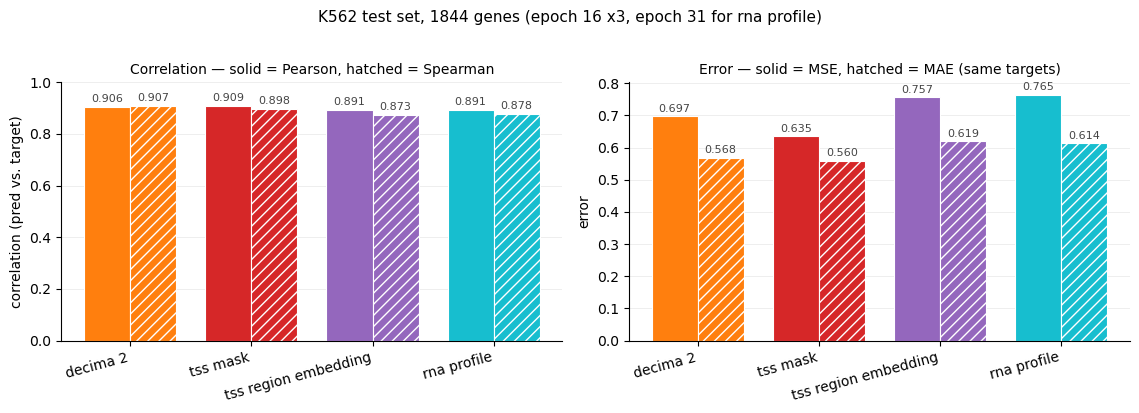

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
x = np.arange(len(NAMES_P))
w = 0.38

ax = axes[0]
for off, key, hatch in [(-w / 2, "pearson", None), (w / 2, "spearman", "///")]:
    vals = [stats_p[n][key] for n in NAMES_P]
    ax.bar(x + off, vals, w, color=[COLORS_P[n] for n in NAMES_P],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.012, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color="#444")
ax.set_ylim(0, 1.0)
ax.set_ylabel("correlation (pred vs. target)")
ax.set_title("Correlation — solid = Pearson, hatched = Spearman", fontsize=10)

ax = axes[1]
for off, key, hatch in [(-w / 2, "mse", None), (w / 2, "mae", "///")]:
    vals = [stats_p[n][key] for n in NAMES_P]
    ax.bar(x + off, vals, w, color=[COLORS_P[n] for n in NAMES_P],
           hatch=hatch, edgecolor="white", linewidth=0.8)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.008, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color="#444")
ax.set_ylabel("error")
ax.set_title("Error — solid = MSE, hatched = MAE (same targets)", fontsize=10)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES_P, rotation=15, ha="right")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle(f"K562 test set, {len(common_p)} genes (epoch 16 x3, epoch 31 for rna profile)",
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

## P2. Distribution of predicted and observed values

Target drawn once as a filled gray reference — it is identical for all four. The right panel is
the residual distribution: a shift off zero is bias, a wide spread is variance.

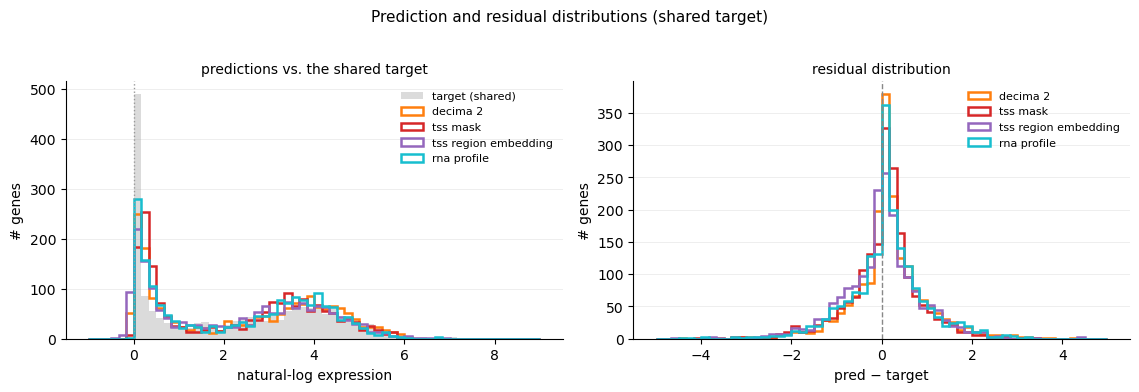

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
bins = np.linspace(-1, 9, 61)

ax = axes[0]
# target drawn once as a filled reference: it is identical for all four models
ax.hist(ref_tp, bins=bins, color="#cccccc", alpha=0.7, label="target (shared)", zorder=0)
for name in NAMES_P:
    ax.hist(runs_p[name]["p"], bins=bins, histtype="step", linewidth=1.8,
            color=COLORS_P[name], label=name)
ax.axvline(0, color="#999", linestyle=":", linewidth=1.0)
ax.set_xlabel("natural-log expression")
ax.set_ylabel("# genes")
ax.set_title("predictions vs. the shared target", fontsize=10)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
for name in NAMES_P:
    ax.hist(runs_p[name]["p"] - ref_tp, bins=np.linspace(-5, 5, 61), histtype="step",
            linewidth=1.8, color=COLORS_P[name], label=name)
ax.axvline(0, color="#888", linestyle="--", linewidth=1.0)
ax.set_xlabel("pred − target")
ax.set_ylabel("# genes")
ax.set_title("residual distribution", fontsize=10)
ax.legend(frameon=False, fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle("Prediction and residual distributions (shared target)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

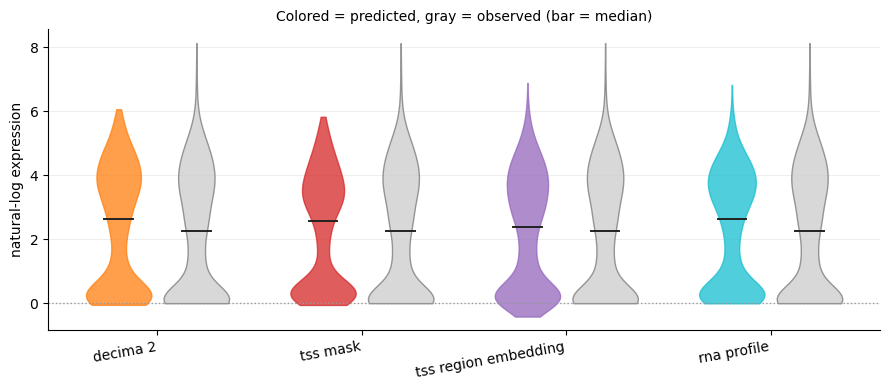

In [5]:
# Same information as paired violins: for each run, predicted vs. observed spread.
fig, ax = plt.subplots(figsize=(9, 4))

positions, data, face, edge = [], [], [], []
for i, name in enumerate(NAMES_P):
    positions += [i - 0.19, i + 0.19]
    data += [runs_p[name]["p"], runs_p[name]["t"]]
    face += [COLORS_P[name], "#cccccc"]
    edge += [COLORS_P[name], "#777777"]

parts = ax.violinplot(data, positions=positions, widths=0.32, showextrema=False)
for body, fc, ec in zip(parts["bodies"], face, edge):
    body.set_facecolor(fc)
    body.set_edgecolor(ec)
    body.set_alpha(0.75)
    body.set_linewidth(1.0)

for pos, arr in zip(positions, data):
    ax.plot([pos - 0.07, pos + 0.07], [np.median(arr)] * 2, color="#222", linewidth=1.4)

ax.axhline(0, color="#999", linestyle=":", linewidth=1.0)
ax.set_xticks(np.arange(len(NAMES_P)))
ax.set_xticklabels(NAMES_P, rotation=10, ha="right")
ax.set_ylabel("natural-log expression")
ax.set_title("Colored = predicted, gray = observed (bar = median)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## P3. Predicted vs. observed, per run

Density-colored scatter; dashed line is `y = x`. All four panels share the same x axis (the common
target), so they are overlayable by eye.

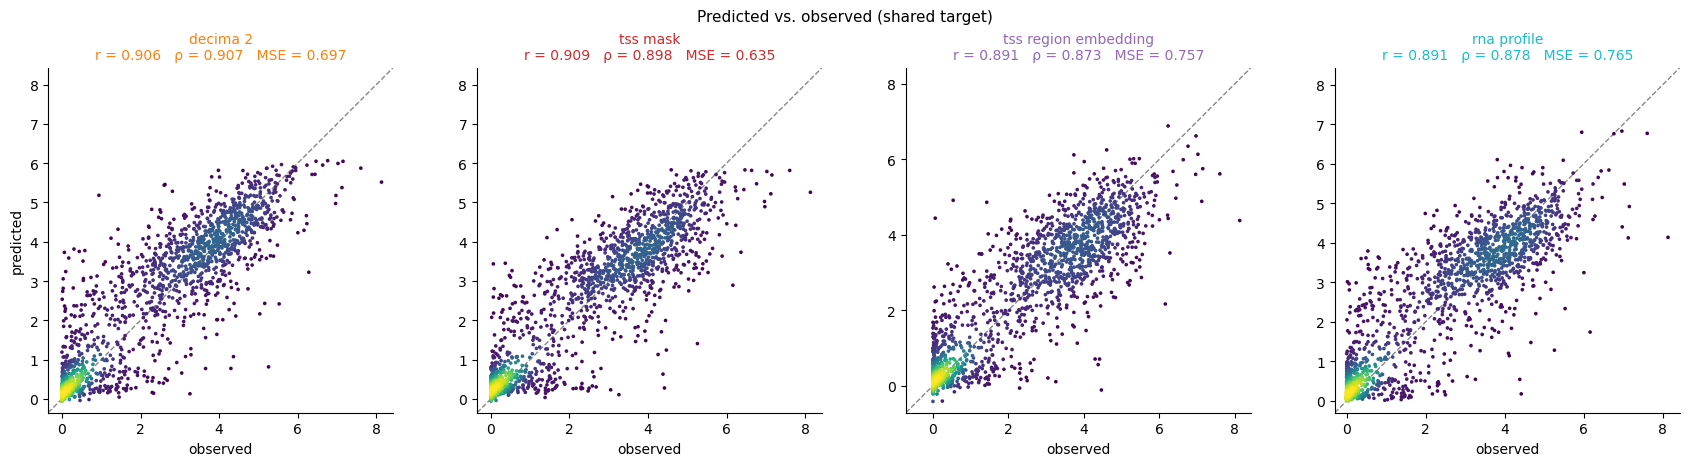

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(17.5, 4.4))

for ax, name in zip(axes, NAMES_P):
    t, p = runs_p[name]["t"], runs_p[name]["p"]
    dens = gaussian_kde(np.vstack([t, p]))(np.vstack([t, p]))
    order = dens.argsort()  # draw dense points last so they are not buried
    ax.scatter(t[order], p[order], c=dens[order], s=7, cmap="viridis", linewidths=0)

    lim = (min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    s = stats_p[name]
    ax.set_title(f"{name}\nr = {s['pearson']:.3f}   ρ = {s['spearman']:.3f}   MSE = {s['mse']:.3f}",
                 fontsize=10, color=COLORS_P[name])
    ax.set_xlabel("observed")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("predicted")
fig.suptitle("Predicted vs. observed (shared target)", fontsize=11, y=1.0)
fig.tight_layout()
plt.show()

## P4. Model vs. model

Predictions compared directly — six pairs now. All four are in natural log, so `y = x` is
meaningful as-is with no rescaling.

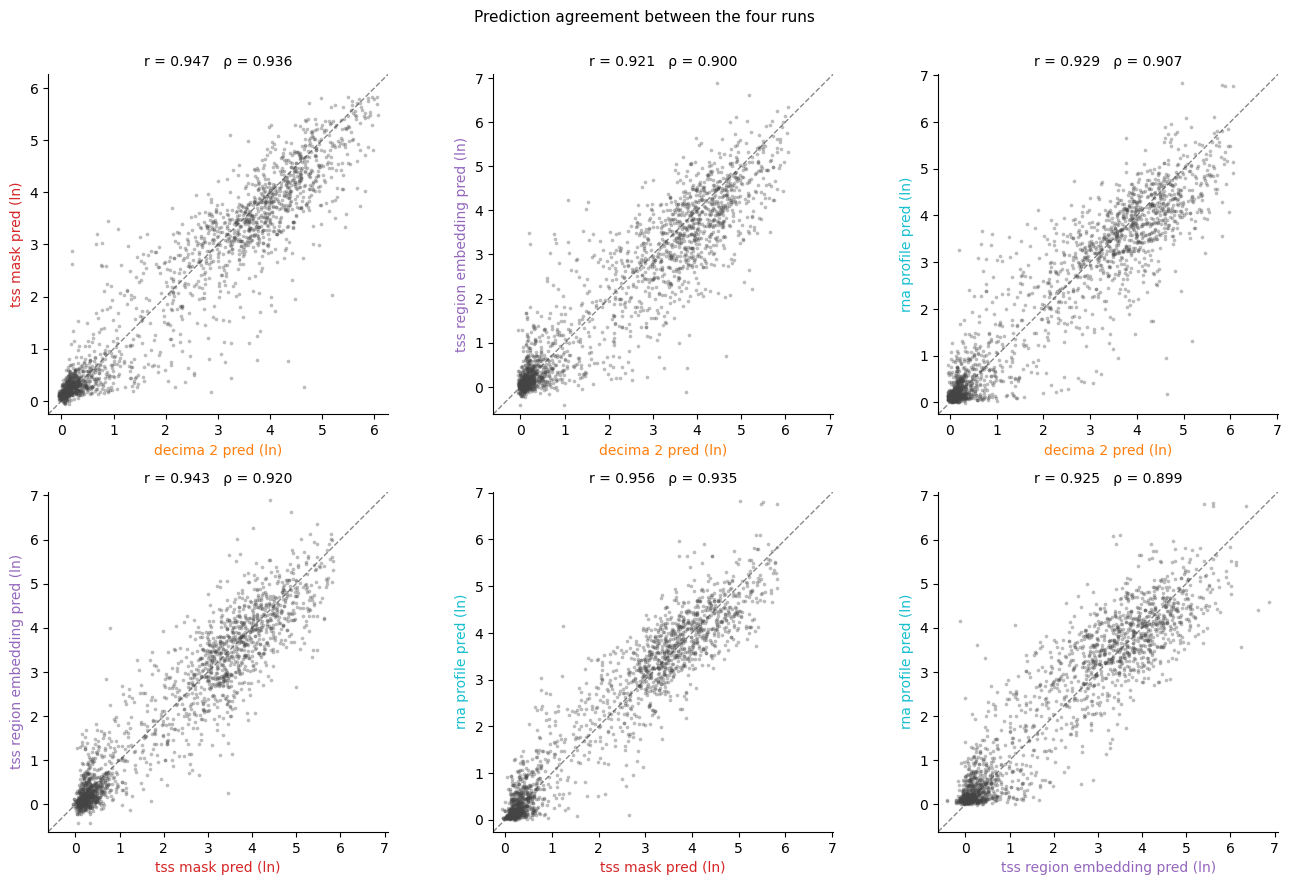

In [7]:
pairs_p = [(a, b) for i, a in enumerate(NAMES_P) for b in NAMES_P[i + 1:]]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.8))

for ax, (a, b) in zip(axes.ravel(), pairs_p):
    pa, pb = runs_p[a]["p"], runs_p[b]["p"]
    ax.scatter(pa, pb, s=7, alpha=0.35, color="#444", linewidths=0)

    lim = (min(pa.min(), pb.min()) - 0.2, max(pa.max(), pb.max()) + 0.2)
    ax.plot(lim, lim, "--", color="#888", linewidth=1.0, zorder=0)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")

    r = np.corrcoef(pa, pb)[0, 1]
    rho = spearmanr(pa, pb).statistic
    ax.set_title(f"r = {r:.3f}   ρ = {rho:.3f}", fontsize=10)
    ax.set_xlabel(f"{a} pred (ln)", color=COLORS_P[a])
    ax.set_ylabel(f"{b} pred (ln)", color=COLORS_P[b])
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Prediction agreement between the four runs", fontsize=11, y=1.0)
fig.tight_layout()
plt.show()

### P4b. Per-gene head-to-head

For each gene, which model is closest? A model can win on aggregate MSE while losing on most
individual genes (a few large misses dominate the mean), so the win rate and the aggregate metric
answer different questions.

share of genes where each model has the smallest |error| of the four:
  decima 2                  31.5%
  tss mask                  20.7%
  tss region embedding      24.9%
  rna profile               22.8%

pairwise win rate (row model closer than column model, per gene):
                                  decima 2        tss mask  tss region emb     rna profile
decima 2                                            55.0%           56.2%           56.0% 
tss mask                            45.0%                           52.3%           52.7% 
tss region embedding                43.8%           47.7%                           50.8% 
rna profile                         44.0%           47.3%           49.2%                 


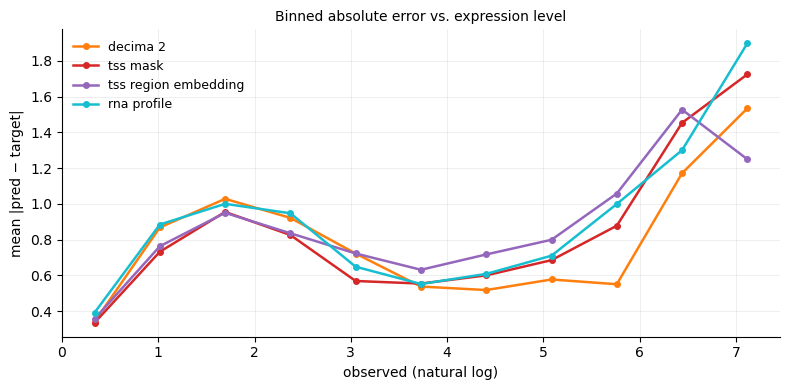

In [8]:
abs_err_p = {n: np.abs(runs_p[n]["p"] - ref_tp) for n in NAMES_P}
best_p = np.vstack([abs_err_p[n] for n in NAMES_P]).argmin(axis=0)

print("share of genes where each model has the smallest |error| of the four:")
for i, n in enumerate(NAMES_P):
    print(f"  {n:24s}{(best_p == i).mean():7.1%}")

print("\npairwise win rate (row model closer than column model, per gene):")
print(f"{'':26s}" + "".join(f"{n[:14]:>16s}" for n in NAMES_P))
for a in NAMES_P:
    row = ["".ljust(16) if a == b else f"{(abs_err_p[a] < abs_err_p[b]).mean():15.1%} "
           for b in NAMES_P]
    print(f"{a:26s}" + "".join(row))

# Where in the expression range each model wins or loses -- the aggregate MSE hides this.
fig, ax = plt.subplots(figsize=(8, 4))
edges = np.linspace(ref_tp.min(), ref_tp.max(), 13)
centers = 0.5 * (edges[:-1] + edges[1:])
for n in NAMES_P:
    means = [abs_err_p[n][(ref_tp >= lo) & (ref_tp < hi)].mean()
             if ((ref_tp >= lo) & (ref_tp < hi)).sum() > 3 else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centers, means, color=COLORS_P[n], linewidth=1.8, marker="o", markersize=4, label=n)
ax.set_xlabel("observed (natural log)")
ax.set_ylabel("mean |pred − target|")
ax.set_title("Binned absolute error vs. expression level", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## P5. Per-chromosome correlation

Checks whether any single test chromosome drives the overall numbers.

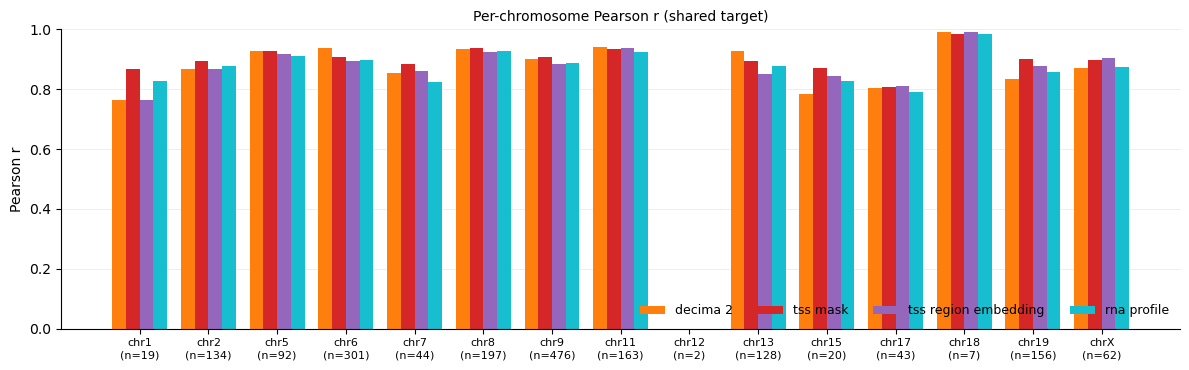

In [9]:
chroms_p = sorted(set(runs_p[NAMES_P[0]]["chrom"].tolist()),
                  key=lambda c: (c == "chrX", int(c[3:]) if c[3:].isdigit() else 99))
counts_p = [int((runs_p[NAMES_P[0]]["chrom"] == c).sum()) for c in chroms_p]

fig, ax = plt.subplots(figsize=(12, 3.8))
w = 0.2
for i, name in enumerate(NAMES_P):
    r = runs_p[name]
    vals = []
    for c in chroms_p:
        m = r["chrom"] == c
        vals.append(float(np.corrcoef(r["p"][m], r["t"][m])[0, 1]) if m.sum() > 2 else np.nan)
    ax.bar(np.arange(len(chroms_p)) + (i - 1.5) * w, vals, w, color=COLORS_P[name], label=name)

ax.set_xticks(np.arange(len(chroms_p)))
ax.set_xticklabels([f"{c}\n(n={m})" for c, m in zip(chroms_p, counts_p)], fontsize=8)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, fontsize=9, ncol=4, loc="lower right")
ax.set_title("Per-chromosome Pearson r (shared target)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## P6. Where the error lives

Signed residual (`pred − target`) against observed expression. A downward trend means the model
over-predicts silent genes and under-predicts highly expressed ones — regression toward the mean.

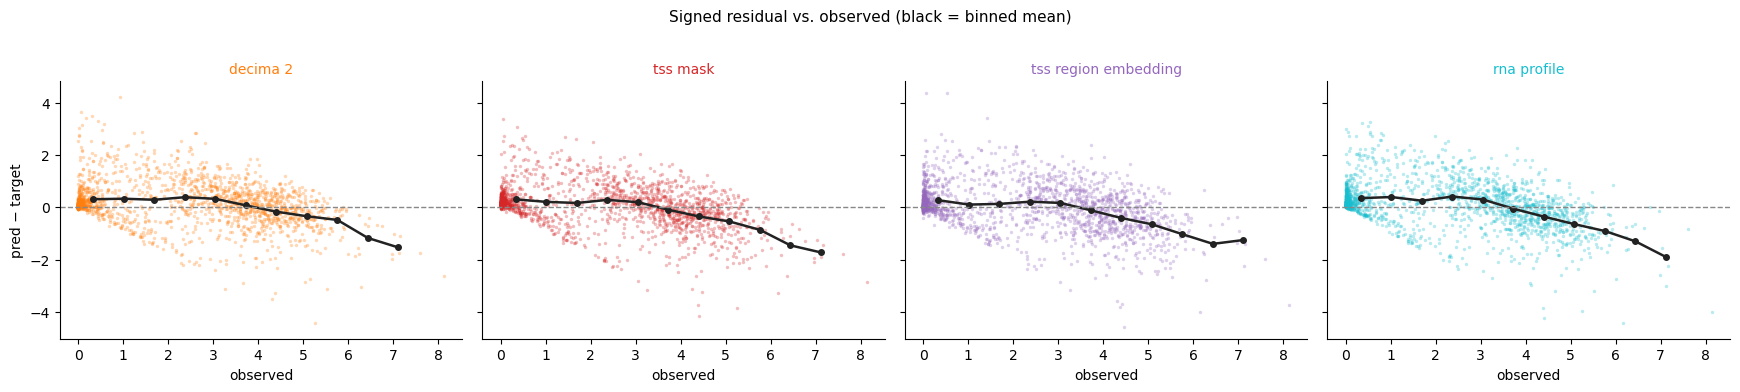

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(17.5, 3.8), sharey=True)

for ax, name in zip(axes, NAMES_P):
    t, p = runs_p[name]["t"], runs_p[name]["p"]
    resid = p - t
    ax.scatter(t, resid, s=6, alpha=0.3, color=COLORS_P[name], linewidths=0)

    # binned mean residual, to make the trend readable through the point cloud
    edges = np.linspace(t.min(), t.max(), 13)
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = [resid[(t >= lo) & (t < hi)].mean() if ((t >= lo) & (t < hi)).sum() > 3 else np.nan
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(centers, means, color="#222", linewidth=1.8, marker="o", markersize=4)

    ax.axhline(0, color="#888", linestyle="--", linewidth=1.0)
    ax.set_xlabel("observed")
    ax.set_title(name, fontsize=10, color=COLORS_P[name])
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("pred − target")
fig.suptitle("Signed residual vs. observed (black = binned mean)", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

## P7. Rank profile

Genes sorted by observed expression with the prediction overlaid. The ordering is identical across
panels, so the traces can be compared position by position.

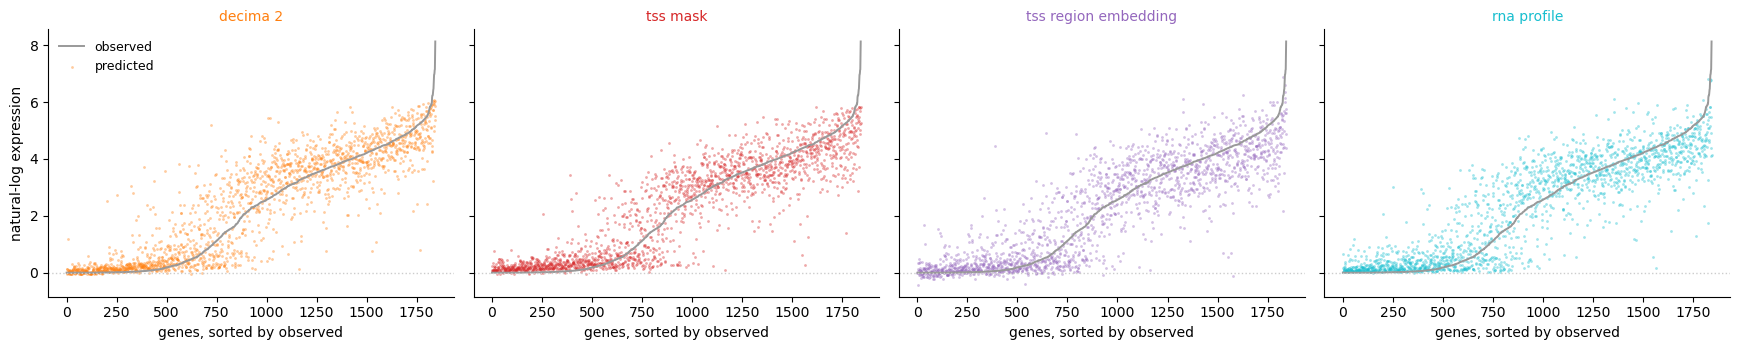

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(17.5, 3.6), sharey=True)

for ax, name in zip(axes, NAMES_P):
    t, p = runs_p[name]["t"], runs_p[name]["p"]
    order = np.argsort(t)
    xs = np.arange(len(order))
    ax.plot(xs, t[order], color="#999", linewidth=1.4, label="observed")
    ax.scatter(xs, p[order], s=4, alpha=0.4, color=COLORS_P[name], linewidths=0,
               label="predicted")
    ax.axhline(0, color="#ccc", linestyle=":", linewidth=1.0)
    ax.set_xlabel("genes, sorted by observed")
    ax.set_title(name, fontsize=10, color=COLORS_P[name])
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("natural-log expression")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

### Takeaways — expression (P1–P7)

| model | Pearson r | Spearman ρ | MSE | MAE | pred range | pred std | closest on |
|---|---|---|---|---|---|---|---|
| `tss mask` | **0.9092** | 0.8978 | **0.6350** | **0.5598** | −0.05 → 5.83 | 1.766 | 20.7% |
| `decima 2` | 0.9057 | **0.9073** | 0.6974 | 0.5683 | −0.05 → 6.07 | 1.863 | **31.5%** |
| `tss region embedding` | 0.8912 | 0.8729 | 0.7567 | 0.6192 | −0.42 → 6.89 | 1.788 | 24.9% |
| `rna profile` | 0.8912 | 0.8777 | 0.7645 | 0.6135 | −0.00 → 6.83 | 1.770 | 22.8% |

(target std 1.908, target max 8.13; "closest on" = share of the 1844 genes where that model has the
smallest absolute error of the four.)

- **Adding the bp-resolution profile head costs a little expression accuracy.** `rna profile` and
  `decima 2` share their entire input/window/pooling design and differ only in the decoder and loss,
  so this pair *is* a clean ablation of the auxiliary profile head: r drops 0.906 → 0.891, MSE rises
  0.697 → 0.765, and the per-gene win rate drops 31.5% → 22.8%. The auxiliary task is not free.
  The caveat cuts the other way, though — `rna profile` is at epoch 31 rather than 16, so it has had
  *more* training, not less, and still lands lower.
- It ends up statistically tied with `tss region embedding` on Pearson r (0.8912 for both) while
  being slightly worse on MSE and slightly better on Spearman ρ and MAE. Two quite different
  designs landing in the same place.
- Its predictions are the best-behaved at the bottom of the range: minimum −0.003 against
  −0.42 for `tss region embedding`, i.e. essentially no negative predictions despite the head being
  unconstrained.
- Strand-split r is within 0.005 (0.889 / 0.893), so the `rc_strand` flip and the mask alignment are
  fine on both strands for this run too.
- Under-dispersion is unchanged: pred std 1.770 vs. target 1.908, max 6.83 vs. target 8.13. Every
  model in this notebook regresses toward the mean at the top of the range.

## P8. Enhancer–gene linking (ENCODE CRISPR benchmark)

R8 repeated with `rna profile` added, and with the precomputed `3prime profile` scores from
`evals/e2g_3prime.py` as a fifth model. All five run the same experiment — divide the accessibility
track by 100 over the CRISPR element ± 100 bp and read the change in predicted expression — but the
readout differs:

- the four TSS models give two scalars per pair, `outputs[:, 0]` (unperturbed) and `outputs[:, 1]`
  (perturbed), and the score is their difference in natural log;
- `3prime profile` gives *summed bp-resolution profile* before/after, over three genomic windows
  (`body`, `tp` = 3′-terminal 10 kb, `tss` = TSS ± 2 kb) and both strands, and the score is
  `log2fc_raw_{window}_{strand}`. `raw_*` only; see caveat 4 at the top of this section.

The headline 3′ score below is **`log2fc_raw_tp_sense`** — the window `e2g_3prime.py` argues should
be right for 3′ RNA-seq data, which piles reads at the last exon / polyA site. P8a tests that choice
against the other five window/strand combinations rather than assuming it, and the answer is not the
expected one.

Two mechanical points:

- `log2fc_raw_tp_*` is NaN on **45** rows whose 3′-terminal window falls entirely outside the
  524288 bp window (`reduce_profile`'s `hi <= lo` branch), 19 of them in context. Those rows are
  dropped from every panel that uses a `tp` score — so the `tp` window is scored on 3931 in-context
  pairs where `body` and `tss` get 3950 — and from *all five* curves in the head-to-head panels, so
  the models stay on an identical subset there.
- Out-of-context pairs are not exactly zero for any model — the TSS models carry ~1e-6 and the 3′
  model ~1e-5 of float noise — so `in_context` always comes from the stored mask/column, never from
  `score != 0`.

In [12]:
# --- P8: load the four TSS-model E2G runs plus the precomputed 3prime csv ----------------------
# Self-contained, like the rest of this section.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

E2G_DIR = "/data1/lesliec/sarthak/data/joint_playground/e2g"
RNA_INFO_DIR = "/data1/lesliec/sarthak/data/DE_danwei"
TSS_BOUNDS_FILE = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
CRISPR_FILE = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
RE2G_FILE = (f"{E2G_DIR}/ENCODE-rE2G_extended_CrossValidated_K562_"
             "EPCrisprBenchmark_ensemble_data_GRCh38.predictions.tsv.gz")
THREE_PRIME_CSV = f"{E2G_DIR}/k562_3prime_e2g.csv"

# stem of the .npy pair in e2g/ for the models evaluated by evals/e2g_tss.py
E2G_MODELS_P = {
    "decima 2":             "k562_decima_2",
    "tss mask":             "k562_tssmask",
    "tss region embedding": "k562_finetune_2",
    "rna profile":          "k562_tss_sc_rna_profile2_ep31",
}
SHARED_JSON = "k562_sc_rna_info_cellranger.json"      # gene filter for the four above
THREE_PRIME_JSON = "k562_bulk_rna_info.json"          # e2g_3prime.py:182 uses a different one

# raw_* undoes the sqrt(1+x) target transform; the sqrt_* columns are never read here.
THREE_PRIME_COL = "log2fc_raw_tp_sense"   # headline window, tested in P8a
THREE_PRIME_ALT = "log2fc_raw_tss_sense"  # second window, shown dashed in P8b

# repeated so this section runs standalone
COLORS_P = {
    "decima 2":             "#ff7f0e",
    "tss mask":             "#d62728",
    "tss region embedding": "#9467bd",
    "rna profile":          "#17becf",
    "3prime profile":       "#8c564b",
}
NAMES_P = list(E2G_MODELS_P)
NAMES_P5 = NAMES_P + ["3prime profile"]

tss_bounds = pd.read_csv(TSS_BOUNDS_FILE, sep="\t")
crispr = pd.read_csv(CRISPR_FILE, sep="\t")
crispr["master"] = (crispr["chrom"] + ":" + crispr["chromStart"].astype(str) + "-"
                    + crispr["chromEnd"].astype(str) + "_" + crispr["measuredGeneSymbol"])
assert crispr["master"].is_unique, "master must be unique to key the models against each other"

re2g = pd.read_csv(RE2G_FILE, sep="\t")
re2g["master"] = (re2g["chr"] + ":" + re2g["start"].astype(str) + "-"
                  + re2g["end"].astype(str) + "_" + re2g["TargetGene"])
assert re2g["master"].is_unique, "rE2G master keys must be unique for a left merge to stay aligned"
dist_by_master = re2g.set_index("master")["DistanceToTSS"]
effect_by_master = crispr.set_index("master")["EffectSize"]


def build_gs(json_name):
    """The gene filter from evals/e2g_tss.py / e2g_3prime.py, for one rna_info json."""
    with open(f"{RNA_INFO_DIR}/{json_name}") as f:
        tss_dict = json.load(f)
    name_to_ensg = tss_bounds.set_index("name")["Ensembl_ID"].to_dict()
    name_to_ensg = {n: e for n, e in name_to_ensg.items() if e in tss_dict}
    gs = crispr.copy()
    gs["ensg_id"] = gs["measuredGeneSymbol"].map(name_to_ensg)
    return gs.dropna(subset=["ensg_id", "Regulated"]).reset_index(drop=True)


# --- the four TSS models: one shared gs_df, as in R8 -------------------------------------------
gs_p = build_gs(SHARED_JSON)
# left merge keeps gs_p order and length; pairs absent from rE2G become NaN and drop out of the
# distance-stratified panels only
dist_p = gs_p["master"].map(dist_by_master).values.astype(float)

e2g_p = {}
for name, stem in E2G_MODELS_P.items():
    outputs = np.load(f"{E2G_DIR}/{stem}.npy")
    in_context = np.load(f"{E2G_DIR}/{stem}_in_context.npy")
    assert len(outputs) == len(gs_p), f"{name}: {len(outputs)} outputs vs {len(gs_p)} pairs"
    e2g_p[name] = {
        "score": outputs[:, 1] - outputs[:, 0],   # natural log space, so a plain difference
        "score2": None,                            # only the 3prime model has a second window
        "in_context": in_context,
        "y_true": gs_p["Regulated"].astype(int).values,
        "distance": dist_p,
        "effect": gs_p["EffectSize"].values,
        "master": gs_p["master"].values,
        "valid": np.ones(len(gs_p), bool),
        "units": "natural log",
        "ref": outputs[:, 0],
    }

# rna profile shares decima 2's asymmetric window, so its in_context mask should be bit-identical
assert (e2g_p["rna profile"]["in_context"] == e2g_p["decima 2"]["in_context"]).all(), \
    "rna profile and decima 2 have the same window geometry, so in_context must match"

# --- the 3prime model: its own gs_df, and rows grouped by gene rather than in input order ------
tp_df = pd.read_csv(THREE_PRIME_CSV).sort_values("row_idx").reset_index(drop=True)
tp_df["master"] = (tp_df["chrom"] + ":" + tp_df["chromStart"].astype(str) + "-"
                   + tp_df["chromEnd"].astype(str) + "_" + tp_df["measuredGeneSymbol"])
gs_3p = build_gs(THREE_PRIME_JSON)
assert (tp_df["master"].values == gs_3p["master"].values).all(), \
    "sorting by row_idx must reproduce the bulk-json gs_df order"
assert (tp_df["Regulated"].astype(int).values
        == gs_3p["Regulated"].astype(int).values).all(), "labels must agree"

score_3p = tp_df[THREE_PRIME_COL].values
e2g_p["3prime profile"] = {
    "score": score_3p,
    "score2": tp_df[THREE_PRIME_ALT].values,
    "in_context": tp_df["in_context"].values,
    "y_true": tp_df["Regulated"].astype(int).values,
    "distance": tp_df["master"].map(dist_by_master).values.astype(float),
    "effect": tp_df["master"].map(effect_by_master).values,
    "master": tp_df["master"].values,
    "valid": ~np.isnan(score_3p),     # 45 rows whose 3' window fell outside the input window
    "units": "log2 FC",
    "ref": tp_df["before_raw_tp_sense"].values,
}

for name in NAMES_P5:
    d = e2g_p[name]
    ic = d["in_context"] & d["valid"]
    s = d["score"]
    print(f"{name:22s} pairs={len(s):6d} valid={int(d['valid'].sum()):6d} "
          f"in_ctx={int(ic.sum()):5d} reg={int(d['y_true'].sum()):4d}  "
          f"score(in ctx): mean={s[ic].mean():+.4f} std={s[ic].std():.4f}  "
          f"|score| out of ctx <= {np.abs(s[d['valid'] & ~d['in_context']]).max():.1e}  "
          f"[{d['units']}]")

print(f"\nfour TSS models: {len(gs_p)} shared pairs, {int(gs_p['Regulated'].sum())} regulated, "
      f"{int(np.isnan(dist_p).sum())} missing a rE2G distance")
print(f"3prime model:    {len(tp_df)} pairs "
      f"({len(set(tp_df['master']) & set(gs_p['master']))} of them in the shared set), "
      f"{int(np.isnan(e2g_p['3prime profile']['distance']).sum())} missing a rE2G distance")


def model_arrays(name, extra_mask=None):
    """score / in_context / y_true / distance / effect for one model, NaN-score rows dropped."""
    d = e2g_p[name]
    m = d["valid"].copy()
    if extra_mask is not None:
        m &= extra_mask
    return {k: d[k][m] for k in ("score", "in_context", "y_true", "distance", "effect")}

decima 2               pairs= 10306 valid= 10306 in_ctx= 3914 reg= 465  score(in ctx): mean=+0.0184 std=0.0574  |score| out of ctx <= 1.9e-06  [natural log]
tss mask               pairs= 10306 valid= 10306 in_ctx= 3957 reg= 465  score(in ctx): mean=+0.0060 std=0.0321  |score| out of ctx <= 9.5e-07  [natural log]
tss region embedding   pairs= 10306 valid= 10306 in_ctx= 3957 reg= 465  score(in ctx): mean=+0.0012 std=0.0517  |score| out of ctx <= 2.4e-06  [natural log]
rna profile            pairs= 10306 valid= 10306 in_ctx= 3914 reg= 465  score(in ctx): mean=+0.0002 std=0.0588  |score| out of ctx <= 1.9e-06  [natural log]
3prime profile         pairs= 10280 valid= 10235 in_ctx= 3931 reg= 463  score(in ctx): mean=-0.0060 std=0.0935  |score| out of ctx <= 1.2e-05  [log2 FC]

four TSS models: 10306 shared pairs, 465 regulated, 0 missing a rE2G distance
3prime model:    10280 pairs (10280 of them in the shared set), 0 missing a rE2G distance


In [13]:
# Same figure as R8 / EP_linking7.plot_auprc_2x2. Redefined so this section runs standalone.
def plot_auprc_2x2_p(score_vector, in_context, y_true, distance_vector, title=None):
    """2x2 AUPRC summary: overall and distance-stratified, each for all pairs and in-context only."""
    y_score_all = np.abs(score_vector)
    dist_all = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx = y_true[in_context]
    dist_ctx = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",   lambda d: d <= 10_000),
        ("10–100 kb", lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",   lambda d: d > 100_000),
    ]
    bin_colors = ["#E24A33", "#348ABD", "#988ED5"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", y=1.01)

    def _plot_overall(ax, yt, ys, subtitle):
        prec, rec, _ = precision_recall_curve(yt, ys)
        aupr = auc(rec, prec)
        baseline = yt.mean()
        ax.plot(rec, prec, color="#E24A33", lw=2.5, label=f"Model (AUPRC = {aupr:.3f})")
        ax.fill_between(rec, prec, alpha=0.15, color="#E24A33")
        ax.axhline(baseline, color="#348ABD", lw=2, linestyle="--",
                   label=f"Random (AUPRC = {baseline:.3f})")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="black")

    def _plot_stratified(ax, yt_in, ys_in, distances, subtitle):
        # NaN distances (pairs absent from the rE2G table) fall out of every bin
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances) & ~np.isnan(distances)
            if mask.sum() == 0 or yt_in[mask].sum() == 0:
                continue
            yt, ys = yt_in[mask], ys_in[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr = auc(rec, prec)
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f"{label} (AUPRC={aupr:.3f}, N={mask.sum()})")
            ax.axhline(yt.mean(), color=color, lw=1.5, linestyle="--", alpha=0.7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
        ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=":", alpha=0.7)
        ax.legend(loc="upper right", fontsize=9, framealpha=0.9, edgecolor="black")

    _plot_overall(axes[0, 0], y_true, y_score_all, "Overall AUPRC")
    _plot_overall(axes[0, 1], y_true_ctx, y_score_ctx, "Overall AUPRC (in context)")
    _plot_stratified(axes[1, 0], y_true, y_score_all, dist_all, "Stratified AUPRC")
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx,
                     "Stratified AUPRC (in context)")

    plt.tight_layout()
    plt.show()

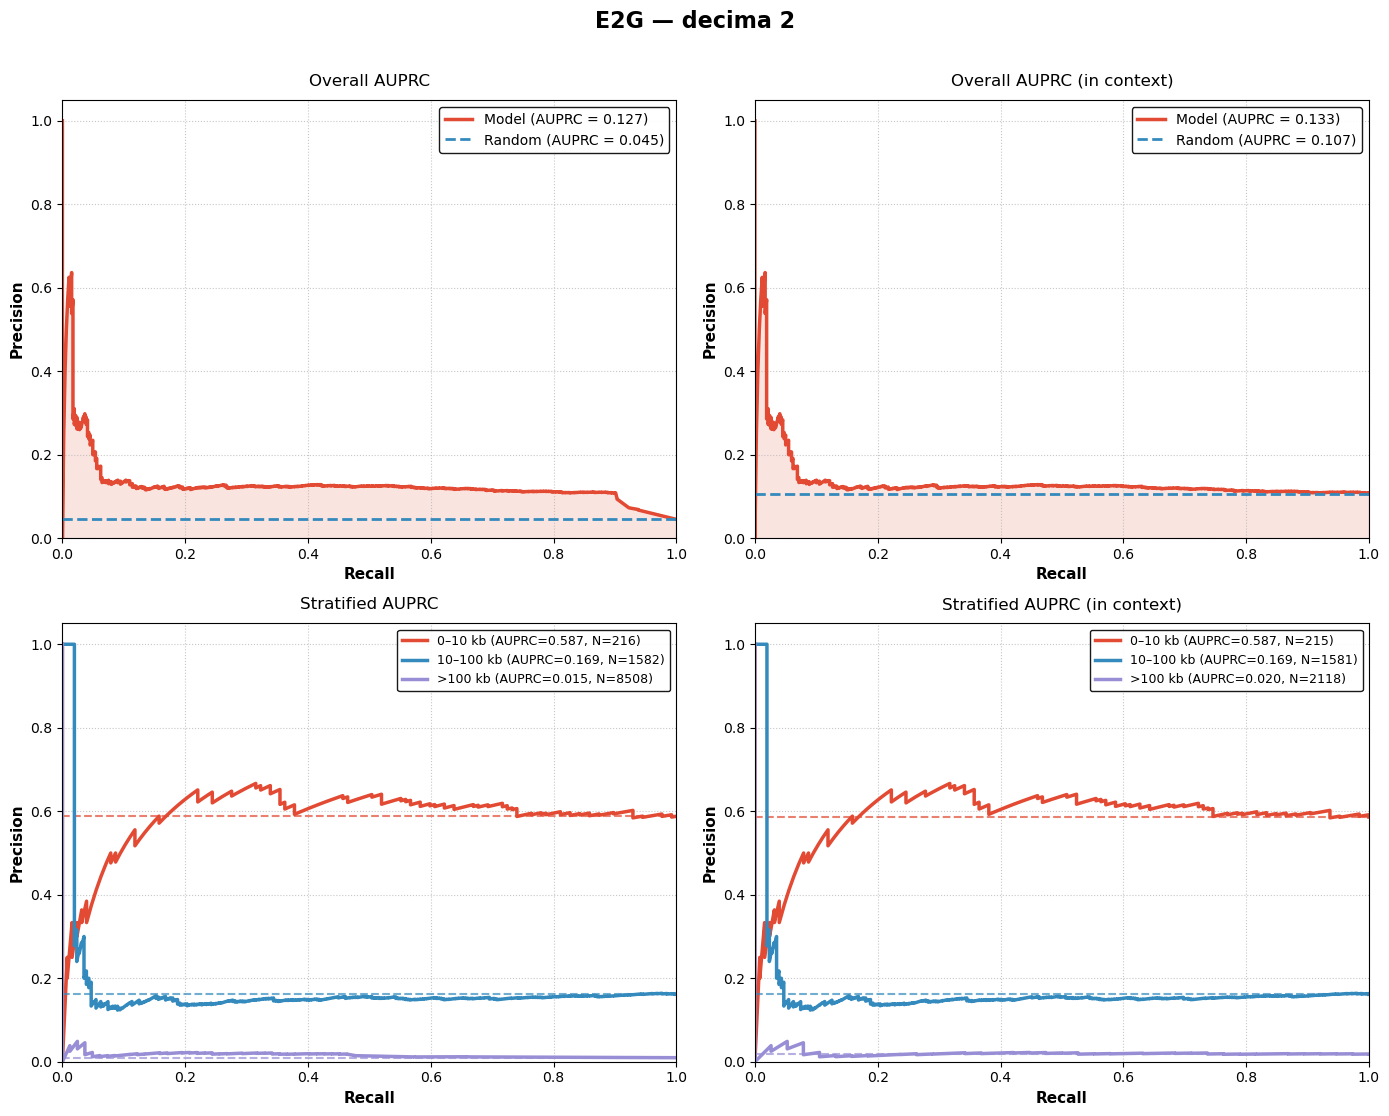

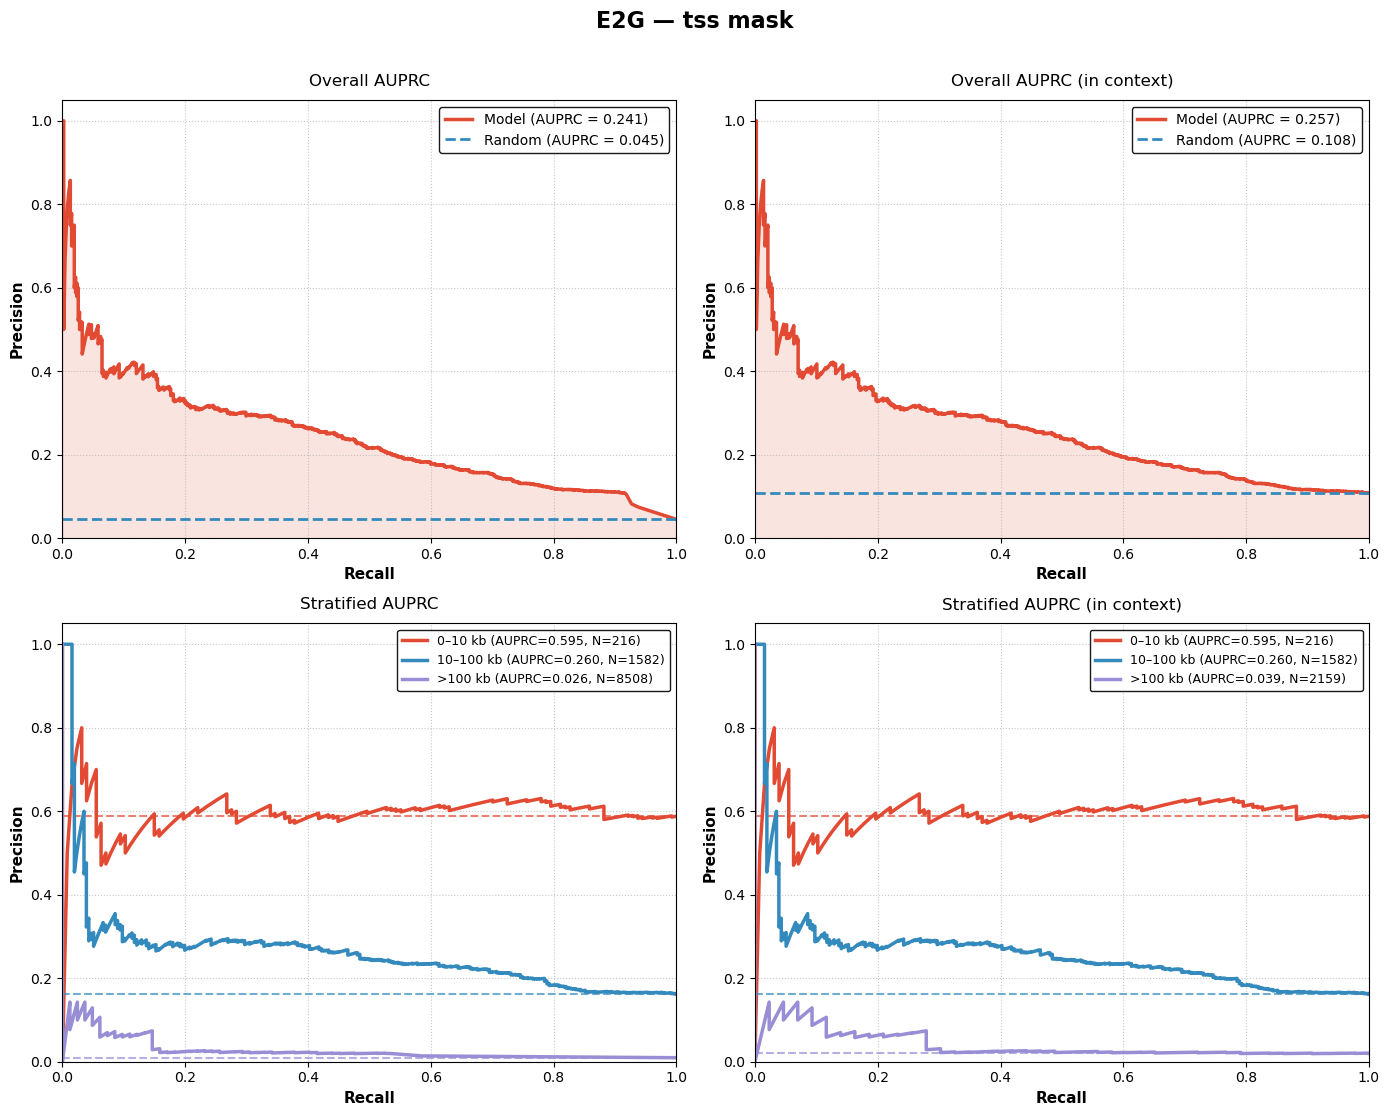

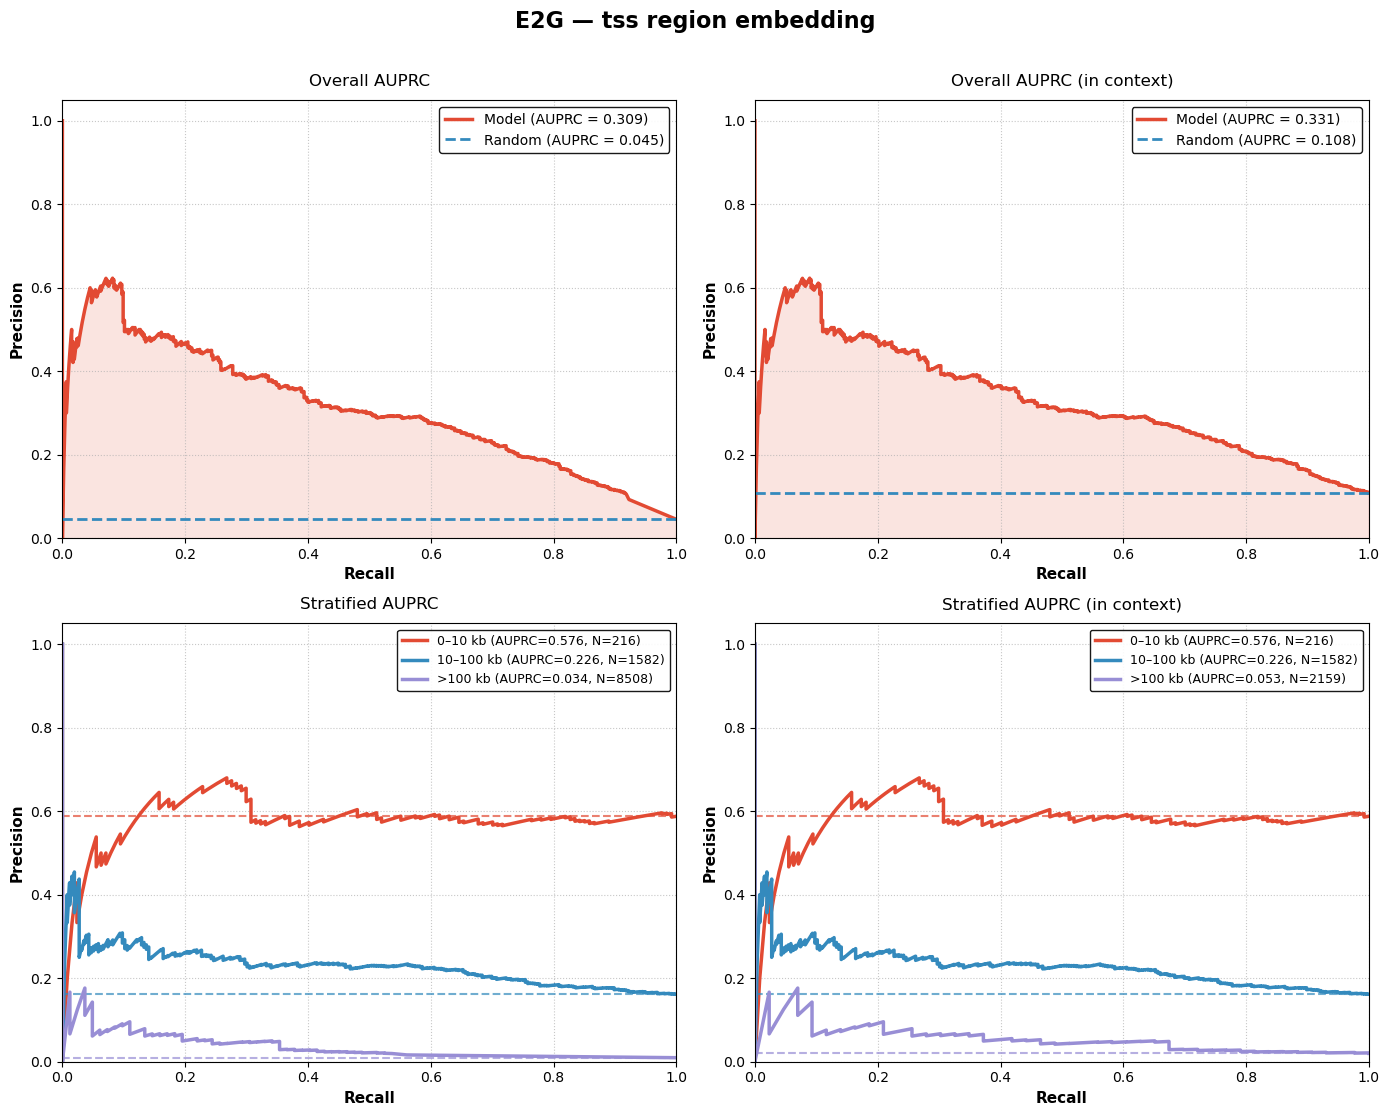

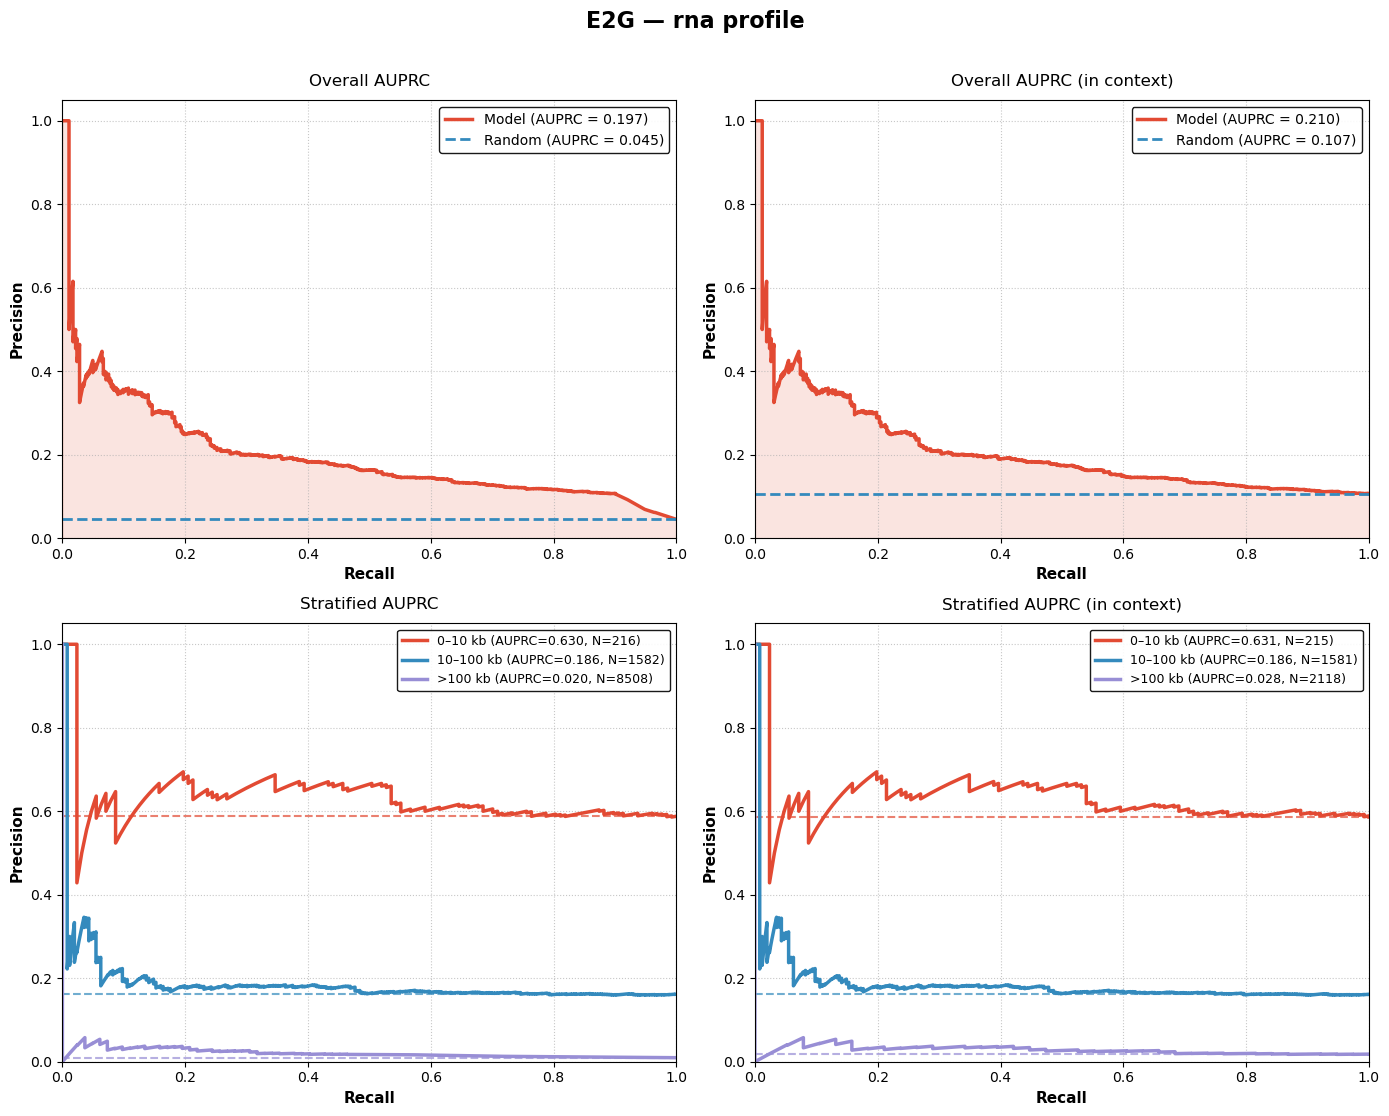

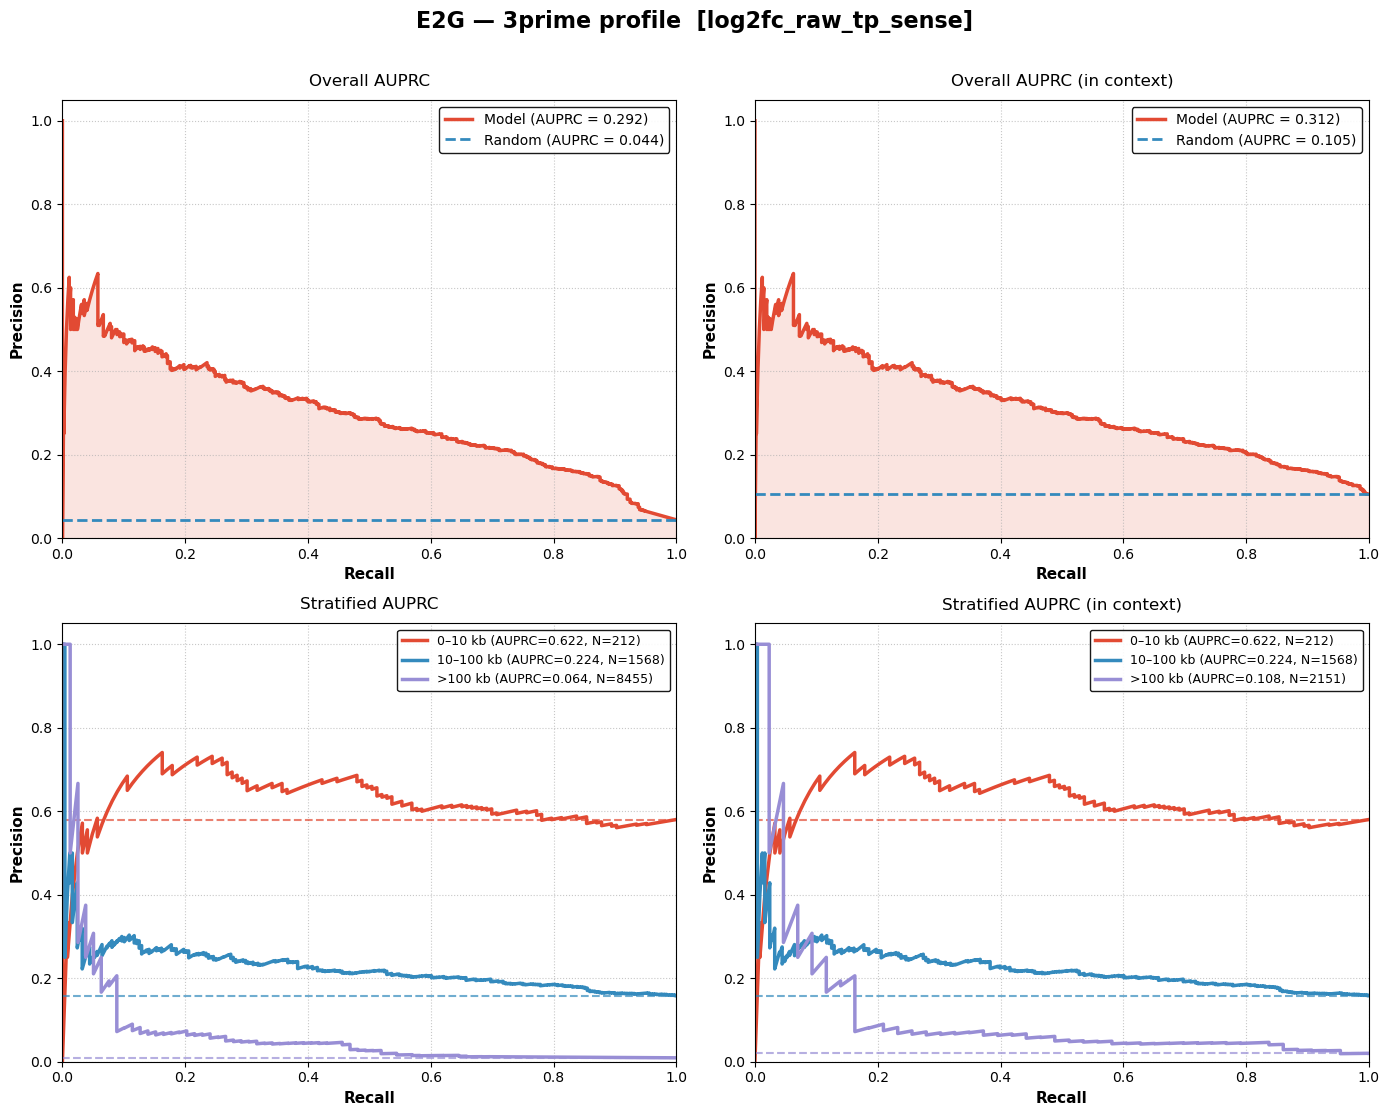

In [14]:
# Each model on its own pair set, as in R8. The first three repeat R8 exactly (same files, same
# arrays) and are included so all five are in one place.
for name in NAMES_P5:
    a = model_arrays(name)
    label = f"E2G — {name}"
    if name == "3prime profile":
        label += f"  [{THREE_PRIME_COL}]"
    plot_auprc_2x2_p(a["score"], a["in_context"], a["y_true"], a["distance"], title=label)

### P8a. Which window and which strand, for the 3′ model?

`e2g_3prime.py` saved three aggregation windows and both strands precisely so this could be checked
rather than assumed, with the antisense strand as a control that *should* be much less responsive
than the sense strand if the model has learned strand-specific 3′ transcription. The check matters:
if the antisense control is as good or better, the AUPRC is not measuring a strand-specific
expression response, whatever else it is measuring.

,window,strand,subset,N,dropped_nan,baseline,|score|,-score,+score,eff_r
0,body,sense,all,10280,0,0.0450,0.3023,0.2067,0.1334,-0.0612
1,body,sense,in context,3950,0,0.1076,0.3234,0.2437,0.1714,-0.0601
2,body,anti,all,10280,0,0.0450,0.3068,0.1829,0.1632,0.0387
3,body,anti,in context,3950,0,0.1076,0.3284,0.2194,0.2022,0.0484
4,tp,sense,all,10235,45,0.0440,0.2923,0.2016,0.1298,-0.0621
5,tp,sense,in context,3931,45,0.1053,0.3122,0.2372,0.1673,-0.0619
6,tp,anti,all,10235,45,0.0440,0.2759,0.1680,0.1465,0.0371
7,tp,anti,in context,3931,45,0.1053,0.2943,0.2034,0.1836,0.0466
8,tss,sense,all,10280,0,0.0450,0.3680,0.2240,0.1818,-0.0751
9,tss,sense,in context,3950,0,0.1076,0.3951,0.2634,0.2220,-0.0770


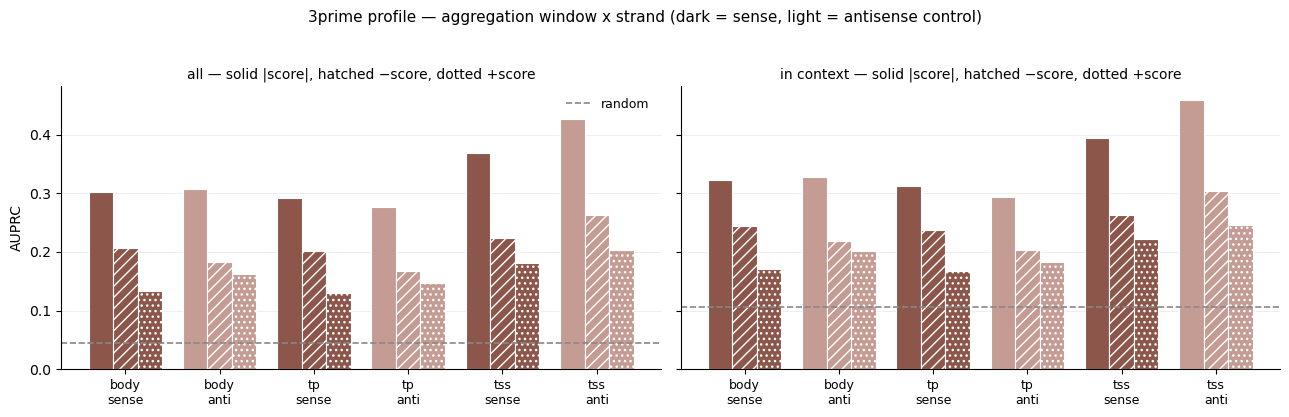

In [15]:
from scipy import stats

variants = {"|score|": np.abs, "-score": lambda s: -s, "+score": lambda s: s}
WINDOWS_3P = [(w, st) for w in ("body", "tp", "tss") for st in ("sense", "anti")]

d3 = e2g_p["3prime profile"]
rows = []
for win, st in WINDOWS_3P:
    s = tp_df[f"log2fc_raw_{win}_{st}"].values
    ok = ~np.isnan(s)
    for subset, mask in [("all", ok), ("in context", ok & d3["in_context"])]:
        yt = d3["y_true"][mask]
        entry = {"window": win, "strand": st, "subset": subset, "N": int(mask.sum()),
                 "dropped_nan": int((~ok).sum()), "baseline": yt.mean()}
        for vname, fn in variants.items():
            prec, rec, _ = precision_recall_curve(yt, fn(s[mask]))
            entry[vname] = auc(rec, prec)
        # sign convention: -log2fc is "predicted to be repressed", and every Regulated pair has a
        # negative EffectSize, so a model with the right direction gives a negative r here
        entry["eff_r"] = stats.pearsonr(-s[mask], d3["effect"][mask])[0]
        rows.append(entry)
win_df = pd.DataFrame(rows)
display(win_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0), sharey=True)
x = np.arange(len(WINDOWS_3P))
w = 0.26
strand_color = {"sense": "#8c564b", "anti": "#c49c94"}
for ax, subset in zip(axes, ["all", "in context"]):
    sub = win_df[win_df["subset"] == subset].set_index(["window", "strand"])
    for i, (vname, hatch) in enumerate(zip(variants, [None, "///", "..."])):
        ax.bar(x + (i - 1) * w, [sub.loc[k, vname] for k in WINDOWS_3P], w,
               color=[strand_color[st] for _, st in WINDOWS_3P], hatch=hatch,
               edgecolor="white", linewidth=0.8)
    ax.axhline(sub["baseline"].mean(), color="#888", linestyle="--", lw=1.2, label="random")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{w_}\n{st}" for w_, st in WINDOWS_3P], fontsize=9)
    ax.set_title(f"{subset} — solid |score|, hatched −score, dotted +score", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("3prime profile — aggregation window x strand (dark = sense, light = antisense "
             "control)", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

### P8b. Head-to-head

The four TSS models share one pair set (10306); `3prime profile` has 10280, a strict subset. The
panels below restrict to the intersection, minus the 45 rows where the 3′ window score is NaN, so
all five curves are on one identical subset. The right panel further restricts to pairs in context
for *all five* models — the only subset where every model actually saw the perturbation.

The dashed brown curve is the same 3′ model scored on its TSS window instead of its 3′ window,
carried over from P8a. It is the **highest curve in both panels** — read the legend carefully, the
top AUPRC in this figure belongs to the profile-only model's TSS window, not to any of the four
TSS models, and P8a is the reason not to take it at face value.

10235 pairs shared by all five models (10306 ∩ 10280, minus 45 NaN 3′-window rows)
in context per model: decima 2=3890, tss mask=3931, tss region embedding=3931, rna profile=3890, 3prime profile=3931
in context for all five: 3355


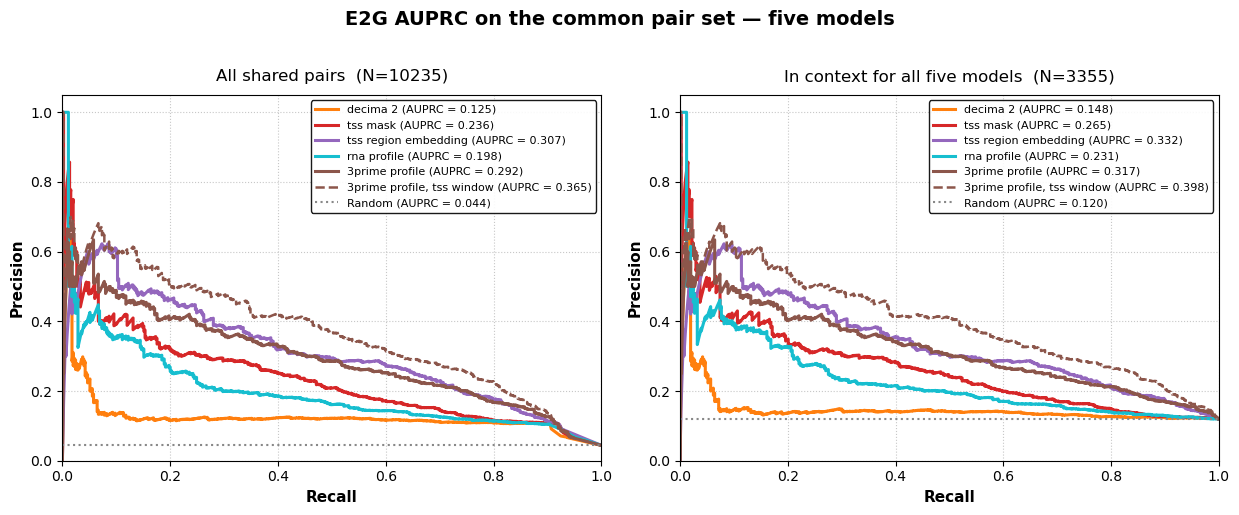

In [16]:
shared_masters = set.intersection(*[set(e2g_p[n]["master"][e2g_p[n]["valid"]]) for n in NAMES_P5])
shared_order = [m for m in e2g_p[NAMES_P[0]]["master"] if m in shared_masters]
print(f"{len(shared_order)} pairs shared by all five models "
      f"(10306 ∩ 10280, minus {int((~e2g_p['3prime profile']['valid']).sum())} NaN 3′-window rows)")

aligned_p = {}
for name in NAMES_P5:
    d = e2g_p[name]
    pos = {m: i for i, m in enumerate(d["master"])}
    idx = np.array([pos[m] for m in shared_order])
    aligned_p[name] = {k: d[k][idx] for k in
                       ("score", "in_context", "y_true", "distance", "effect")}
    if d["score2"] is not None:
        aligned_p[name]["score2"] = d["score2"][idx]

y_shared_p = aligned_p[NAMES_P5[0]]["y_true"]
for name in NAMES_P5[1:]:
    assert (aligned_p[name]["y_true"] == y_shared_p).all(), "labels must agree on shared pairs"

ctx_all_p = np.logical_and.reduce([aligned_p[n]["in_context"] for n in NAMES_P5])
print("in context per model: "
      + ", ".join(f"{n}={int(aligned_p[n]['in_context'].sum())}" for n in NAMES_P5))
print(f"in context for all five: {int(ctx_all_p.sum())}")

# the 3prime model contributes two curves, so name its window in the legend rather than letting
# two brown entries differ only by linestyle
LABEL_P5 = {n: n for n in NAMES_P5}
LABEL_P5["3prime profile"] = "3prime profile [tp window]"

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, mask, subtitle in [(axes[0], np.ones(len(y_shared_p), bool), "All shared pairs"),
                           (axes[1], ctx_all_p, "In context for all five models")]:
    yt = y_shared_p[mask]
    for name in NAMES_P5:
        prec, rec, _ = precision_recall_curve(yt, np.abs(aligned_p[name]["score"][mask]))
        ax.plot(rec, prec, color=COLORS_P[name], lw=2.2,
                label=f"{LABEL_P5[name]} (AUPRC = {auc(rec, prec):.3f})")
    # the 3prime model's other window, from P8a
    prec, rec, _ = precision_recall_curve(
        yt, np.abs(aligned_p["3prime profile"]["score2"][mask]))
    ax.plot(rec, prec, color=COLORS_P["3prime profile"], lw=1.8, linestyle="--",
            label=f"3prime profile [tss window] (AUPRC = {auc(rec, prec):.3f})")
    ax.axhline(yt.mean(), color="#888", lw=1.5, linestyle=":",
               label=f"Random (AUPRC = {yt.mean():.3f})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall", fontsize=11, fontweight="bold")
    ax.set_ylabel("Precision", fontsize=11, fontweight="bold")
    ax.set_title(f"{subtitle}  (N={int(mask.sum())})", fontsize=12, pad=10)
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9, edgecolor="black")

fig.suptitle("E2G AUPRC on the common pair set — five models", fontsize=14, fontweight="bold",
             y=1.02)
plt.tight_layout()
plt.show()

### P8c. Score direction

The R8c check, extended to five models. Lowering an enhancer's accessibility should *lower*
predicted expression, so `-score` ought to be the discriminative direction; `|score|` winning means
the model responds to the perturbation without a consistent sign.

run                       mean score  % negative       std   units  (in-context pairs)
decima 2                     +0.0184      19.3%    0.0574   natural log
tss mask                     +0.0060      30.9%    0.0321   natural log
tss region embedding         +0.0012      45.4%    0.0517   natural log
rna profile                  +0.0002      38.1%    0.0588   natural log
3prime profile               -0.0060      49.6%    0.0935   log2 FC


,model,subset,N,baseline,|score|,-score,+score
0,decima 2,all,10306,0.0451,0.1266,0.1424,0.0819
1,decima 2,in context,3914,0.1071,0.1334,0.2069,0.1050
2,tss mask,all,10306,0.0451,0.2414,0.0621,0.2128
3,tss mask,in context,3957,0.1077,0.2574,0.1051,0.2399
4,tss region embedding,all,10306,0.0451,0.3089,0.1740,0.1751
5,tss region embedding,in context,3957,0.1077,0.3306,0.2138,0.2112
6,rna profile,all,10306,0.0451,0.1968,0.1531,0.0910
7,rna profile,in context,3914,0.1071,0.2105,0.1970,0.1239
8,3prime profile,all,10235,0.0440,0.2923,0.2016,0.1298
9,3prime profile,in context,3931,0.1053,0.3122,0.2372,0.1673


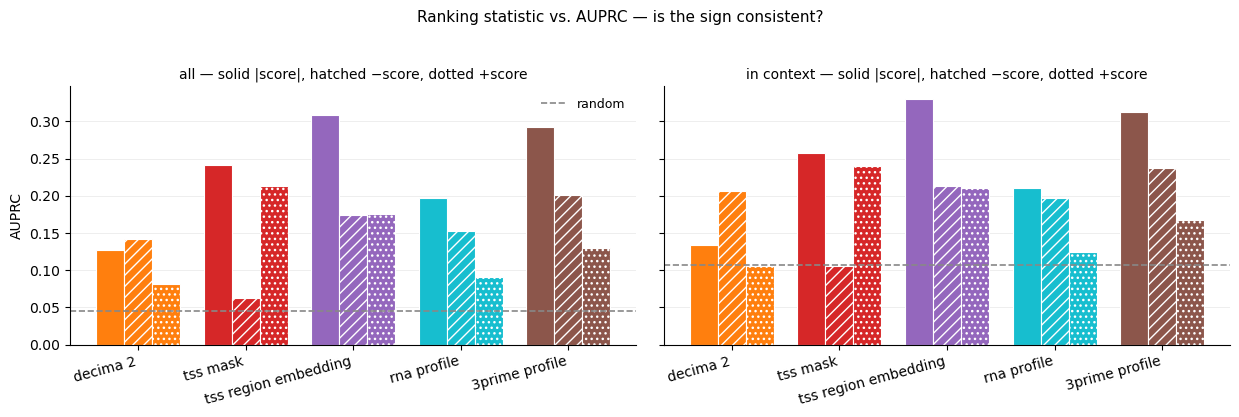

In [17]:
print(f"{'run':24s}{'mean score':>12s}{'% negative':>12s}{'std':>10s}   units  (in-context pairs)")
for name in NAMES_P5:
    d = e2g_p[name]
    s = d["score"][d["in_context"] & d["valid"]]
    print(f"{name:24s}{s.mean():+12.4f}{np.mean(s < 0):11.1%}{s.std():10.4f}   {d['units']}")

rows = []
for name in NAMES_P5:
    a = model_arrays(name)
    for subset, mask in [("all", np.ones(len(a["y_true"]), bool)), ("in context", a["in_context"])]:
        yt = a["y_true"][mask]
        entry = {"model": name, "subset": subset, "N": int(mask.sum()), "baseline": yt.mean()}
        for vname, fn in variants.items():
            prec, rec, _ = precision_recall_curve(yt, fn(a["score"][mask]))
            entry[vname] = auc(rec, prec)
        rows.append(entry)
sign_df_p = pd.DataFrame(rows)
display(sign_df_p.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), sharey=True)
x = np.arange(len(NAMES_P5))
w = 0.26
for ax, subset in zip(axes, ["all", "in context"]):
    sub = sign_df_p[sign_df_p["subset"] == subset].set_index("model")
    for i, (vname, hatch) in enumerate(zip(variants, [None, "///", "..."])):
        ax.bar(x + (i - 1) * w, [sub.loc[n, vname] for n in NAMES_P5], w,
               color=[COLORS_P[n] for n in NAMES_P5], hatch=hatch, edgecolor="white",
               linewidth=0.8)
    ax.axhline(sub["baseline"].mean(), color="#888", linestyle="--", lw=1.2, label="random")
    ax.set_xticks(x)
    ax.set_xticklabels(NAMES_P5, rotation=15, ha="right")
    ax.set_title(f"{subset} — solid |score|, hatched −score, dotted +score", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Ranking statistic vs. AUPRC — is the sign consistent?", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

### P8d. Model score vs. CRISPRi effect size

The plotted score is `-score`, so positive means "predicted to be repressed by the knockdown".
Every `Regulated` pair in the benchmark has a *negative* `EffectSize`, so a model that gets the
direction right produces a **negative** `r` here; a positive `r` means it moves the wrong way.

x-axis units differ for the 3′ model (log2 fold-change of summed profile counts, not a log-expression
difference), so the panels are not overlayable — but `r` is scale-free and comparable.

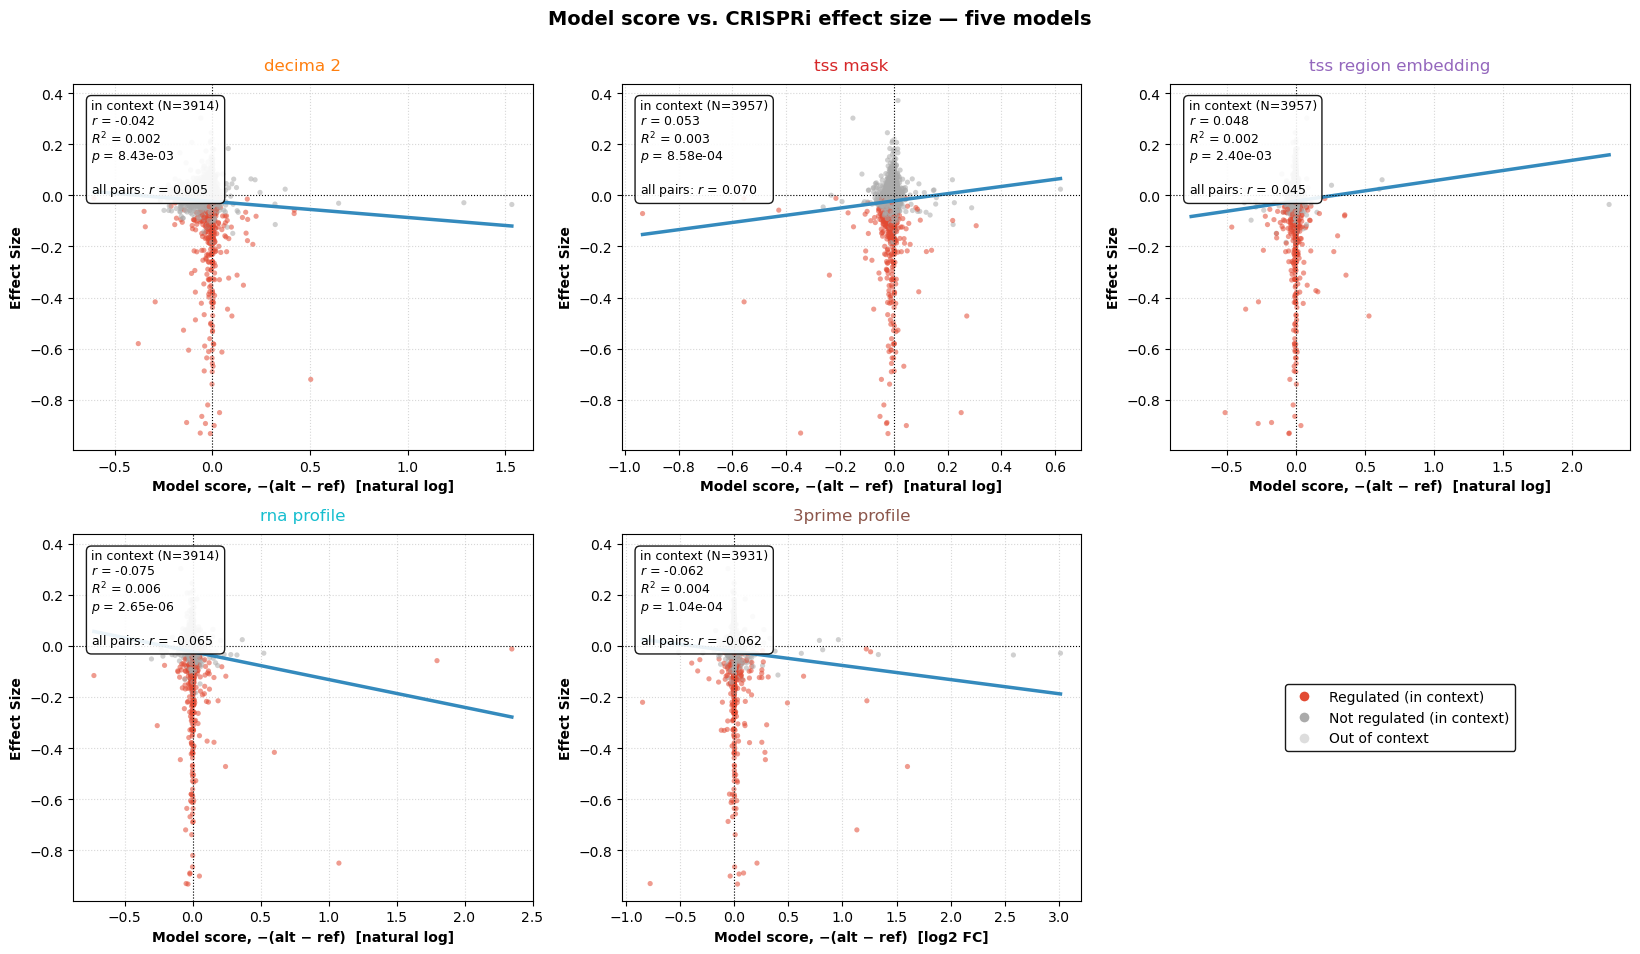

In [18]:
from scipy import stats
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.5))
flat = axes.ravel()

for ax, name in zip(flat, NAMES_P5):
    a = model_arrays(name)
    model_score = -a["score"]      # no rescaling: the TSS models are all in natural log
    effect = a["effect"]
    ctx = a["in_context"]

    ax.scatter(model_score[~ctx], effect[~ctx], c="#dddddd", alpha=0.4, s=10,
               linewidths=0, rasterized=True)
    colors = np.where(a["y_true"].astype(bool), "#E24A33", "#aaaaaa")
    ax.scatter(model_score[ctx], effect[ctx], c=colors[ctx], alpha=0.55, s=14,
               linewidths=0, rasterized=True)

    # fit on in-context pairs only; out-of-context scores are structurally ~0
    slope, intercept, r_ctx, p_ctx, _ = stats.linregress(model_score[ctx], effect[ctx])
    xs = np.linspace(model_score[ctx].min(), model_score[ctx].max(), 200)
    ax.plot(xs, intercept + slope * xs, color="#348ABD", lw=2.5)

    r_all = stats.pearsonr(model_score, effect)[0]
    p_str = f"{p_ctx:.2e}" if p_ctx > 1e-300 else "< 1e-300"
    textstr = (f"in context (N={int(ctx.sum())})\n$r$ = {r_ctx:.3f}\n$R^2$ = {r_ctx**2:.3f}\n"
               f"$p$ = {p_str}\n\nall pairs: $r$ = {r_all:.3f}")
    ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.9))

    ax.axhline(0, color="black", lw=0.8, linestyle=":")
    ax.axvline(0, color="black", lw=0.8, linestyle=":")
    ax.set_xlabel(f"Model score, −(alt − ref)  [{e2g_p[name]['units']}]", fontsize=10,
                  fontweight="bold")
    ax.set_ylabel("Effect Size", fontsize=10, fontweight="bold")
    ax.set_title(name, fontsize=12, pad=10, color=COLORS_P[name])
    ax.grid(True, linestyle=":", alpha=0.5)

flat[-1].axis("off")
flat[-1].legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E24A33", markersize=8,
           label="Regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#aaaaaa", markersize=8,
           label="Not regulated (in context)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#dddddd", markersize=8,
           label="Out of context"),
], loc="center", fontsize=10, framealpha=0.9, edgecolor="black")

fig.suptitle("Model score vs. CRISPRi effect size — five models", fontsize=14,
             fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

### Takeaways — E2G (P8)

Baseline AUPRC is 0.045 over all pairs and ~0.108 over in-context pairs. Numbers below are each
model on its own pair set (10306 for the TSS models, 10280 for the 3′ model), matching how R8
reported them; P8b is the strictly comparable version.

| model | AUPRC \|score\|, all | AUPRC \|score\|, in ctx | best variant, in ctx | effect-size r, in ctx | in-ctx pairs |
|---|---|---|---|---|---|
| `3prime profile` (tss win, antisense) | 0.427 | **0.459** | \|score\|, 0.459 | −0.001 (none) | 3950 |
| `3prime profile` (tss win, sense) | 0.368 | 0.395 | \|score\|, 0.395 | **−0.077** (right sign) | 3950 |
| `tss region embedding` | 0.309 | 0.331 | \|score\|, 0.331 | +0.048 (wrong sign) | 3957 |
| `3prime profile` (**tp win, sense** = headline) | 0.292 | 0.312 | \|score\|, 0.312 | −0.062 (right sign) | 3931 |
| `tss mask` | 0.241 | 0.257 | \|score\|, 0.257 | +0.053 (wrong sign) | 3957 |
| `rna profile` | 0.197 | 0.210 | \|score\|, 0.210 | −0.075 (right sign) | 3914 |
| `decima 2` | 0.127 | 0.133 | −score, 0.207 | −0.042 (right sign) | 3914 |

- **`rna profile` is the clean ablation, and the profile head helps E2G as much as it hurt
  expression.** Against `decima 2` — identical inputs, window and pooling, differing only in the
  decoder and loss — in-context `|score|` AUPRC goes 0.133 → 0.210 and effect-size `r` goes
  −0.042 → −0.075, the strongest (and correctly signed) effect-size correlation of any model here.
  It pays for that with the worse expression metrics in P1. The P1/P8 trade-off that R8 noted
  across *different* architectures now shows up inside a single controlled pair.
- `rna profile` also has the healthiest sign behaviour of the five: mean in-context score
  +0.0002 (versus +0.018 for `decima 2`), 38% of scores negative, and `-score` (0.197) nearly
  matching `|score|` (0.210) rather than being beaten by `+score`. It is the only model that is both
  directionally correct *and* not badly offset.
- **The 3′ model's antisense control fails, and that is the most important line in this section.**
  On the TSS window the *antisense* strand scores 0.459 against the sense strand's 0.395 — the
  control that should have been much less responsive is the best number in the whole table. Its
  effect-size `r` is −0.001, i.e. no relationship to effect magnitude at all. So the 3′ model's
  large AUPRC is substantially a non-strand-specific response to the accessibility knockdown, not a
  measurement of strand-specific 3′ transcription. Treat 0.4+ as an upper bound contaminated by
  whatever generic signal the antisense track shares, not as an E2G result.
- The window ordering is also backwards for a 3′ model: `tss` (0.395 sense) > `body` (0.323) >
  `tp` (0.312), when `tp` is where 3′ RNA-seq reads actually pile up. The perturbation response is
  strongest right where the accessibility was edited, which is the signature of a local smear rather
  than of a transcript-level readout. The sense-strand windows do keep the right effect-size sign
  (−0.060 to −0.077) while the antisense ones do not, so there is *some* sense-specific magnitude
  signal underneath — it is just not what the AUPRC is ranking on.
- Directionality is still the open problem overall: `tss mask` remains inverted (`+score` 0.240 vs.
  `-score` 0.105) and `tss region embedding` still has no usable sign. Mean in-context score is
  positive for all four TSS models, so knocking accessibility down still raises the prediction more
  often than it lowers it.
- Effect-size correlations remain negligible in absolute terms for everything here (best |r| =
  0.077, R² = 0.006). None of these models tracks CRISPRi effect *magnitude*; the p-values only look
  impressive because N ≈ 3900.